# 09 - Pot linearization

The position sensor in a hobby servo is a potentiometer on the output shaft. The
firmware reads it as a number from 0 to 4095 and treats that number as if it moved
in step with the shaft. On the MG90 on my bench it does not, quite. Some stretches
of the resistive track read fast and some read slow, so one count means a slightly
different angle depending on where the shaft is sitting.

The plan is simple to say. `osc` measures that once from capture data, writes a small
correction table into the servo's control table, and the firmware applies it to every
pot sample, so position and speed come out linear in the true shaft angle. Before
anybody touches firmware, this notebook builds the table from telemetry I already
have and tries to prove it with the two rules the series runs on (two independent
routes that agree, and repeats that agree). It also answers a question for notebook
08. Once the pot is linearized, is its speed good enough to fuse with the back-EMF
speed in the velocity observer?

Here is the short version, with the numbers from the cells below:

- **The error is real and sizeable.** Against the true angle the raw pot is off by
  106 counts peak to peak over the covered travel. Its local sensitivity runs from
  0.53 to 1.53 times nominal in 25-count windows and 0.71 to 1.35 in 67-count windows,
  the width of one table interval. A speed read off the raw pot is wrong by that much,
  and so is the position loop's gain.
- **Two routes agree over all the travel the shaft crosses at speed.** Counting
  commutation ripple and integrating back-EMF give the same shape to within 1.4 counts
  (0.47 rms) over the middle of travel. The session could not check the ends, because
  only rungs still spinning up cross them and back-EMF reads high during spin-up. A
  second capture made for the ends crosses them at steady speed. The upper end then
  agrees like the middle (0.47 rms, 1.5 at most). The lower end agrees only once
  back-EMF uses the winding resistance its own load swings call for, about 7.7 ohm at
  15 to 20% duty instead of the pinned 4.89 (0.65 rms and 1.9 at most, against 6.5 at
  the pinned value). About 200 counts next to each guard are still only crossed while
  spinning up, and there the table rests on the ripple alone.
- **Backlash is about 1.5 ripple cycles, about 6 counts**, the same in all four
  datasets. Forward and reverse shapes are not only offset, they differ by a
  position-locked bump of up to 11 counts near raw 2500 that both routes see.
- **It repeats inside one recording, less so across a day.** Capture to capture the
  shape moves 0.8 counts (sd, mean over travel). But the ends capture, recorded a few
  hours after the session, differs from it by 3.5 counts rms and 14 at worst, in the
  same pattern the USB session recorded in between shows. It looks like the servo
  changed over the day. The slip check passes on every one of several hundred runs.
- **The 55-knot table**, built from the session and the ends capture together, takes
  the held-out position error from 16.5 to 4.7 counts rms. It removes much less of the
  speed error, 24% to 19% at 4 ms, because a lot of the texture is narrower than one
  knot interval. A 217-knot table would get 12.7%.
- **The firmware's table sits on a fixed 16-count grid**, 257 knots over the whole ADC range,
  integer interpolation with one multiply and no divide. Anchored on the stretch at least 20 rungs
  cross, 542 to 3520, it is the 217-knot table of the sweep in a fixed layout: held-out position
  error 2.9 counts rms, the dense curve's own, and speed error 12.6% at 4 ms and 3.6% at 20 ms.
- **Fusion.** Where back-EMF exists the pot should stay position only (weight about
  0.01 at 4 ms). The pot is the only speed below 14% duty and at rest, and above 50%
  duty the back-EMF model as fitted here reads 5 to 28% fast, so there a 20 ms pot
  derivative wins.
- **Degrees, from the counted teeth.** The train is 308.05:1. Linearized, the pot reads 19.76
  counts per degree everywhere in the covered band. Raw, it runs from 13.7 to 26.5 locally and
  averages 19.17 over mid travel. Stop to stop is 184.2 degrees, bracket 178.7 to 189.2, and the whole
  bracket comes from the two ends no rung crosses. Per output degree the MG90 makes about 1.34 to 1.36
  times the SG90's back-EMF, which is the gears (1.312) times two motors within a few percent.
- **Downstream constants move a few percent.** $K_e$ in counts drops 3.9%, the viscous
  terms 3 to 7%, the speed-per-duty slope rises 6.7%. The soft limits sit in the
  uncorrected insets and do not move at all.

## Picking a rig

The cell below selects the primary dataset and prints what that means in hardware
terms. `mg90-a__2s` is the 2S merged session, five captures, each holding every
free-shaft procedure within a few minutes of each other on one battery. Everything
quoted as a number in this notebook comes from it. The USB datasets and the older
classic set appear only as checks, because the USB rail droops with load (notebook 00
and the supply policy of the series).

The table rails come from the session's own `envelope.toml`, which the capture tool
read off the servo. The physical stops at 209 and 3849 are the table's `raw_min` and
`raw_max`, the soft limits sit inside them and the seek guards inside those.

One constant is an input rather than an output here, the winding resistance $R$.
A free-shaft ladder cannot separate $R$ from $K_e$ because current and speed rise
together, so I pin it from the onset regression in the bringup repo and show what its
bracket does to every result that uses it.

In [1]:
import tomllib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import poslut, ripple, session

# 2S is the primary dataset. The USB rail droops with load, so USB numbers are a
# direction check only and never land in a constant (supply policy).
ds = oscnb.use("mg90-a__2s")
board, servo = oscnb.current().board, oscnb.current().servo

# The session's own envelope, written by the capture pilot from the servo's
# control table: physical stops, soft limits and seek guards, all in raw counts.
env = tomllib.loads((ds.path / "envelope.toml").read_text())
RAW_MIN, RAW_MAX = env["limits"]["phys"]   # the LUT's rails: the hand stops
SOFT = tuple(env["limits"]["soft"])          # soft limits the firmware clamps goals to
GUARD = tuple(env["limits"]["guard"])        # seek guards, the ends of every rung

FS = board.tick_hz                           # telemetry samples per second
DT = 1.0 / FS                                # seconds per sample
Q15 = 32767                                  # duty full scale on the wire
R_OHM = servo.measured["r_winding_measured"].value   # winding resistance, pinned (section 3)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.DataFrame([
    ("LUT rails (physical stops)", f"{RAW_MIN} .. {RAW_MAX}", "raw counts", "envelope.toml limits.phys"),
    ("soft limits", f"{SOFT[0]} .. {SOFT[1]}", "raw counts", "envelope.toml limits.soft"),
    ("seek guards", f"{GUARD[0]} .. {GUARD[1]}", "raw counts", "envelope.toml limits.guard"),
    ("knot spacing", f"{(RAW_MAX - RAW_MIN) / (poslut.N_POINTS - 1):.2f}", "raw counts", "55 knots over the rails"),
    ("winding resistance R", f"{R_OHM:g}", "ohm", servo.measured["r_winding_measured"].source),
], columns=["quantity", "value", "unit", "source"]).set_index("quantity")

dataset  mg90-a__2s
supply   2s
rig      Vorpal MG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
ends,5,1,sweep
session,5,2,"fast, slow"



derived constants (what the hardware is)


value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   3.0606
                 terminal difference                                mV per count            2.4658
                 terminal bias VB                                   mV                    627.9352
                                                                    counts                779.4008
                 driven-low terminal reads                          counts                524.7451
                 motor current                                      mA per count            0.8952
                                                                    counts per A         1117.0909
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      15.0000
                 rail tap ratio                                                             2.5000
                 sample rate                                        samples per ms         20.0000
                 current settled from (UNVERIFIED)                  % duty                 13.3333
                 voltage settled from (UNVERIFIED)                  % duty                 13.3333
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800


measured values (what someone found when they looked)


value                  unit  \
where quantity                                                 
board vb_bias               781.000000                counts   
      rail_droop_usb         -3.500000   % over 20-100% duty   
      opa_noise_floor         2.200000            counts RMS   
      esd_clamp_skew          1.800000                V bemf   
      vdd                     3.280000                     V   
      terminal_chain          0.000000              % vs DMM   
      current_chain_scale     1.200000  % high vs grid route   
      crest_floor            15.000000          % duty on 2S   
servo gear_ratio            308.053333                    :1   
      ripple_order            6.000000         per motor rev   
      r_winding               4.890000                   Ohm   
      ke_ripple               1.295000      mV per ripple Hz   
      pot_scale              19.760000            counts/deg   
      travel                184.220000                   deg   
      low_stop_after_stall  232.000000                counts   
      backlash                1.480000         ripple cycles   

                                       bracket  \
where quantity                                   
board vb_bias                       [775, 783]   
      rail_droop_usb                  [-4, -3]   
      opa_noise_floor                 [2, 2.4]   
      esd_clamp_skew                [1.7, 1.9]   
      vdd                         [3.27, 3.29]   
      terminal_chain               [-0.7, 0.7]   
      current_chain_scale          [-1.5, 3.9]   
      crest_floor                     [15, 17]   
servo gear_ratio            [308.053, 308.053]   
      ripple_order                      [6, 6]   
      r_winding                   [4.49, 4.98]   
      ke_ripple                 [1.284, 1.306]   
      pot_scale                  [19.7, 19.85]   
      travel                  [178.67, 189.18]   
      low_stop_after_stall          [232, 236]   
      backlash                     [1.25, 1.5]   

                                                                       source  \
where quantity                                                                  
board vb_bias                         Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                          2S vs USB grid, 5 captures each   
      opa_noise_floor                                 bringup isns-diff run29   
      esd_clamp_skew                               bringup isns-diff findings   
      vdd                            nb00 sec 10.1, DMM at the 3V3 test point   
      terminal_chain                         nb00 sec 10.2, 4x4 grid at 1.7 A   
      current_chain_scale                           nb00 sec 10.3, 2S DC laps   
      crest_floor            nb00 sec 10.5-10.6, static-load ladders + bursts   
servo gear_ratio                              mechanical/mg90/measurements.py   
      ripple_order                             teardown, 3-slot brushed motor   
      r_winding             bringup captures/mg90/plant.py, onset regressi...   
      ke_ripple             nb09 sec 3, settled windows of the 15-50% grid...   
      pot_scale             nb09 sec 10, ripple cycles stitched over the c...   
      travel                nb09 sec 10, phys stop to phys stop 209..3849:...   
      low_stop_after_stall  hand stop, firm push, 2026-09-28, after the st...   
      backlash              nb09 sec 4, reversal blocks, commutation steps...   

                                                                       caveat  
where quantity                                                                 
board vb_bias               nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb        USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor       arm-B external network at G15; the internal PG...  
      esd_clamp_skew        above this the A-side ESD clamp skews the divi...  
      vdd                   vdd_mv stays

,value,unit,source
quantity,,,
LUT rails (physical stops),209 .. 3849,raw counts,envelope.toml limits.phys
soft limits,432 .. 3626,raw counts,envelope.toml limits.soft
seek guards,532 .. 3526,raw counts,envelope.toml limits.guard
knot spacing,67.41,raw counts,55 knots over the rails
winding resistance R,4.89,ohm,"bringup captures/mg90/plant.py, onset regressi..."


## The data, and the tracker

Every capture holds a duty grid, 5 to 100% in 5% steps, forward then reverse. Each
**rung** is one constant-duty burst that starts at a seek guard and runs about 2600
counts toward the other end. Those rungs are the main diet of this notebook. Section 3
adds a second 2S experiment, `ends`, recorded later to test the two ends of travel.

The motor-side angle comes from the **commutation ripple**. Each time a brush crosses
a gap in the commutator the winding current steps, six times per motor revolution on
this 3-slot motor, and the 20 kHz current stream shows that as a clean spectral line.
Counting its cycles gives the motor angle in ripple cycles, with no pot involved at
all. The tracker is `oscnb.ripple.motor_angle` from notebook 06. I work in ripple
cycles and pot counts until section 10, where the counted gear ratio turns them into
degrees. The ratio comes from counting teeth. Deriving it from ripple against pot would
fold the very pot error this notebook measures into it.

The tracker seeds its search from the pot speed times a **coupling prior** (cycles per
count), within plus or minus 30%. That is a place where the pot's own error could bite,
so the first cell measures the prior from settled 20 to 40% rungs and the next one
checks how far the seed actually landed from the line the tracker followed.

In [2]:
# The other datasets, each read under the board its own recordings name.
ds_usb = oscnb.datasets.load("mg90-a__usb")                   # session, USB, same firmware as the 2S session
ds_usb_old = oscnb.datasets.load("mg90-a__dev-v006-D__usb")   # the first session set, USB, a day earlier
ds_classic = oscnb.datasets.load("mg90-a__dev-v006-D__2s")    # classic experiments, 2S, a day earlier

def complete(d):
    # A session capture counts only when both recordings landed. The USB set was
    # still recording when this notebook ran, so its last capture can be partial.
    return [c for c in d.captures("session")
            if {r.name for r in d.recordings("session", c)} >= {"slow", "fast"}]

def frames(d, view):
    # (capture, frame, meta) for every usable capture. A view that is one of the
    # dataset's own experiments (the classic layout, and the 2S `ends` capture) is read
    # as it is. Anything else is sliced out of the merged session.
    if view in d.experiments:
        for c in d.captures(view):
            recs = d.recordings(view, c)
            if len(recs) == 1:                 # skips an empty capture folder
                yield c, recs[0].frame(), recs[0].meta
    else:
        for c in complete(d):
            df, meta = session.read(d, c, view)
            yield c, df, meta

pd.DataFrame([
    {"dataset": d.key, "supply": d.supply, "board": d.board.key,
     "grid captures": len(list(complete(d))) if "session" in d.experiments else len(d.captures("grid")),
     "ends captures": len(d.captures("ends")) if "ends" in d.experiments else 0}
    for d in (ds, ds_usb, ds_usb_old, ds_classic)
]).set_index("dataset")

,supply,board,grid captures,ends captures
dataset,,,,
mg90-a__2s,2s,dev-v006-D,5,5
mg90-a__usb,usb,dev-v006-D,5,0
mg90-a__dev-v006-D__usb,usb,dev-v006-D,5,0
mg90-a__dev-v006-D__2s,2s,dev-v006-D,10,0


In [3]:
# A first coupling estimate, only to seed the tracker off the sub-line family.
# Settled window of the 20 to 40% grid rungs: line frequency over pot speed.
rows = []
for cap, df, meta in frames(ds, "grid"):
    bias = df[df.seg == 0].current_raw.mean()           # the amplifier offset of this recording
    for seg, g in df[df.seg > 0].groupby("seg"):
        duty = g.cmd_duty_q15.iloc[0] * 100 / Q15
        if not 20 <= abs(duty) <= 40:
            continue
        st = ripple.settled(g)                           # last 60% of the rung
        f, X = ripple.line_spectrum(st.current_raw.to_numpy() - bias, FS)
        fr, _ = ripple.settled_line(f, X)                # the line, promoted off a sub-line if needed
        v = abs(ripple.pot_speed(st, FS, 1.0))           # pot counts per second, least squares
        rows.append({"cap": cap, "duty": round(duty), "f_line_Hz": fr, "pot_cps": v, "cyc_per_count": fr / v})
prior = pd.DataFrame(rows)
C_PRIOR = prior["cyc_per_count"].median()                # ripple cycles per raw pot count
print(f"coupling prior {C_PRIOR:.4f} cycles per count, spread over {len(prior)} rungs "
      f"{prior.cyc_per_count.min():.4f} .. {prior.cyc_per_count.max():.4f}")

coupling prior 0.2709 cycles per count, spread over 40 rungs 0.2649 .. 0.2753


In [4]:
MIN_ACCEPT = 0.90     # a rung counts only if the tracker holds the line over 90% of it
CPC_TOL = 0.03        # and its whole-rung coupling sits within 3% of its set's median

def track(d, view, label):
    # Every drive rung of a view through the ripple tracker. Returns one dict per
    # rung carrying the arrays later sections need, with the motor angle in ripple
    # cycles, unsigned and rising, at every sample.
    out = []
    for cap, df, meta in frames(d, view):
        bias = df[df.seg == 0].current_raw.mean()
        df = df.assign(bias=bias)                                     # motor_angle reads it per rung
        for seg, g in df[df.seg > 0].groupby("seg"):
            duty = g.cmd_duty_q15.iloc[0] * 100 / Q15
            if abs(duty) < 12 or g.cmd_duty_q15.nunique() > 1:      # below the tracker floor, or a chained flip
                continue
            r = {"set": label, "cap": cap, "seg": int(seg), "duty": int(round(duty)), "n": len(g),
                 "pos": g.pos.to_numpy(), "cur": g.current_raw.to_numpy() - bias,
                 "va": g.vmotor_a.to_numpy(), "vb": g.vmotor_b.to_numpy(),
                 "dq": g.duty_q15.to_numpy(), "valid": g.window_valid.to_numpy()}
            cyc, n0, ridge = ripple.motor_angle(g, C_PRIOR, FS, 1.0)
            if cyc is None:
                r.update(ok=False, accept=0.0)
                out.append(r)
                continue
            st = ripple.settled(g)
            v = abs(ripple.pot_speed(st, FS, 1.0))
            p = r["pos"]
            r.update(cyc=cyc, n0=n0, accept=(len(g) - n0) / len(g),
                     cpc=(cyc[-1] - cyc[n0]) / abs(p[-1] - p[n0]) if p[-1] != p[n0] else np.nan,
                     # where the seed band was centred against where the ridge actually ended
                     seed_ratio=ridge["f"].iloc[-1] / (C_PRIOR * v),
                     lo=int(p[n0:].min()), hi=int(p[n0:].max()))
            out.append(r)
    # acceptance: enough of the rung tracked, and a coupling that is not a family member
    tracked = [r for r in out if "cyc" in r]
    med = np.median([r["cpc"] for r in tracked if 15 <= abs(r["duty"]) <= 50])
    for r in out:
        r["ok"] = "cyc" in r and r["accept"] >= MIN_ACCEPT and abs(r["cpc"] / med - 1) < CPC_TOL
    return out

rungs = {
    "2S session": track(ds, "grid", "2S session"),
    "USB session": track(ds_usb, "grid", "USB session"),
    "USB session, first set": track(ds_usb_old, "grid", "USB session, first set"),
    "2S classic grid": track(ds_classic, "grid", "2S classic grid"),
    "2S classic steady steps": track(ds_classic, "ripple", "2S classic steady steps"),
    "2S ends": track(ds, "ends", "2S ends"),                    # section 3, the end-of-travel capture
}

def summary(rs):
    t = pd.DataFrame([{k: r.get(k) for k in ("set", "cap", "duty", "ok", "accept", "cpc", "seed_ratio")} for r in rs])
    t["band"] = pd.cut(t.duty.abs(), [0, 14, 50, 100], labels=["12-14%", "15-50%", "55-100%"])
    t["dir"] = np.where(t.duty > 0, "fwd", "rev")
    return t

tab = pd.concat([summary(rs) for rs in rungs.values()])
tab.groupby(["set", "band", "dir"], observed=True).agg(
    rungs=("ok", "size"), accepted=("ok", "sum"),
    tracked_fraction=("accept", "mean"),
    cycles_per_count=("cpc", "median"),
    seed_ratio_min=("seed_ratio", "min"), seed_ratio_max=("seed_ratio", "max")).round(4)

rungs  accepted  tracked_fraction  cycles_per_count  seed_ratio_min  seed_ratio_max
set                     band    dir                                                                                     
2S classic grid         15-50%  fwd     80        80            0.9707            0.2649          0.9905          1.0050
                                rev     80        80            0.9737            0.2629          0.9974          1.0190
                        55-100% fwd    100        11            0.5773            0.2688          0.8360          1.0499
                                rev    100        98            0.9395            0.2630          0.9934          1.0383
2S classic steady steps 15-50%  fwd     10        10            0.9688            0.2663          1.0223          1.0346
                                rev     10        10            0.9674            0.2565          0.9924          1.0081
                        55-100% fwd      5         0            0.3287            0.2631          0.8671          1.0321
                                rev      5         4            0.9111            0.2573          0.9919          0.9994
2S ends                 15-50%  fwd     10        10            0.9848            0.2615          0.9264          1.0215
                                rev     10        10            0.9847            0.2631          0.8936          1.0323
2S session              15-50%  fwd     40        40            0.9742            0.2614          0.9645          1.0004
                                rev     40        39            0.9688            0.2629          0.9737          1.0293
                        55-100% fwd     50        10            0.7903            0.2681          0.8233          1.0199
                                rev     50        45            0.9339            0.2645          1.0046          1.0524
USB session             15-50%  fwd     40        35            0.9382            0.2635          0.8707          1.0557
                                rev     40        35            0.8858            0.2635          0.9010          1.1425
                        55-100% fwd     50        39            0.8262            0.2629          0.9770          1.0070
                                rev     50        47            0.9558            0.2644          0.9951          1.0300
USB session, first set  15-50%  fwd     40        35            0.9293            0.2651          0.8615          1.0745
                                rev     40        35            0.8595            0.2638          0.8787          1.1547
                        55-100% fwd     50        37            0.8681            0.2660          0.8365          1.0139
                                rev     50        49            0.9599            0.2645          0.9996          1.0161

A rung is accepted when the tracker holds the line over at least 90% of it and the
rung's whole coupling sits within 3% of its set's median, which rejects a lock on a
member of the sub-line family (those sit at 1/2, 1/3 or 5/6 of the line).

What the table says. From 15 to 50% duty every set tracks essentially every rung in
both directions, with a coupling of 0.261 to 0.265 cycles per count. Above 50% the
forward rungs mostly fail. The line family overtakes the line there (notebook 06 saw
the same at 60%), so the tracker often holds only the last part of the rung. Reverse
rungs survive to 100%. The 20 rungs of the ends capture (section 3) all pass. So the core population for the table is **15 to 50%, both
directions**, and the high-duty reverse rungs appear only as a duty cross-check.

In [5]:
# How far the seed band could be pushed by the pot's local gain. The seed is the
# settled pot speed times the prior, and the settled window covers this much travel:
t2 = tab[tab.set == "2S session"]
travel = [abs(r["pos"][-1] - r["pos"][int(len(r["pos"]) * 0.4)]) for r in rungs["2S session"] if r.get("ok")]
print(f"settled windows cover {np.min(travel):.0f} .. {np.max(travel):.0f} raw counts of travel")
print(f"tracked end frequency over seed centre, 2S session: {t2.seed_ratio.min():.3f} .. {t2.seed_ratio.max():.3f} "
      f"(the band is 0.70 .. 1.30)")

settled windows cover 1333 .. 1685 raw counts of travel
tracked end frequency over seed centre, 2S session: 0.823 .. 1.052 (the band is 0.70 .. 1.30)


The seed question has a clean answer. The settled window the seed is taken from covers
1300 to 1700 counts of travel, which averages the pot's local swings down to a few
percent. On every accepted 2S rung the tracked line ended between 0.96 and 1.05 times
the seed centre, against a band of 0.70 to 1.30, so the pot's local gain never pushed the
seed anywhere near the edge. The lowest ratio of all, 0.82, is a 55% forward rung the
acceptance test already threw out.

## 1. The problem

Take every accepted 15 to 50% rung of the 2S session, pair each pot sample with the
motor angle at that instant, and stitch them onto one shared pot axis (section 2 says
how). The result is the true travel under every raw count. Scale it so the two ends of
the covered range map to themselves, and every count in between gets a **linearized
count**, the reading a perfectly linear pot would give.

Two things are worth defining before the plot.

- **Position error** is raw minus true, in counts. That is what the position loop sees
  when it thinks it has arrived.
- **Sensitivity** is how many raw counts one true count produces locally,
  $s = d\theta_{raw}/d\theta_{true}$. At 1 the pot reads right. At 1.3 it reads 30% fast,
  so a speed taken by differencing the pot reads 30% high there, and a position loop
  with a fixed gain in counts pushes 30% harder there than elsewhere.

The covered range is trimmed to the stretch at least 20 rungs cross, 541 to 3526 raw
counts, so the ends of the table never rest on one stray rung.

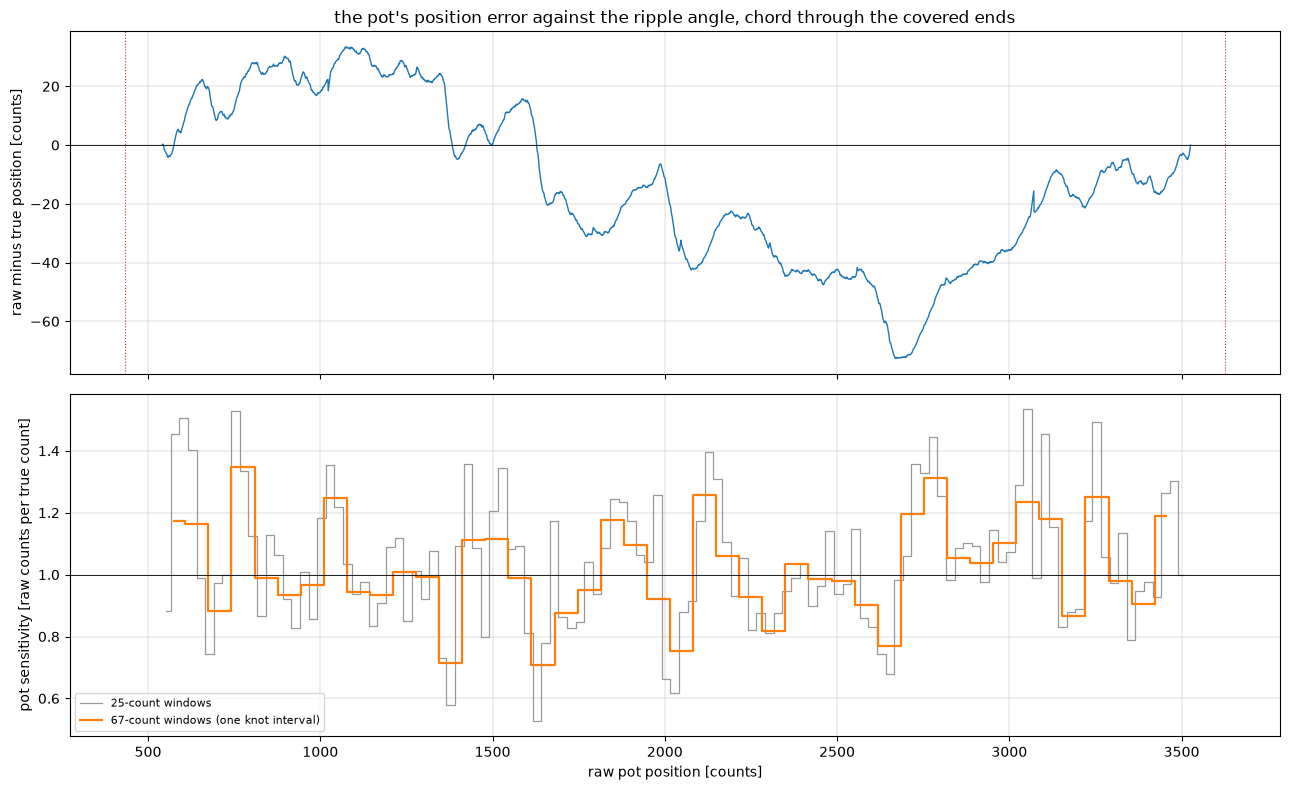

untrimmed coverage 493 .. 3552; at least 20 rungs over 541 .. 3526, 82.0% of the rails; 0.2599 ripple cycles per count on average
position error: raw minus true runs -72.6 .. +33.4 counts, 106.0 peak to peak


,sensitivity min,at,sensitivity max,at,max over min,speed error range [%]
window [raw counts],,,,,,
10,0.463,1366.0,6.611,3066.0,14.290,-54 .. +561
25,0.527,1628.5,1.534,3053.5,2.908,-47 .. +53
67,0.708,1646.5,1.347,775.5,1.901,-29 .. +35
200,0.845,1641.0,1.184,3041.0,1.401,-15 .. +18
500,0.914,1791.0,1.059,791.0,1.159,-9 .. +6


In [6]:
CORE = (15, 50)       # the duty band every route and every set tracks cleanly

def core(r, lo=CORE[0], hi=CORE[1]):
    return r["ok"] and lo <= abs(r["duty"]) <= hi

BAND = None           # set below: the stretch of travel at least 20 rungs cover

def chunks(rs, key="cyc", sel=core, band=True):
    # (pos, angle) from the first accepted sample to the end of each selected rung,
    # cut to BAND so a table's anchors never rest on one stray rung's extreme sample
    out = []
    for r in rs:
        if not sel(r):
            continue
        p, a = r["pos"][r["n0"]:], r[key][r["n0"]:]
        if band and BAND is not None:
            k = np.flatnonzero((p >= BAND[0]) & (p <= BAND[1]))
            if len(k) < 2:
                continue
            p, a = p[k[0]:k[-1] + 1], a[k[0]:k[-1] + 1]
        out.append((p, a))
    return out

S2 = rungs["2S session"]
st_all = poslut.stitch(chunks(S2), RAW_MIN, RAW_MAX)          # every accepted 2S core rung, untrimmed
well = np.flatnonzero(st_all.chunks >= 20) + RAW_MIN
BAND = (int(well.min()), int(well.max()))
st1 = poslut.stitch(chunks(S2), RAW_MIN, RAW_MAX)   # route 1, trimmed to BAND
LO, HI = st1.lo, st1.hi                             # the covered ends the table anchors on
x = np.arange(LO, HI + 1)                           # every covered raw count
lin = poslut.true_counts(st1, x)                    # the linearized count of each, no knots
C_LIN = (st1.cum[st1.lc] - st1.cum[st1.fc]) / (HI - LO)   # ripple cycles per linearized count

def sensitivity(xs, ys, w):
    # raw counts per linearized count over windows of w raw counts: 1 is the average,
    # above 1 the pot reads fast there, below 1 slow
    e = np.arange(xs[0], xs[-1] - w + 1, w)
    return e + w / 2, w / np.diff(np.interp(np.append(e, e[-1] + w), xs, ys))

dev = lin - x
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.plot(x, -dev, lw=1, color="tab:blue")
ax.axhline(0, color="k", lw=0.6)
for s in SOFT:
    ax.axvline(s, color="tab:red", lw=0.8, ls=":")
ax.set_ylabel("raw minus true position [counts]")
ax.set_title("the pot's position error against the ripple angle, chord through the covered ends")
ax.grid(True, lw=0.3)
ax = axes[1]
for w, col, lab in [(25, "0.6", "25-count windows"), (67, "tab:orange", "67-count windows (one knot interval)")]:
    c, s = sensitivity(x, lin, w)
    ax.step(c, s, where="mid", lw=0.9 if w == 25 else 1.6, color=col, label=lab)
ax.axhline(1, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("pot sensitivity [raw counts per true count]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

rows = []
for w in (10, 25, 67, 200, 500):
    c, s = sensitivity(x, lin, w)
    rows.append({"window [raw counts]": w, "sensitivity min": s.min(), "at": c[s.argmin()],
                 "sensitivity max": s.max(), "at ": c[s.argmax()], "max over min": s.max() / s.min(),
                 "speed error range [%]": f"{(s.min() - 1) * 100:+.0f} .. {(s.max() - 1) * 100:+.0f}"})
print(f"untrimmed coverage {st_all.lo} .. {st_all.hi}; at least 20 rungs over {LO} .. {HI}, {st1.coverage * 100:.1f}% of the rails; "
      f"{C_LIN:.4f} ripple cycles per count on average")
print(f"position error: raw minus true runs {(-dev).min():+.1f} .. {(-dev).max():+.1f} counts, "
      f"{(-dev).max() - (-dev).min():.1f} peak to peak")
pd.DataFrame(rows).set_index("window [raw counts]").round(3)

**What you are looking at.** Top, the raw reading minus the true position across the
covered travel, with the soft limits dotted. Bottom, the local sensitivity in 25-count
windows (grey) and in 67-count windows (orange), one table interval wide.

The raw pot wanders 106 counts peak to peak against the true angle, from +33 near raw
1100 to -73 near raw 2680. That is about 3% of the whole span, which sounds small, but
it is about 90 times the pot's rest noise of 1.2 counts, and it all comes in wiggles a few
hundred counts wide.

The sensitivity is the part that hurts speed. In 25-count windows it runs from 0.53 to
1.53, a factor of 2.9. In windows as wide as one knot interval it still runs from 0.71
to 1.35. The 10-count row is dominated by something else, a single code at raw 3072
that is eight codes wide (section 6), which is the converter and not the pot. For
comparison, notebook 06 found a 5.8x swing on the SG90 in 20 mV bins. The MG90's pot is
smoother than that, but a pot-derived speed still carries errors of roughly minus 30 to
plus 35% depending on position, and the position loop's gain in counts swings by the
same factor.

## 2. Route 1, the ripple

Each accepted rung gives a pot trace and a motor angle at every sample. The left plot
below is one 30% rung each way, the motor angle next to the pot travel scaled by the
average coupling. They track each other closely, which is the point of the whole
method, and the small differences between them are the pot.

The right plot is every accepted rung on its own. For each one I take its pot against
its motor angle, draw the straight line through its own two ends, and plot the
departure from that line. Each rung is independent, forward and reverse, twelve duties,
five captures, and they lie on top of each other.

**How the rungs are combined.** This follows `ident/src/lut.rs` step for step, and
`oscnb.potlut` is a port of it. For each rung, time step by time step, the motor angle
turned in that step is deposited into the pot count (or counts) the wiper sat on
during the step. Every count ends up holding the motor angle turned while the shaft
was there, the **density** in cycles per count, and a rung's deposits add up to exactly
its total angle. The pot's jitter of a count or two never reorders anything, because
the clock is the motor angle and it only ever moves forward. Rungs that cover the same
count are averaged, and the cumulative sum of the density is the true angle under each
raw count.

**How the table is fitted.** `lut.rs` then maps the covered ends onto their own
identity fractions, pins the rails at 0 and 1, and sets each knot's correction to the
count offset that lands it on the curve.

$$\text{corrected}(r_i) = r_i + c_i, \qquad r_i = r_{min} + i\,\frac{r_{max} - r_{min}}{54}$$

$$\text{linearize}(r) = \frac{\text{corrected}(r) - r_{min}}{r_{max} - r_{min}}$$

with straight lines between knots. I checked the port against the Rust code while
building this notebook. On three real rungs, with `lut::build` run through a scratch
example binary, the 55 corrections came out identical and `linearize` agreed to the
print precision (5e-10). The stitching step of `build_multi` is ported line by line
but was not run through Rust, because the Rust version computes its own phase from
the current and cannot take the ripple tracker's angle.

One consequence of the anchoring is worth saying out loud. Two tables built from rungs
that cover slightly different ends differ by a tilt, because each one is anchored on its
own ends. That tilt is a choice of reference and not a disagreement. Wherever this
notebook compares two builds, it removes it by taking both relative to the straight
line through two fixed counts (`potlut.chord_residual`), 1100 and 3050 unless it says
otherwise.

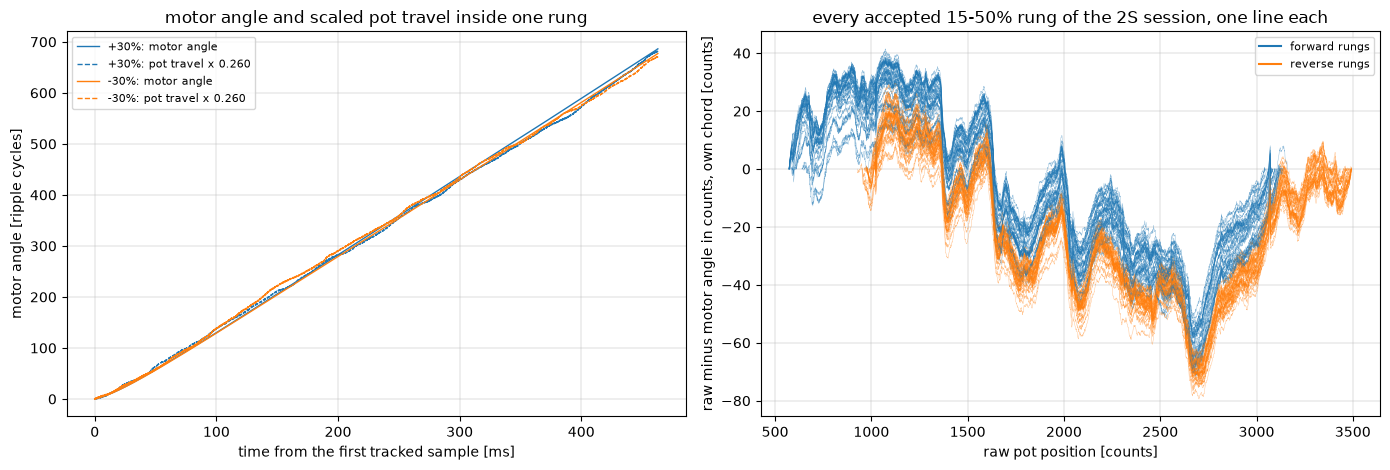

79 rungs; coverage by chunk count: [ 3 39 79] (min, 10th pct, median)


In [7]:
# One 30% rung each way: the motor angle and the pot against time, and the pot's
# departure from the motor angle inside the rung.
ex = [r for r in S2 if r["ok"] and r["cap"] == "capture-1" and abs(r["duty"]) == 30]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
for r, col in zip(ex, ["tab:blue", "tab:orange"]):
    n0 = r["n0"]
    t = np.arange(len(r["pos"]) - n0) * DT * 1e3
    ax.plot(t, r["cyc"][n0:] - r["cyc"][n0], color=col, lw=1, label=f"{r['duty']:+d}%: motor angle")
    ax.plot(t, np.abs(r["pos"][n0:] - r["pos"][n0]) * C_LIN, color=col, lw=1, ls="--",
            label=f"{r['duty']:+d}%: pot travel x {C_LIN:.3f}")
ax.set_xlabel("time from the first tracked sample [ms]")
ax.set_ylabel("motor angle [ripple cycles]")
ax.set_title("motor angle and scaled pot travel inside one rung")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
for r in S2:
    if not core(r):
        continue
    s = poslut.stitch(chunks([r], sel=lambda q: True), RAW_MIN, RAW_MAX)
    xs = np.arange(s.lo + 30, s.hi - 30)
    res = poslut.chord_residual(lambda z: poslut.true_counts(s, z), xs, xs[0], xs[-1])
    ax.plot(xs, -res, lw=0.3, alpha=0.5, color="tab:blue" if r["duty"] > 0 else "tab:orange")
ax.plot([], [], color="tab:blue", label="forward rungs")
ax.plot([], [], color="tab:orange", label="reverse rungs")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("raw minus motor angle in counts, own chord [counts]")
ax.set_title("every accepted 15-50% rung of the 2S session, one line each")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
print(f"{sum(core(r) for r in S2)} rungs; coverage by chunk count: "
      f"{np.percentile(st1.chunks[st1.fc:st1.lc], [0, 10, 50]).astype(int)} (min, 10th pct, median)")

**What you are looking at.** Left, one 30% rung forward (blue) and reverse (orange),
motor angle in solid and scaled pot travel in dashed, against time. Right, every
accepted rung's departure from its own straight line against raw position, forward in
blue and reverse in orange.

The rungs overlay to within a few counts everywhere. That is already most of proof rule
2 in one picture, and section 5 puts numbers on it.

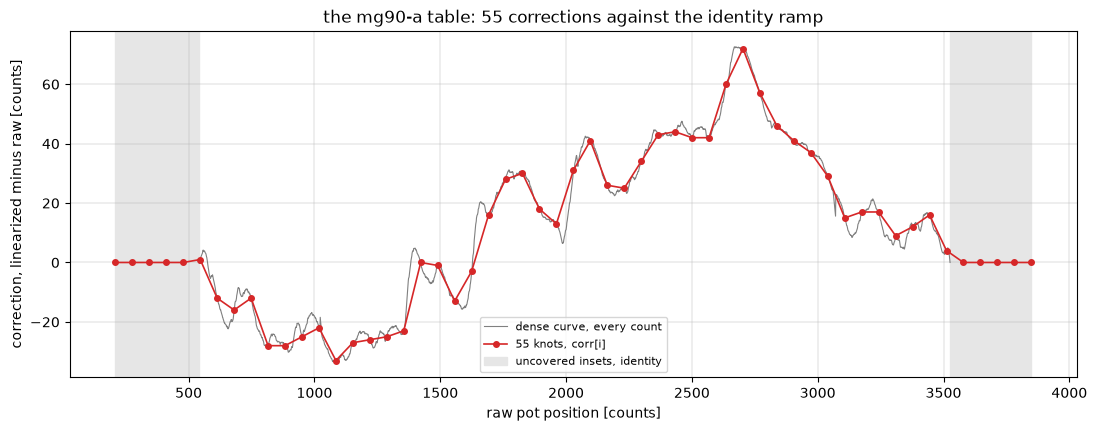

lut_corr = [0, 0, 0, 0, 0, 1, -12, -16, -12, -28, -28, -25, -22, -33, -27, -26, -25, -23, 0, -1, -13, -3, 16, 28, 30, 18, 13, 31, 41, 26, 25, 34, 43, 44, 42, 42, 60, 72, 57, 46, 41, 37, 29, 15, 17, 17, 9, 12, 16, 4, 0, 0, 0, 0, 0]
max |corr| 72 counts at raw 2703; endpoints map to themselves: counts(209) = 209.0, counts(3849) = 3849.0


In [8]:
LUT = poslut.from_stitch(st1, RAW_MIN, RAW_MAX)     # the table, lut.rs semantics
corr = np.array(LUT.corr)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(x, lin - x, lw=0.8, color="0.5", label="dense curve, every count")
ax.plot(LUT.points, corr, "o-", ms=4, lw=1.2, color="tab:red", label="55 knots, corr[i]")
ax.axvspan(RAW_MIN, LO, color="0.9")
ax.axvspan(HI, RAW_MAX, color="0.9", label="uncovered insets, identity")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("correction, linearized minus raw [counts]")
ax.set_title("the mg90-a table: 55 corrections against the identity ramp")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()
print("lut_corr =", list(LUT.corr))
print(f"max |corr| {np.abs(corr).max()} counts at raw {LUT.points[np.abs(corr).argmax()]:.0f}; "
      f"endpoints map to themselves: counts({RAW_MIN}) = {LUT.counts(RAW_MIN):.1f}, counts({RAW_MAX}) = {LUT.counts(RAW_MAX):.1f}")

The table itself. The grey curve is the dense correction, every count, and the red dots
are the 55 knots `lut.rs` would write. The shaded insets beyond 541 and 3526 are never
crossed by a well-covered rung, so the table leaves them at identity and tapers the
correction to zero across them. The soft limits (432 and 3626) sit inside those insets.

## 3. Route 2, the back-EMF

The second route has to reach the motor angle without the ripple and without the pot.
Back-EMF does it. A spinning motor generates a voltage proportional to its speed,
$e = K_e\,\omega$, and over one PWM period the motor's electrical equation gives

$$e = D\,(v_A - v_B) - R\,i$$

where $D$ is the duty, $v_A - v_B$ the crest-sampled terminal difference (the full rail
during the drive window, notebook 01) and $i$ the crest current. Integrating
$e / K_e$ over time gives motor angle.

The constant $K_e$ has to be in ripple units for the two routes to meet. I fit it against
the **ripple frequency** of each rung's settled window, never against the pot, so route 2
never touches the pot's scale. A free intercept $V_0$ goes in with it (notebook 08 found a
duty-dependent over-read at low duty) and forward and reverse get their own fit, since
the two directions sit a couple of percent apart. Current is a magnitude on this board,
low-side shunt, so it is never multiplied by the drive sign.

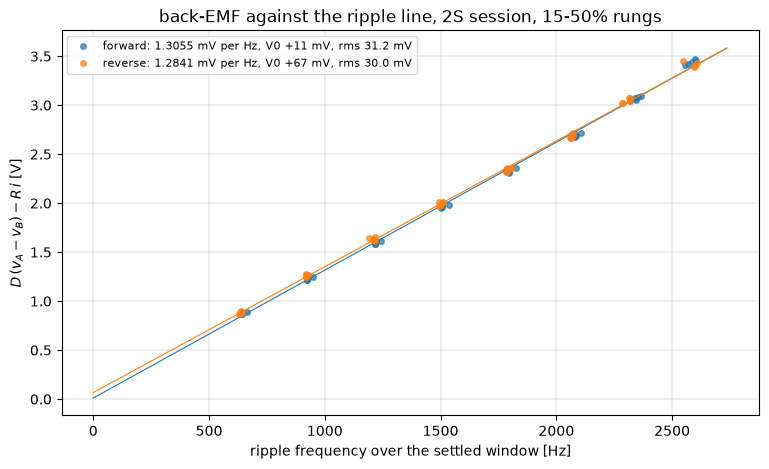

R 4.49 ohm: Ke fwd 1.3120 / rev 1.2926 mV per Hz, V0 +32 / +84 mV
R 4.89 ohm: Ke fwd 1.3055 / rev 1.2841 mV per Hz, V0 +11 / +67 mV
R 4.98 ohm: Ke fwd 1.3040 / rev 1.2821 mV per Hz, V0 +7 / +63 mV


In [9]:
# Route 2 needs back-EMF in ripple units. Over the settled window of every accepted
# 2S core rung: the period-mean terminal voltage D x (vA - vB) at the crest, minus
# R i, against the ripple frequency of the same window. The pot never enters.
def settled_point(r):
    a = int(len(r["pos"]) * 0.4)                                   # the last 60%
    if r["n0"] > a:
        return None
    D = np.abs(r["dq"][a:]) / Q15
    vd = (r["va"][a:].astype(float) - r["vb"][a:]) * np.sign(r["duty"]) * board.v_term_per_count
    i = r["cur"][a:] * board.a_per_count                           # current_raw is a magnitude, never signed
    f = (r["cyc"][-1] - r["cyc"][a]) / ((len(r["pos"]) - 1 - a) * DT)            # counted cycles over time
    return {"duty": r["duty"], "y": (D * vd).mean(), "i": i.mean(), "f": f, "valid": r["valid"][a:].mean()}

pts = pd.DataFrame([p for r in S2 if core(r) for p in [settled_point(r)] if p])
KE = {}
fig, ax = plt.subplots(figsize=(9, 5))
for sgn, col, lab in [(1, "tab:blue", "forward"), (-1, "tab:orange", "reverse")]:
    g = pts[np.sign(pts.duty) == sgn]
    e = g.y - R_OHM * g.i                                          # back-EMF in volts
    k, v0 = np.polyfit(g.f, e, 1)                                  # EMF on speed, not the other way
    KE[sgn] = (k, v0)
    ax.plot(g.f, e, "o", ms=4, color=col, alpha=0.7, label=f"{lab}: {k * 1e3:.4f} mV per Hz, V0 {v0 * 1e3:+.0f} mV, "
            f"rms {np.std(e - (k * g.f + v0)) * 1e3:.1f} mV")
    ff = np.linspace(0, g.f.max() * 1.05, 10)
    ax.plot(ff, k * ff + v0, color=col, lw=0.8)
ax.set_xlabel("ripple frequency over the settled window [Hz]")
ax.set_ylabel(r"$D\,(v_A - v_B) - R\,i$ [V]")
ax.set_title("back-EMF against the ripple line, 2S session, 15-50% rungs")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

# sensitivity to R across its bracket, same fit
m = servo.measured["r_winding_measured"]
for rr in (m.lo, m.value, m.hi):
    ks = [np.polyfit(pts[np.sign(pts.duty) == s].f, pts[np.sign(pts.duty) == s].y - rr * pts[np.sign(pts.duty) == s].i, 1)
          for s in (1, -1)]
    print(f"R {rr:.2f} ohm: Ke fwd {ks[0][0] * 1e3:.4f} / rev {ks[1][0] * 1e3:.4f} mV per Hz, "
          f"V0 {ks[0][1] * 1e3:+.0f} / {ks[1][1] * 1e3:+.0f} mV")

**What you are looking at.** Each dot is one rung's settled window, back-EMF against the
ripple frequency of the same window, forward in blue and reverse in orange, with each
direction's line. The printed rows refit the same thing at both ends of the $R$
bracket.

The fit is tight, about 30 mV rms against 0.9 to 3.5 V of EMF, and $K_e$ comes out 1.306 mV per ripple Hz forward
and 1.284 reverse, 1.7% apart, with intercepts of 11 and 67 mV. Moving $R$ across its
whole bracket moves $K_e$ by less than 1%, because the current barely changes between
15 and 50% duty. So the bracket on $R$ matters little for the scale, and the next cells
show what it does to the shape.

First the paired comparison, rung by rung. Each rung now has two motor angles on the
same samples, one from counting ripple and one from integrating back-EMF. For each rung
I compare the two shapes over the rung's own covered stretch, each against its own
straight line, so nothing about $K_e$'s scale can enter.

Per rung the two routes differ by 1.7 to 3.5 counts rms against a shape of 90 to 97
counts peak to peak. The largest single-rung differences, 5 to 11 counts, are at 15 to
25% forward. The total angle from route 2 lands within 2% of route 1 in every band.

In [10]:
def bemf_cycles(r, r_ohm=R_OHM, ke=None):
    # Motor angle from back-EMF: per sample EMF over Ke, integrated. Same samples
    # as route 1, a different clock.
    k, v0 = (ke or KE)[int(np.sign(r["duty"]))]
    D = np.abs(r["dq"]) / Q15
    vd = (r["va"].astype(float) - r["vb"]) * np.sign(r["duty"]) * board.v_term_per_count
    e = D * vd - r_ohm * r["cur"] * board.a_per_count - v0
    return np.cumsum(e / k) * DT

for rs in rungs.values():
    for r in rs:
        if r["ok"]:
            r["cyc2"] = bemf_cycles(r)

# Paired, rung by rung: each route's shape over the rung's own covered interval.
rows = []
for r in S2:
    if not core(r):
        continue
    s1 = poslut.stitch(chunks([r], "cyc", lambda q: True), RAW_MIN, RAW_MAX)
    s2 = poslut.stitch(chunks([r], "cyc2", lambda q: True), RAW_MIN, RAW_MAX)
    a, b = max(s1.lo, s2.lo) + 30, min(s1.hi, s2.hi) - 30
    xs = np.arange(a, b)
    r1 = poslut.chord_residual(lambda z: poslut.true_counts(s1, z), xs, a, b - 1)
    r2 = poslut.chord_residual(lambda z: poslut.true_counts(s2, z), xs, a, b - 1)
    rows.append({"duty": r["duty"], "shape pk-pk [counts]": np.ptp(r1),
                 "route 2 minus route 1, rms [counts]": np.std(r2 - r1),
                 "max [counts]": np.abs(r2 - r1).max(),
                 "cycles, route 2 over route 1": (r["cyc2"][-1] - r["cyc2"][r["n0"]]) / (r["cyc"][-1] - r["cyc"][r["n0"]])})
paired = pd.DataFrame(rows)
paired["dir"] = np.where(paired.duty > 0, "fwd", "rev")
paired["band"] = pd.cut(paired.duty.abs(), [14, 25, 40, 50], labels=["15-25%", "30-40%", "45-50%"])
paired.groupby(["band", "dir"], observed=True).mean(numeric_only=True).drop(columns="duty").round(3)

shape pk-pk [counts]  route 2 minus route 1, rms [counts]  max [counts]  cycles, route 2 over route 1
band   dir                                                                                                       
15-25% fwd                95.622                                3.538        10.902                         1.018
       rev                92.948                                2.479         8.884                         1.011
30-40% fwd                97.444                                3.072         9.653                         0.996
       rev                89.361                                2.225         7.211                         0.995
45-50% fwd                89.854                                1.776         5.801                         1.010
       rev                89.104                                1.699         4.993                         1.009

Now the pooled shapes, over the stretch from 1100 to 3050 where both directions run at
full speed, and the proof rule.

**The stated uncertainty.** Both routes read the same samples, so the capture-to-capture
scatter they share cancels in their difference. The honest error bar on the difference is
twice the standard error of the per-capture differences, plus the largest shape change
across the $R$ bracket. That bar is small, 0.6 counts median.

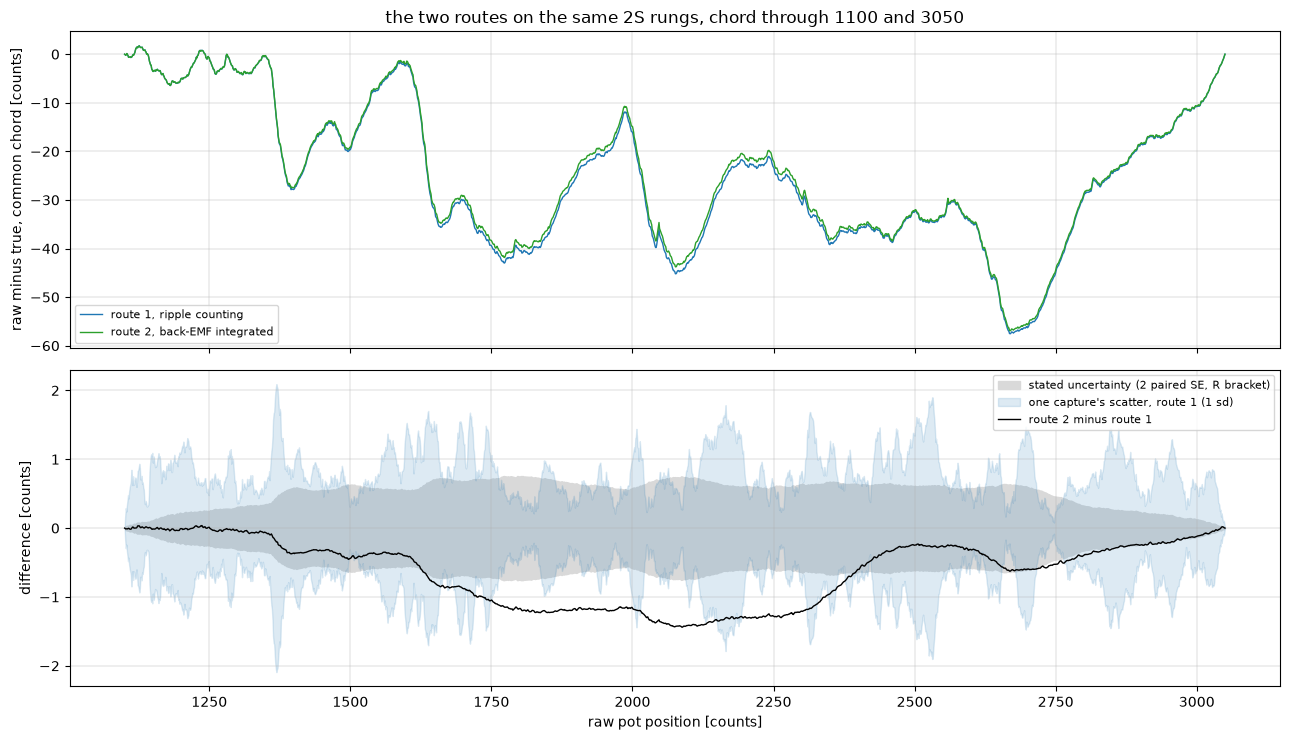

,value,unit
quantity,,
"route 1 shape, peak to peak",59.3,counts
"route 2 minus route 1, rms",0.47,counts
"route 2 minus route 1, max |.|",1.44,counts
"stated uncertainty, median / max",0.60 / 0.76,counts
counts outside the stated uncertainty,53.3,% of the interval
"R bracket alone, max",0.45,counts
"one capture's scatter, route 1, median / max sd",0.74 / 2.09,counts


In [11]:
st2 = poslut.stitch(chunks(S2, "cyc2"), RAW_MIN, RAW_MAX)
LUT2 = poslut.from_stitch(st2, RAW_MIN, RAW_MAX)
A, B = 1100, 3050                                    # common interval, well inside both directions' coverage
xc = np.arange(A, B + 1)
shape = lambda st, xs=xc: poslut.chord_residual(lambda z: poslut.true_counts(st, z), xs, A, B)

def per_capture(rs, key):
    # the pooled shape of each capture alone, in the common chord gauge
    caps = sorted({r["cap"] for r in rs})
    return np.array([shape(poslut.stitch(chunks(rs, key, lambda r, c=c: core(r) and r["cap"] == c), RAW_MIN, RAW_MAX))
                     for c in caps])

P1, P2 = per_capture(S2, "cyc"), per_capture(S2, "cyc2")
d12 = shape(st2) - shape(st1)
# The two routes read the same samples, so their capture scatter is shared. The
# standard error of the difference comes from the per-capture differences.
se = (P2 - P1).std(0, ddof=1) / np.sqrt(len(P1))
# route 2's own systematic: R across its bracket, Ke refitted at each end
m = servo.measured["r_winding_measured"]
def route2_stitch_at(rr):
    ke = {}
    for s in (1, -1):
        g = pts[np.sign(pts.duty) == s]
        ke[s] = tuple(np.polyfit(g.f, g.y - rr * g.i, 1))
    cs = [(r["pos"][r["n0"]:], bemf_cycles(r, rr, ke)[r["n0"]:]) for r in S2 if core(r)]
    return poslut.stitch(cs, RAW_MIN, RAW_MAX)
st2_lo, st2_hi = route2_stitch_at(m.lo), route2_stitch_at(m.hi)
r_sys = np.maximum(np.abs(shape(st2_lo) - shape(st2)), np.abs(shape(st2_hi) - shape(st2)))
U = 2 * se + r_sys                                 # stated uncertainty: 2 paired SE plus the R bracket

fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
ax = axes[0]
ax.plot(xc, -shape(st1), lw=1, color="tab:blue", label="route 1, ripple counting")
ax.plot(xc, -shape(st2), lw=1, color="tab:green", label="route 2, back-EMF integrated")
ax.set_ylabel("raw minus true, common chord [counts]")
ax.set_title(f"the two routes on the same 2S rungs, chord through {A} and {B}")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.fill_between(xc, -U, U, color="0.85", label="stated uncertainty (2 paired SE, R bracket)")
ax.fill_between(xc, -P1.std(0, ddof=1), P1.std(0, ddof=1), color="tab:blue", alpha=0.15,
                label="one capture's scatter, route 1 (1 sd)")
ax.plot(xc, d12, lw=1, color="k", label="route 2 minus route 1")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("difference [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame([
    ("route 1 shape, peak to peak", f"{np.ptp(shape(st1)):.1f}", "counts"),
    ("route 2 minus route 1, rms", f"{np.std(d12):.2f}", "counts"),
    ("route 2 minus route 1, max |.|", f"{np.abs(d12).max():.2f}", "counts"),
    ("stated uncertainty, median / max", f"{np.median(U):.2f} / {U.max():.2f}", "counts"),
    ("counts outside the stated uncertainty", f"{(np.abs(d12) > U).mean() * 100:.1f}", "% of the interval"),
    ("R bracket alone, max", f"{r_sys.max():.2f}", "counts"),
    ("one capture's scatter, route 1, median / max sd", f"{np.median(P1.std(0, ddof=1)):.2f} / {P1.std(0, ddof=1).max():.2f}", "counts"),
], columns=["quantity", "value", "unit"]).set_index("quantity")

**What you are looking at.** Top, the pooled shape from each route over the common
interval, raw minus true against a straight line through 1100 and 3050. Bottom, route 2
minus route 1 in black, the stated uncertainty in grey, and one capture's own scatter in
light blue for scale.

The two routes land on top of each other. They differ by 0.47 counts rms and 1.4 counts
at most, on a shape 59 counts peak to peak. By the letter of the rule that difference is
**resolved**, since it leaves the grey band over half the interval. So route 2 carries a
small systematic of about a count that the $R$ bracket does not explain. It is also smaller
than the scatter of one capture (sd up to 2.1 counts), a third of what 55 knots leave
behind (section 6), and about the size of the pot's rest noise. Over this stretch I call
proof rule 1 **met**, with that residual stated.

The middle is not the whole table. Below about 900 only forward rungs pass, and each of
them spends its first 80 to 500 counts (more at higher duty) still spinning up. Above about 3200 the same is true of the reverse
rungs. The next plot compares the routes over the whole covered range, as a ratio of the
two densities in 50-count windows so any disagreement shows up where it happens.

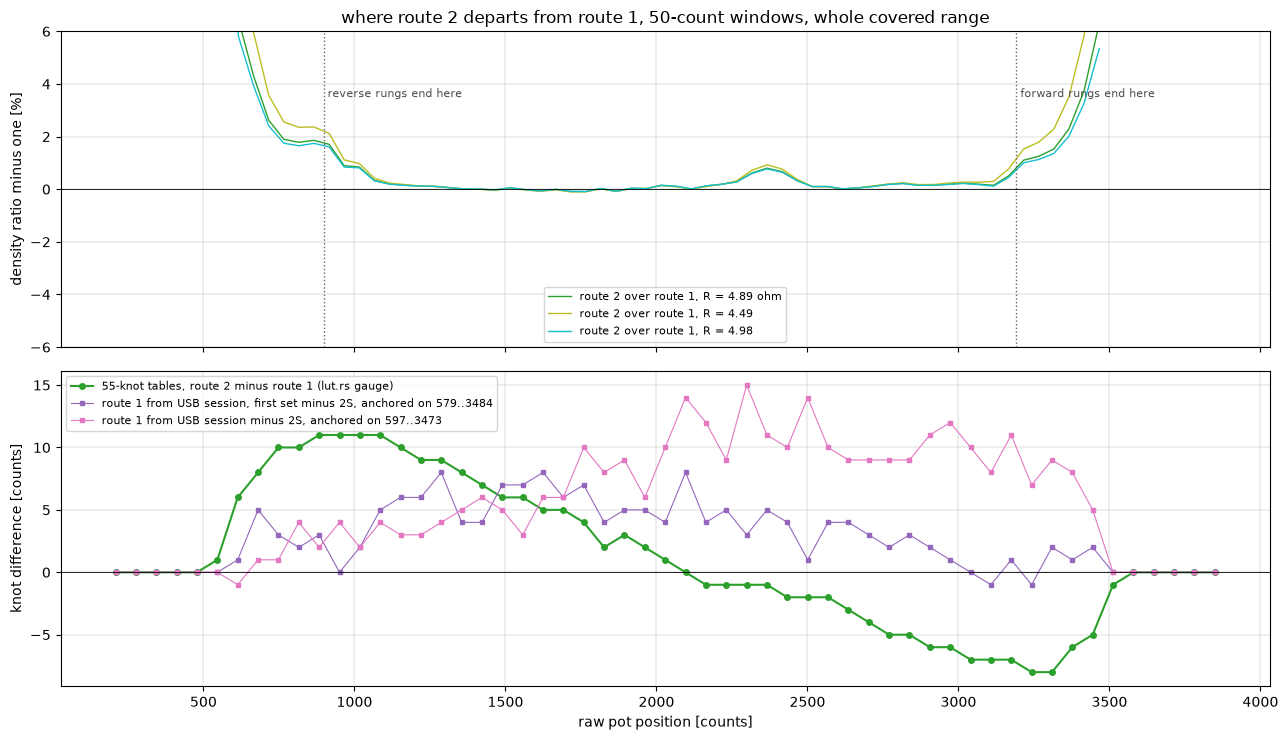

55-knot tables, route 2 minus route 1: max |.| 11 counts overall, 10 inside 1100..3050, 11 at the ends


mean [%]  rms [%]  max |.| [%]
end                        duty band                                
541..1000 (forward rungs)  15-20%        -0.58     2.17         6.08
                           25-30%        -0.92     2.32         6.45
                           35-40%        -0.75     2.31         6.77
                           45-50%        -0.68     2.61         7.24
3150..3526 (reverse rungs) 15-20%        -0.08     0.85         1.29
                           25-30%        -0.12     0.54         0.79
                           35-40%        -0.03     0.88         2.06
                           45-50%         0.44     0.95         2.10

In [12]:
# The whole covered range, where only one direction runs past each end. Route 2
# against route 1 as a density ratio in 50-count windows, so a disagreement shows
# where it happens instead of being smeared by an integral.
def density50(st, lo=LO, hi=HI, w=50):
    e = np.arange(lo, hi - w + 1, w)
    return e + w / 2, np.diff(st.angle(np.append(e, e[-1] + w))) / w

c50, d1 = density50(st1)
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
ax = axes[0]
for st, col, lab in [(st2, "tab:green", f"R = {R_OHM:g} ohm"), (st2_lo, "tab:olive", f"R = {m.lo:g}"), (st2_hi, "tab:cyan", f"R = {m.hi:g}")]:
    ax.plot(c50, (density50(st)[1] / d1 - 1) * 100, lw=1, color=col, label=f"route 2 over route 1, {lab}")
cover_f = poslut.stitch(chunks(S2, "cyc", lambda r: core(r) and r["duty"] > 0), RAW_MIN, RAW_MAX)
cover_r = poslut.stitch(chunks(S2, "cyc", lambda r: core(r) and r["duty"] < 0), RAW_MIN, RAW_MAX)
for xx_, lab in ((cover_r.lo, "reverse rungs end here"), (cover_f.hi, "forward rungs end here")):
    ax.axvline(xx_, color="0.4", ls=":", lw=1)
    ax.text(xx_, 3.5, " " + lab, fontsize=8, color="0.3")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylim(-6, 6)
ax.set_ylabel("density ratio minus one [%]")
ax.set_title("where route 2 departs from route 1, 50-count windows, whole covered range")
ax.legend(fontsize=8, loc="lower center")
ax.grid(True, lw=0.3)
ax = axes[1]
kd = np.array(LUT2.corr) - np.array(LUT.corr)
ax.plot(LUT.points, kd, "o-", ms=4, color="tab:green", label="55-knot tables, route 2 minus route 1 (lut.rs gauge)")
# route 1 from the USB sessions, which spin up at a different current and speed
for name, col in (("USB session, first set", "tab:purple"), ("USB session", "tab:pink")):
    su = poslut.stitch(chunks(rungs[name]), RAW_MIN, RAW_MAX)
    wu = np.flatnonzero(su.chunks >= 0.25 * su.chunks.max()) + RAW_MIN   # this set's well-covered stretch
    a, b = max(LO, wu.min()), min(HI, wu.max())    # both tables anchored on ends both sets cover well
    xs = np.arange(a, b + 1)
    table = lambda st: poslut.fit_points(xs, (st.angle(xs) - st.angle(a)) / (st.angle(b) - st.angle(a)), RAW_MIN, RAW_MAX)
    ax.plot(LUT.points, np.array(table(su).corr) - np.array(table(st1).corr), "s-", ms=3, lw=0.8, color=col,
            label=f"route 1 from {name} minus 2S, anchored on {a}..{b}")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("knot difference [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
ends = (LUT.points < A) | (LUT.points > B)
print(f"55-knot tables, route 2 minus route 1: max |.| {np.abs(kd).max()} counts overall, "
      f"{np.abs(kd[~ends]).max()} inside {A}..{B}, {np.abs(kd[ends]).max()} at the ends")

# Route 1 at the ends, split by duty band. Spin-up covers 80 to 500 counts depending on
# duty, so a spin-up bias in route 1 would make these bands disagree in a duty order.
rows = []
for sgn, (lo, hi) in ((1, (LO, 1000)), (-1, (3150, HI))):
    c0, d0 = density50(st1, lo, hi)
    for bl, bh in ((15, 20), (25, 30), (35, 40), (45, 50)):
        sb = poslut.stitch(chunks(S2, "cyc", lambda r: core(r, bl, bh) and np.sign(r["duty"]) == sgn), RAW_MIN, RAW_MAX)
        _, db = density50(sb, lo, hi)
        rel = (db / d0 - 1) * 100
        rows.append({"end": f"{lo}..{hi} ({'forward' if sgn > 0 else 'reverse'} rungs)", "duty band": f"{bl}-{bh}%",
                     "mean [%]": rel.mean(), "rms [%]": np.sqrt(np.mean(rel ** 2)), "max |.| [%]": np.abs(rel).max()})
pd.DataFrame(rows).set_index(["end", "duty band"]).round(2)

**What you are looking at.** Top, route 2's density over route 1's minus one, in percent,
for the pinned $R$ and both ends of its bracket, with the dotted lines where each
direction's rungs stop. Bottom, the 55-knot tables' knot-by-knot difference between the
routes (green), and route 1 from each USB dataset minus 2S route 1 (purple and pink),
each pair anchored on ends both sets cover well.

In the middle the density ratio sits within 1% of zero, the agreement above. Toward both
ends it climbs steadily, to 2% where only one direction runs and beyond 6% over the first
couple of hundred counts of every rung. The spin-up region is exactly where route 2 is
weakest. The current is several times its settled value there, so any error in $R\,i$, or
the inductive term I leave out, lands straight in the speed. Once anchored, those ends tilt
the whole route-2 table by up to 11 counts at a knot.

Route 1 at the ends has other checks. The spin-up length changes six-fold between 15% and
50% duty (about 80 to 500 counts). If spin-up biased route 1, its density near the ends
would follow the duty. The last table splits the end stretches by duty band. Every band's
mean sits within 1% of the pooled density (-0.9 to +0.4%), with no order in duty, and the
50-count scatter is 1 to 2.6% rms, which is what a quarter of the rungs gives. The USB route-1 tables, whose rungs spin up at a lower current, stay within 8 counts
(the first set) and 15 counts (the set recorded alongside this notebook) of 2S at every
knot, and their difference is a broad hump through the middle rather than something at
the ends. So a lower spin-up current does not visibly change route 1 at the ends. Section
5 comes back to the hump.

**Verdict on proof rule 1, from the session alone.** Met over 1100 to 3050, with a resolved
residual of 1.4 counts at most. **Not met** at the two ends, roughly 540 to 1100 and 3050 to
3530, where route 2 cannot be trusted during spin-up. From the session, the table there rests
on route 1 alone, supported by its independence from duty. The session cannot do better,
because at the ends it only ever has spin-up. The next part brings in a capture made to test
exactly that.

### The ends, at speed

To settle the ends I recorded a capture made for them, the `ends` experiment in the 2S
dataset. It has five captures, and each one is a 15% and a 20% rung in both directions
(`15@1277` and `20@897`, duty and window in ms), with the same seek guards at 532 and 3526
and the same telemetry as the session. The windows are long enough for each rung to cross
about 95% of the runway. So each end gets crossed at steady speed by the rung arriving from
the other side, forward rungs near the top and reverse rungs near the bottom.

It was recorded a few hours after the session on the same 2S pack, which by then sat at 7.37 V
instead of 7.83 V, so the speeds are a little lower.

The prediction is simple. If route 2 only reads high while the shaft spins up, then at speed
it should agree with route 1 at the ends as well as it does in the middle. If it still
disagrees at speed, one of the two routes has an error tied to position there.

In [13]:
# The ends capture, one row per rung. Route 1 needs nothing new. Route 2 needs to know
# when a rung is at speed, because back-EMF over-reads while the shaft spins up.
E = rungs["2S ends"]
caps_e = sorted({r["cap"] for r in E})
SMOOTH = 400          # samples, a 20 ms moving average on the ripple speed
AT_SPEED = 0.95       # a rung is at speed from the first sample within 5% of its settled speed

def ripple_speed(cyc):
    # motor speed in ripple cycles per second (ripple Hz), 20 ms moving average
    return np.convolve(np.gradient(cyc) * FS, np.ones(SMOOTH) / SMOOTH, "same")

def settled_speed(r):
    # median over the last 60% of the rung, the half box at the very end left out
    return np.median(ripple_speed(r["cyc"])[int(r["n"] * 0.4):-SMOOTH])

def at_speed_from(r, frac=AT_SPEED):
    # The first sample whose 20 ms speed reaches frac of the settled speed. From there on
    # the rung counts as at speed even where a load spot slows it a little again, since
    # that is load and not spin-up. None if the rung never gets there.
    f = ripple_speed(r["cyc"])
    k = np.arange(r["n0"], r["n"] - SMOOTH)
    hit = np.flatnonzero(f[k] >= frac * settled_speed(r))
    return int(k[hit[0]]) if len(hit) else None

def rail(d, exp, c):
    # rail at the start of a recording, from the estimator's vbus field (never vbus_raw)
    return board.rail_from_vbus_counts(d.recordings(exp, c)[0].meta["vbus_counts"])

rows = []
for r in E + [q for q in S2 if q["ok"] and abs(q["duty"]) in (15, 20)]:
    k = at_speed_from(r)
    rows.append({"set": r["set"], "cap": r["cap"], "duty": r["duty"], "accepted": r["ok"],
                 "rail [V]": rail(ds, "ends" if r["set"] == "2S ends" else "session", r["cap"]),
                 "settled speed [ripple Hz]": settled_speed(r),
                 "settled current [mA]": np.median(r["cur"][int(r["n"] * 0.4):]) * board.a_per_count * 1e3,
                 "start [raw]": r["pos"][0], "at speed from [raw]": r["pos"][k] if k is not None else np.nan,
                 "end [raw]": r["pos"][-1]})
ov = pd.DataFrame(rows)
display(ov[ov.set == "2S ends"].drop(columns="set").set_index(["cap", "duty"]).round(2))
print("2S session at the same duties, mean over its five captures:")
ov[ov.set == "2S session"].groupby("duty").mean(numeric_only=True).drop(columns="accepted").round(2)

accepted  rail [V]  settled speed [ripple Hz]  settled current [mA]  start [raw]  at speed from [raw]  end [raw]
cap       duty                                                                                                                  
capture-1  15       True      7.37                     592.61                 60.07          549                  702       3394
           20       True      7.37                     851.42                 67.23          529                  738       3379
          -15       True      7.37                     579.25                 59.18         3527                 3345        788
          -20       True      7.37                     837.58                 60.97         3494                 3301        708
capture-2  15       True      7.36                     571.08                 58.84          488                  702       3219
           20       True      7.36                     826.53                 66.01          536                  762       3304
          -15       True      7.36                     556.20                 57.05         3509                 3322        901
          -20       True      7.36                     817.45                 59.74         3493                 3278        805
capture-3  15       True      7.36                     559.11                 58.91          534                  721       3194
           20       True      7.36                     819.55                 66.07          505                 1006       3229
          -15       True      7.36                     548.03                 56.23         3501                 3310        920
          -20       True      7.36                     811.92                 59.81         3544                 3331        865
capture-4  15       True      7.36                     531.73                 56.86          493                  770       2994
           20       True      7.36                     799.23                 64.02          545                 1035       3187
          -15       True      7.36                     527.88                 55.07         3491                 3193        995
          -20       True      7.36                     787.14                 56.86         3525                 3290        928
capture-5  15       True      7.36                     524.77                 56.36          524                  736       2983
           20       True      7.36                     783.93                 65.31          546                 1023       3154
          -15       True      7.36                     519.19                 55.46         3513                 3184       1089
          -20       True      7.36                     780.48                 57.25         3497                 3195        933

2S session at the same duties, mean over its five captures:


,rail [V],settled speed [ripple Hz],settled current [mA],start [raw],at speed from [raw],end [raw]
duty,,,,,,
-20,7.83,924.69,60.13,3539.0,3315.4,980.0
-15,7.83,642.26,57.98,3547.0,3330.4,983.8
15,7.83,647.49,58.88,522.8,761.6,3116.8
20,7.83,931.78,66.93,525.8,794.2,3112.6


**What you are looking at.** One row per rung of the ends capture, then the session's 15 and
20% rungs for comparison. "At speed from" is the raw count where the rung first reaches 95% of
its settled speed (the ripple speed over 20 ms). From there on route 2 is used below.

All 20 rungs track and pass. The forward rungs reach speed between 702 and 1035 (the 20% ones
later, since they have further to accelerate) and run on to 2983 to 3394. The reverse rungs
reach speed between 3184 and 3345 and run down to 708 to 1089. So the lower end is crossed at
speed by reverse rungs arriving and by forward rungs just after they settle, and the upper end
the same way round.

Two things look different from the session. The speeds are lower, 525 to 593 ripple Hz at 15%
forward against 647 in the session, and the rail is 6% lower, which covers some of that. And
they fall from capture to capture, by 11% at 15% and 7% at 20% from the first capture to the
fifth, while the rail reads the same at the start of every one. That shortens the later
captures' reach too, capture 5's forward rungs stop near 2980 to 3150. The next cell looks at
the speed loss before it gets in route 2's way.

In [14]:
RB = servo.measured["r_winding_measured"]            # the pinned R and its bracket (section 3)

def fit_ke(rs, r_of, by_capture):
    # Ke and V0 per direction, and per capture when asked, from settled windows against
    # the ripple frequency exactly as in section 3. r_of(r) is the R rung r is corrected with.
    groups = {}
    for r in rs:
        p = settled_point(r) if r["ok"] else None
        if p:
            key = (r["cap"] if by_capture else None, int(np.sign(r["duty"])))
            groups.setdefault(key, []).append((p["f"], p["y"] - r_of(r) * p["i"]))
    return {key: tuple(np.polyfit(*np.array(v).T, 1)) for key, v in groups.items()}

def with_route2(rs, name, r_of, by_capture):
    # route 2 on every accepted rung, stored under `name`, each rung with its own R and Ke
    ke = fit_ke(rs, r_of, by_capture)
    for r in rs:
        if r["ok"]:
            s = int(np.sign(r["duty"]))
            r[name] = bemf_cycles(r, r_of(r), {s: ke[(r["cap"] if by_capture else None, s)]})
    return ke

# Route 2 at the pinned R and at both ends of its bracket. The session keeps section 3's
# pooled fit. The ends capture gets one fit per capture, for the reason the table shows.
S2c = [r for r in S2 if core(r)]
for sfx, rr in (("", R_OHM), ("_lo", RB.lo), ("_hi", RB.hi)):
    with_route2(S2c, "b_pin" + sfx, lambda r, rr=rr: rr, by_capture=False)
    ke_e = with_route2(E, "b_pin" + sfx, lambda r, rr=rr: rr, by_capture=True)
    if sfx == "":
        KE_E = ke_e

def rest_terminal(c):
    # terminal difference at rest, Hi-Z baseline after the 200 ms ring-down (a measurement offset check)
    df = ds.recordings("ends", c)[0].frame()
    b = df[df.seg == 0].iloc[4000:]
    return (b.vmotor_a - b.vmotor_b).mean()

ends_ov = ov[ov.set == "2S ends"].set_index(["cap", "duty"])
cal = pd.DataFrame([{"cap": c, "dir": "fwd" if s > 0 else "rev",
                     "Ke [mV per Hz]": KE_E[(c, s)][0] * 1e3, "V0 [mV]": KE_E[(c, s)][1] * 1e3,
                     "15% drive D (vA - vB) [V]": settled_point(next(r for r in E if r["cap"] == c and r["duty"] == 15 * s))["y"],
                     "15% settled speed [Hz]": ends_ov.loc[(c, 15 * s), "settled speed [ripple Hz]"],
                     "15% settled current [mA]": ends_ov.loc[(c, 15 * s), "settled current [mA]"],
                     "rest vA - vB [counts]": rest_terminal(c)}
                    for c in caps_e for s in (1, -1)]).set_index(["cap", "dir"])
print(f"route 2 fitted per ends capture at R = {R_OHM:g} ohm. Section 3's pooled session fit: "
      + ", ".join(f"{'fwd' if s > 0 else 'rev'} Ke {KE[s][0] * 1e3:.3f} mV per Hz, V0 {KE[s][1] * 1e3:+.0f} mV" for s in (1, -1)))
cal.round(3)

route 2 fitted per ends capture at R = 4.89 ohm. Section 3's pooled session fit: fwd Ke 1.305 mV per Hz, V0 +11 mV, rev Ke 1.284 mV per Hz, V0 +67 mV


Ke [mV per Hz]  V0 [mV]  15% drive D (vA - vB) [V]  15% settled speed [Hz]  15% settled current [mA]  rest vA - vB [counts]
cap       dir                                                                                                                             
capture-1 fwd           1.257   59.219                      1.097                 592.609                    60.072                 -4.619
          rev           1.383   14.754                      1.098                 579.248                    59.177                 -4.619
capture-2 fwd           1.289   71.865                      1.097                 571.084                    58.844                 -4.669
          rev           1.364   60.631                      1.098                 556.204                    57.053                 -4.669
capture-3 fwd           1.255  107.328                      1.097                 559.107                    58.913                 -4.664
          rev           1.333   90.072                      1.098                 548.034                    56.227                 -4.664
capture-4 fwd           1.224  167.752                      1.096                 531.726                    56.862                 -4.776
          rev           1.363  104.807                      1.098                 527.877                    55.071                 -4.776
capture-5 fwd           1.237  169.034                      1.096                 524.775                    56.355                 -4.728
          rev           1.358  119.521                      1.098                 519.190                    55.460                 -4.728

Route 2 needs $K_e$ and $V_0$, and the session's fit does not carry over as it is. Fitted the
same way on each capture's own settled windows, $K_e$ stays within a few percent of the
session's while $V_0$ climbs steadily over the five captures, from 59 to 169 mV forward and
from 15 to 120 mV reverse. The drive $D\,(v_A - v_B)$ at 15% reads 1.097 V in every capture
and the current even drops a little. So the lost speed goes into a voltage drop that does not
depend on speed. The last column rules out one candidate. The terminal difference at rest is
flat to 0.16 counts (0.4 mV) across the five captures, so it is not a drifting offset in the
measurement. The 2S session shows nothing like it, and it is listed as open at the bottom.

For this section it means route 2 on the ends capture gets one fit per capture. With one pooled
fit, rungs from different captures would carry different scale errors, and at the ends, where
only some rungs reach, the stitch would pick up a step wherever the mix of captures changes.

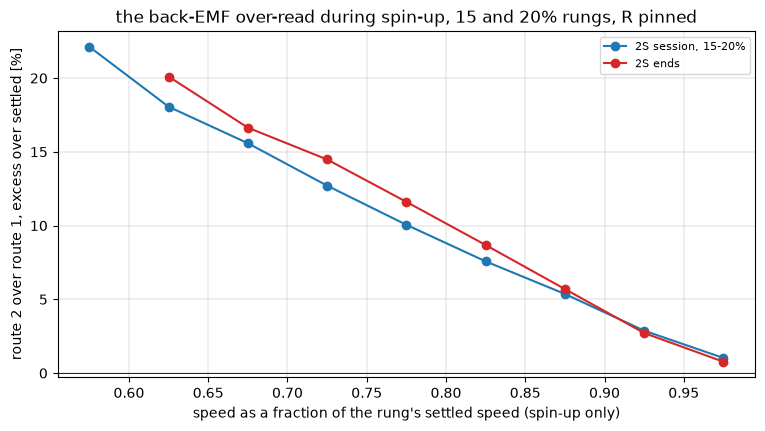

2S session, 15-20%        2S ends         
                          mean   size    mean     size
frac                                                  
(0.55, 0.6]              22.12      6     NaN      NaN
(0.6, 0.65]              18.06    438   20.10    230.0
(0.65, 0.7]              15.58   1230   16.64    943.0
(0.7, 0.75]              12.71   1796   14.48   1888.0
(0.75, 0.8]              10.05   2320   11.61   2793.0
(0.8, 0.85]               7.57   3350    8.68   4223.0
(0.85, 0.9]               5.36   6676    5.70  13511.0
(0.9, 0.95]               2.88  22814    2.72  27519.0
(0.95, 1.0]               1.02  30257    0.77  27949.0

In [15]:
# Route 2 over route 1, speed by speed, while each 15 or 20% rung spins up. Each rung's
# ratio is divided by its own settled ratio, so a scale error in Ke drops out and only
# the excess during spin-up is left.
def spinup_excess(rs):
    out = []
    for r in rs:
        if not r["ok"] or abs(r["duty"]) > 20:
            continue
        f1, f2 = ripple_speed(r["cyc"]), ripple_speed(r["b_pin"])
        ratio = f2 / f1
        settled_ratio = np.median(ratio[int(r["n"] * 0.4):-SMOOTH])
        end = at_speed_from(r, 0.99) or r["n"] - SMOOTH          # spin-up ends at 99% of settled speed
        k = np.arange(r["n0"] + SMOOTH // 2, end)                 # clear of the boxcar's start edge
        out.append(pd.DataFrame({"frac": f1[k] / settled_speed(r), "excess": (ratio[k] / settled_ratio - 1) * 100}))
    t = pd.concat(out)
    return t.groupby(pd.cut(t.frac, np.arange(0.5, 1.0001, 0.05)), observed=True).excess.agg(["mean", "size"])

su = {"2S session, 15-20%": spinup_excess(S2c), "2S ends": spinup_excess(E)}
fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, t), col in zip(su.items(), ["tab:blue", "tab:red"]):
    ax.plot([iv.mid for iv in t.index], t["mean"], "o-", color=col, label=name)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("speed as a fraction of the rung's settled speed (spin-up only)")
ax.set_ylabel("route 2 over route 1, excess over settled [%]")
ax.set_title("the back-EMF over-read during spin-up, 15 and 20% rungs, R pinned")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()
pd.concat(su, axis=1).round(2)

**What you are looking at.** Route 2's speed over route 1's, divided by the same ratio once
the rung has settled, against how far the rung has got toward its settled speed. Only the
spin-up part of each 15 and 20% rung, the session in blue and the ends capture in red.

This is the over-read section 3 blamed for the ends, measured directly. At 60% of settled
speed route 2 reads about 20% fast, at 80% about 10%, still 3% between 90 and 95%, and about
1% above that. The two recordings lie on the same curve, so it belongs to the spin-up and not
to one recording. It is also why the gate below starts at 95% and not lower.

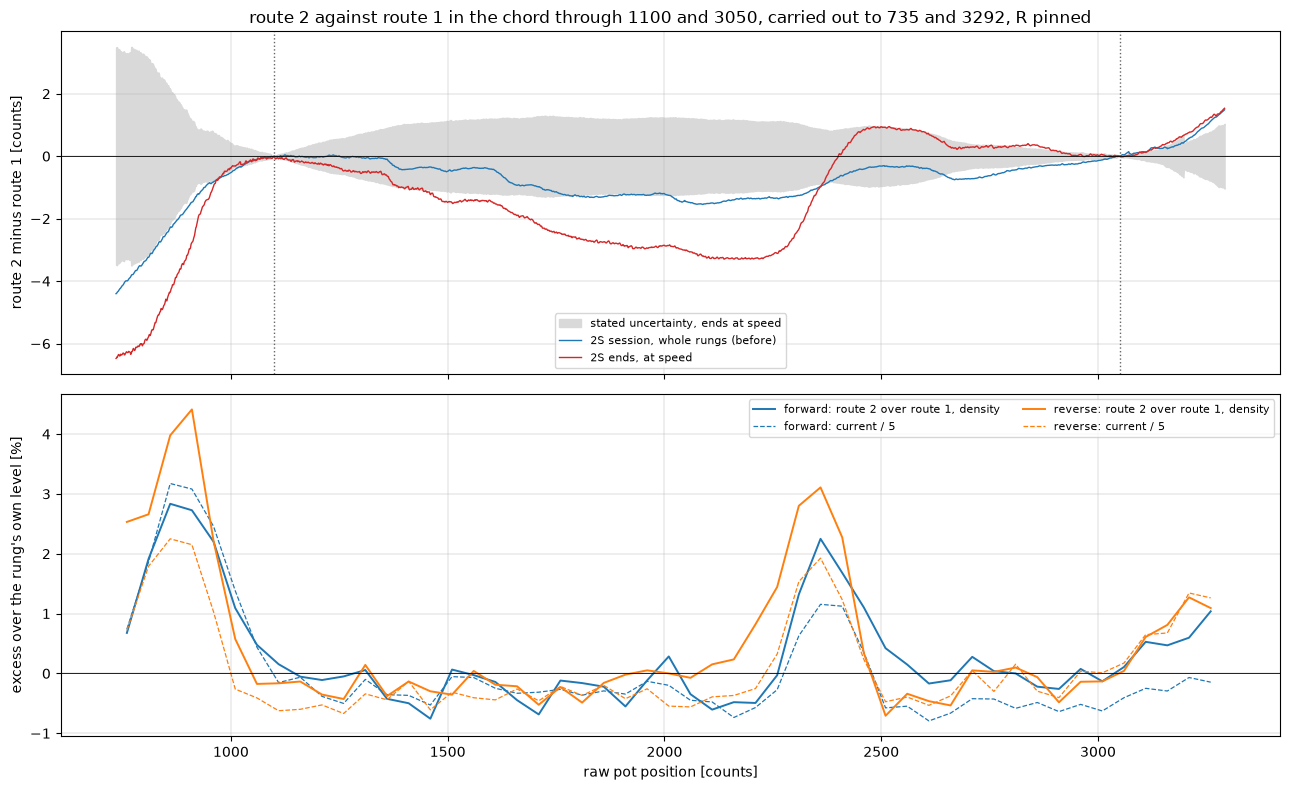

at-speed stretch 735..3292; route 1 on the ends capture, at speed minus whole rungs: lower end rms 0.36 max 1.21, middle rms 0.17 max 0.60, upper end rms 0.41 max 0.93


captures  rms [counts]  max |.| [counts]  U median  U max  outside U [%]
region    comparison                                                                                                
lower end session, whole rungs (before)            5          1.39              4.40      1.18   3.81          84.66
          session 15-20% only, whole rungs         5          2.99              8.54      1.77   5.64          84.11
          ends, at speed                           5          2.42              6.47      0.98   3.50          69.86
          ends, at speed from 90%                  5          2.68              7.52      1.18   3.93          72.60
middle    session, whole rungs (before)            5          0.49              1.55      0.57   0.80          61.05
          session 15-20% only, whole rungs         5          1.28              3.62      0.78   1.28          71.66
          ends, at speed                           5          1.40              3.30      0.96   1.30          56.64
          ends, at speed from 90%                  5          1.40              3.36      0.94   1.29          55.87
upper end session, whole rungs (before)            5          0.42              1.48      0.43   1.45          28.10
          session 15-20% only, whole rungs         5          0.13              0.42      0.73   2.17           4.55
          ends, at speed                           5          0.47              1.53      0.41   1.04          75.21
          ends, at speed from 90%                  5          0.62              2.05      0.42   1.60          80.58

In [16]:
def gated(rs, key, frac=AT_SPEED):
    # (pos, angle) of every accepted rung from the moment it is at speed, or from the
    # first tracked sample when frac is None (whole rungs, the way section 3 used them)
    out = []
    for r in rs:
        k = None if not r["ok"] else (r["n0"] if frac is None else at_speed_from(r, frac))
        if k is not None:
            out.append((r["pos"][k:], r[key][k:]))
    return out

def st_(ch):
    return poslut.stitch(ch, RAW_MIN, RAW_MAX)

# The stretch at least four of the five ends captures cross at speed.
cov_e = [st_(gated([r for r in E if r["cap"] == c], "cyc")) for c in caps_e]
LO_E, HI_E = sorted(s.lo for s in cov_e)[3], sorted(s.hi for s in cov_e)[-4]
XE = np.arange(LO_E, HI_E + 1)
REG = {"lower end": XE < A, "middle": (XE >= A) & (XE <= B), "upper end": XE > B}

def shape_e(st):
    # Section 3's chord through A and B, carried out to both ends. A density error at an
    # end then shows as a difference that grows past A or B instead of being tilted away.
    return poslut.chord_residual(lambda z: poslut.true_counts(st, z), XE, A, B)

def agreement(rs, key, frac, label):
    # Route 2 (stored under key) minus route 1 in that gauge, with section 3's stated
    # uncertainty: twice the paired standard error across captures plus the R bracket,
    # which is route 2 rebuilt under key + "_lo" and key + "_hi".
    d = shape_e(st_(gated(rs, key, frac))) - shape_e(st_(gated(rs, "cyc", frac)))
    per = []
    for c in sorted({r["cap"] for r in rs}):
        rc = [r for r in rs if r["cap"] == c]
        s1, s2 = st_(gated(rc, "cyc", frac)), st_(gated(rc, key, frac))
        inside = (XE >= max(s1.lo, s2.lo)) & (XE <= min(s1.hi, s2.hi))   # a capture speaks only where it reaches
        per.append(np.where(inside, shape_e(s2) - shape_e(s1), np.nan))
    per = np.array(per)
    n = np.sum(~np.isnan(per), axis=0)
    se = np.nanstd(per, axis=0, ddof=1) / np.sqrt(n)
    base = shape_e(st_(gated(rs, key, frac)))
    r_sys = np.maximum(*(np.abs(shape_e(st_(gated(rs, key + sfx, frac))) - base) for sfx in ("_lo", "_hi")))
    U = 2 * se + r_sys
    rows = [{"comparison": label, "region": reg, "captures": int(np.median(n[mm])),
             "rms [counts]": np.std(d[mm]), "max |.| [counts]": np.abs(d[mm]).max(),
             "U median": np.median(U[mm]), "U max": U[mm].max(), "outside U [%]": (np.abs(d[mm]) > U[mm]).mean() * 100}
            for reg, mm in REG.items()]
    return d, U, rows

d_before, U_before, rows_before = agreement(S2c, "b_pin", None, "session, whole rungs (before)")
_, _, rows_low = agreement([r for r in S2c if abs(r["duty"]) <= 20], "b_pin", None, "session 15-20% only, whole rungs")
d_after, U_after, rows_after = agreement(E, "b_pin", AT_SPEED, "ends, at speed")
_, _, rows_g90 = agreement(E, "b_pin", 0.90, "ends, at speed from 90%")

def along(rs, sgn, w=50):
    # Per 50-count window, at speed only: route 2 over route 1 in density (minus its
    # median, in %), and the current relative to each rung's own at-speed mean (in %).
    rs = [r for r in rs if r["ok"] and np.sign(r["duty"]) == sgn]
    e = np.arange(LO_E, HI_E - w + 1, w)
    edges = np.append(e, e[-1] + w)
    s1, s2 = st_(gated(rs, "cyc")), st_(gated(rs, "b_pin"))
    ratio = np.diff(s2.angle(edges)) / np.diff(s1.angle(edges))
    cur = []
    for r in rs:
        k = at_speed_from(r)
        c = r["cur"][k:].astype(float)
        cur.append(pd.DataFrame({"bin": np.digitize(r["pos"][k:], edges), "rel": c / c.mean()}))
    cur = pd.concat(cur).groupby("bin").rel.mean().reindex(np.arange(1, len(edges))).to_numpy()
    return e + w / 2, (ratio / np.median(ratio) - 1) * 100, (cur - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
ax.fill_between(XE, -U_after, U_after, color="0.85", label="stated uncertainty, ends at speed")
ax.plot(XE, d_before, color="tab:blue", lw=1, label="2S session, whole rungs (before)")
ax.plot(XE, d_after, color="tab:red", lw=1, label="2S ends, at speed")
for v in (A, B):
    ax.axvline(v, color="0.4", ls=":", lw=1)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("route 2 minus route 1 [counts]")
ax.set_title(f"route 2 against route 1 in the chord through {A} and {B}, carried out to {LO_E} and {HI_E}, R pinned")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
for sgn, col, lab in ((1, "tab:blue", "forward"), (-1, "tab:orange", "reverse")):
    c50e, dr, cr = along(E, sgn)
    ax.plot(c50e, dr, color=col, lw=1.4, label=f"{lab}: route 2 over route 1, density")
    ax.plot(c50e, cr / 5, color=col, lw=0.9, ls="--", label=f"{lab}: current / 5")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("excess over the rung's own level [%]")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

# route 1 alone: does it care whether the shaft is spinning up? Same ends rungs, at speed
# against whole rungs, same gauge.
r1 = shape_e(st_(gated(E, "cyc"))) - shape_e(st_(gated(E, "cyc", None)))
print(f"at-speed stretch {LO_E}..{HI_E}; route 1 on the ends capture, at speed minus whole rungs: " +
      ", ".join(f"{k} rms {np.std(r1[mm]):.2f} max {np.abs(r1[mm]).max():.2f}" for k, mm in REG.items()))
pd.DataFrame(rows_before + rows_low + rows_after + rows_g90).set_index(["region", "comparison"]).sort_index(
    level=0, sort_remaining=False).round(2)

**What you are looking at.** Top, route 2 minus route 1 in section 3's gauge, the chord through
1100 and 3050, carried on out to the stretch at least four of the five ends captures cross at
speed, 735 to 3292. Blue is the session with whole rungs as section 3 used them, red the ends
capture at speed, grey the stated uncertainty of the red line. Bottom, the ends capture at
speed per direction, route 2's density over route 1's in 50-count windows (solid) and the
current against each rung's own average (dashed, divided by 5 to share the axis), both relative
to their usual level.

The upper end agrees. Between 3050 and 3292 the routes differ by 0.47 counts rms and 1.5 at
most, the same as the middle in section 3 (0.47 and 1.4), and it is resolved against a tight
uncertainty in the same way.

At the lower end they do not agree. Between 735 and 1100 the difference is 2.4 counts rms and 6.5 at worst,
outside the stated uncertainty over 70% of the stretch. At speed it is even larger than what
the session's whole rungs showed there (1.4 and 4.4). Starting the gate at 90% makes it a little
worse (7.5 at worst), so the tail of the spin-up is not what is left. The ends capture's middle
is also worse than the session's, 1.4 counts rms against 0.5, and the session's own 15 to 20%
rungs show the same (1.3). Route 2 is simply weaker at low duty.

Route 1 is not the one moving. Built from the same ends rungs at speed, or with their spin-up
included, it gives the same shape to 0.36 counts rms (1.2 at most) at the lower end and 0.41 at
the upper end. Route 1 does not care whether the shaft is spinning up.

The bottom panel shows where route 2 goes wrong. Its density runs 3 to 4% high around raw 850 to
950 and 2 to 3% high around 2300 to 2400, in both directions, and the current rises in the same
places, by 11 to 16% and by 6 to 10%. These are load spots, stretches where something in the
train drags a bit more, so the shaft slows a little and the current rises. At a fixed duty the
back-EMF then has to drop by exactly the extra $R\,i$. If the pinned $R$ is too small for these
swings, route 2 misses part of each slowdown and reads fast right at the load spots, both ways.
That is a claim the data can test, and the next cell tests it.

R 25%  R median  R 75%  R median, other direction  rungs
set        duty                                                          
2S ends    15     7.17      7.71   7.79                       9.22     10
           20     7.23      7.70   8.74                      10.21     10
2S session 15     7.35      7.68   8.13                       8.25     10
           20     6.57      6.89   7.55                       8.27     10
           25     5.87      6.44   6.81                       7.38     10
           30     5.63      5.73   5.98                       7.13     10
           35     5.25      5.87   6.18                       6.63     10
           40     4.35      4.91   6.32                       5.95     10
           45     3.83      3.95   4.89                       5.35     10
           50     4.30      5.57   5.88                       7.17      9

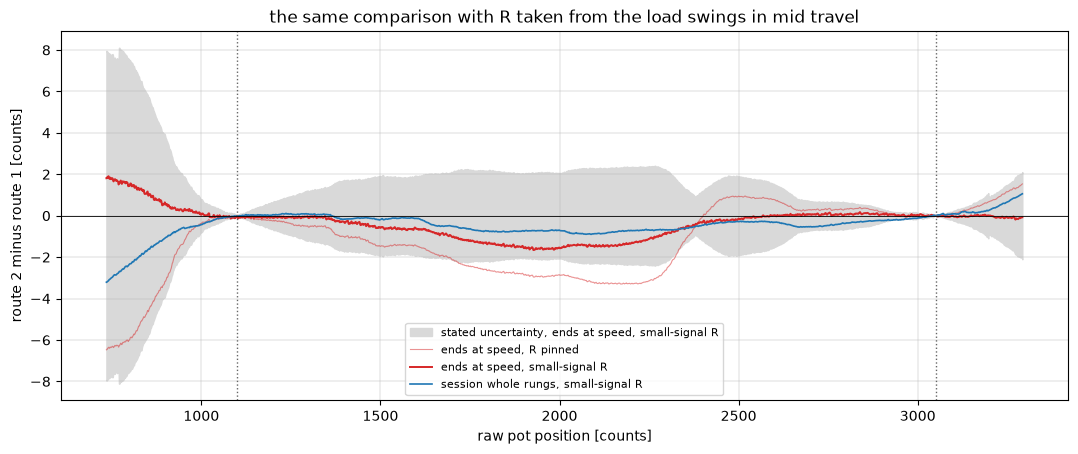

session spin-up excess in the first / last 50-count window: R pinned +11.1 / +6.3%, small-signal R +8.0 / +3.2%
55-knot tables, route 2 minus route 1, max |.|: R pinned 11 counts, small-signal R 8 counts


captures  rms [counts]  max |.| [counts]  U median  U max  outside U [%]
region    comparison                                                                                                    
lower end session, whole rungs (before)                5          1.39              4.40      1.18   3.81          84.66
          ends, at speed                               5          2.42              6.47      0.98   3.50          69.86
          session, whole rungs, small-signal R         5          0.97              3.21      1.43   4.83           4.11
          ends, at speed, small-signal R               5          0.65              1.91      2.90   8.11           2.47
middle    session, whole rungs (before)                5          0.49              1.55      0.57   0.80          61.05
          ends, at speed                               5          1.40              3.30      0.96   1.30          56.64
          session, whole rungs, small-signal R         5          0.29              0.90      0.68   1.02           0.00
          ends, at speed, small-signal R               5          0.60              1.66      1.75   2.41           0.41
upper end session, whole rungs (before)                5          0.42              1.48      0.43   1.45          28.10
          ends, at speed                               5          0.47              1.53      0.41   1.04          75.21
          session, whole rungs, small-signal R         5          0.29              1.06      0.62   2.07           1.65
          ends, at speed, small-signal R               5          0.05              0.19      0.74   2.10           0.00

In [17]:
def r_small_signal(r, lo=A, hi=B):
    # At one duty the drive D (vA - vB) hardly moves along a rung. Where a load spot slows
    # the shaft the current rises, and the back-EMF has to fall by Ke times the speed drop.
    # So over the at-speed part of a rung, D (vA - vB) - Ke f against i has slope R, the R
    # the equation needs for these small swings. 20 ms boxes, overlapping by three quarters.
    # Mid travel only, so the ends stay a held-out test. Returns the slope fitted both ways.
    k = at_speed_from(r)
    box = lambda v: np.convolve(v, np.ones(SMOOTH) / SMOOTH, "valid")[::SMOOTH // 4]
    D = np.abs(r["dq"][k:]) / Q15
    y = box(D * (r["va"][k:].astype(float) - r["vb"][k:]) * np.sign(r["duty"]) * board.v_term_per_count)
    i = box(r["cur"][k:] * board.a_per_count)
    f = box(np.gradient(r["cyc"][k:]) * FS)
    p = box(r["pos"][k:].astype(float))
    mm = (p >= lo) & (p <= hi)
    if mm.sum() < 20:
        return np.nan, np.nan
    ke = KE[int(np.sign(r["duty"]))][0]
    y_on_i = np.polyfit(i[mm], y[mm] - ke * f[mm], 1)[0]
    i_on_f = -ke / np.polyfit(f[mm], i[mm], 1)[0]        # the other regression direction, as a check
    return y_on_i, i_on_f

rss = pd.DataFrame([{"set": r["set"], "duty": abs(r["duty"]), "cap": r["cap"],
                     **dict(zip(("R", "R, other direction"), r_small_signal(r)))}
                    for r in S2c + E if r["ok"]])
RSS = rss.groupby(["set", "duty"]).R.quantile([0.25, 0.5, 0.75]).unstack()      # per set and duty
tab_r = RSS.rename(columns={0.25: "R 25%", 0.5: "R median", 0.75: "R 75%"})
tab_r["R median, other direction"] = rss.groupby(["set", "duty"])["R, other direction"].median()
tab_r["rungs"] = rss.groupby(["set", "duty"]).R.count()
display(tab_r.round(2))

# Route 2 again with that R, per set and duty, Ke refitted. The bracket is the quartiles.
for sfx, q in (("", 0.5), ("_lo", 0.25), ("_hi", 0.75)):
    r_of = lambda r, q=q: RSS.loc[(r["set"], abs(r["duty"])), q]
    with_route2(S2c, "b_ss" + sfx, r_of, by_capture=False)
    with_route2(E, "b_ss" + sfx, r_of, by_capture=True)

d_ss_s, U_ss_s, rows_ss_s = agreement(S2c, "b_ss", None, "session, whole rungs, small-signal R")
d_ss_e, U_ss_e, rows_ss_e = agreement(E, "b_ss", AT_SPEED, "ends, at speed, small-signal R")

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.fill_between(XE, -U_ss_e, U_ss_e, color="0.85", label="stated uncertainty, ends at speed, small-signal R")
ax.plot(XE, d_after, color="tab:red", lw=0.8, alpha=0.5, label="ends at speed, R pinned")
ax.plot(XE, d_ss_e, color="tab:red", lw=1.4, label="ends at speed, small-signal R")
ax.plot(XE, d_ss_s, color="tab:blue", lw=1.2, label="session whole rungs, small-signal R")
for v in (A, B):
    ax.axvline(v, color="0.4", ls=":", lw=1)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("route 2 minus route 1 [counts]")
ax.set_title("the same comparison with R taken from the load swings in mid travel")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

# What the small-signal R does to section 3's session numbers: the spin-up excess in the
# outermost 50-count windows, and the 55-knot tables in lut.rs's own gauge.
st2_ss = poslut.stitch(chunks(S2, "b_ss"), RAW_MIN, RAW_MAX)
ex_pin, ex_ss = (density50(st2)[1] / d1 - 1) * 100, (density50(st2_ss)[1] / d1 - 1) * 100
print(f"session spin-up excess in the first / last 50-count window: R pinned {ex_pin[0]:+.1f} / {ex_pin[-1]:+.1f}%, "
      f"small-signal R {ex_ss[0]:+.1f} / {ex_ss[-1]:+.1f}%")
print(f"55-knot tables, route 2 minus route 1, max |.|: R pinned {np.abs(kd).max()} counts, "
      f"small-signal R {np.abs(np.array(poslut.from_stitch(st2_ss, RAW_MIN, RAW_MAX).corr) - corr).max()} counts")
pd.DataFrame(rows_before + rows_after + rows_ss_s + rows_ss_e).set_index(["region", "comparison"]).sort_index(
    level=0, sort_remaining=False).round(2)

**What you are looking at.** The table is the $R$ each rung's own load swings call for, fitted
over mid travel only (1100 to 3050), per set and duty, with its quartiles across rungs and the
median of the same fit done the other way round. The plot is the comparison again with route 2
using that $R$, the ends capture at speed in red (the pinned-$R$ line faint behind it), the
session's whole rungs in blue, and in grey the stated uncertainty of the red line.

How the $R$ is measured. Along one rung the duty is fixed and the drive barely moves. Where a
load spot slows the shaft by $\delta f$ the current rises by $\delta i$, and section 3's equation
says $K_e\,\delta f = -R\,\delta i$. The ripple gives $\delta f$, the shunt gives $\delta i$, and
a regression over 20 ms boxes gives $R$. The pot never enters, the same as for $K_e$.

At 15 and 20% duty it comes out at about 7.7 ohm on both recordings, against the 4.89 section 3
pinned from the onset regression. In the session it falls with duty, to 5.7 at 30% and 4 to 5.6
at 45 to 50%. Fitting the slope the other way round gives 8 to 10 ohm at low duty. Both variables
carry some noise, which pulls the two fits apart in opposite directions, so the value is only
good to about 20%. What matters here is that it is far above 4.89 at the duties the ends capture
uses.

With it, fitted in mid travel and used unchanged at the ends, the lower end falls from 2.4 to
0.65 counts rms and from 6.5 to 1.9 at most, and the upper end from 0.47 to 0.05. The middle is
partly fitted into agreement this way, so I do not count it as evidence, but the ends were held
out. The session's middle improves too, from 0.49 to 0.29 counts rms (0.9 at most), so section
3's resolved residual of about a count was the same thing. At the outermost 50 counts, where the
session only has spin-up, the over-read shrinks from 11 to 8% at the bottom and from 6 to 3% at
the top. So this $R$ explains part of the spin-up over-read and not all of it.

The stated uncertainty is wider with this $R$ (2.9 counts median at the lower end), because its
quartiles are wider than the pinned bracket. That is the cost of an $R$ I only know to about 20%.
I lean on the rms instead, which drops by a factor of four on stretches this $R$ never saw.

**Verdict on proof rule 1 at the ends.** Met at the upper end, 3050 to 3292, at the pinned $R$,
with the same residual of about a count as the middle. Met at the lower end, 735 to 1100, once
route 2 uses the $R$ its own load swings call for. At the pinned $R$ it is not met there (6.5
counts at worst), and the cause sits in route 2, not in the table. So route 1 has a second route
behind it from 735 to 3292.

What is still uncovered is the stretch only spin-up ever crosses, 540 to 735 at the bottom and
3292 to 3526 at the top, about 200 and 230 counts next to the guards. There the table rests on
route 1 alone, backed by its independence from duty (section 3's duty-band table) and from
spin-up (the at-speed test above). Beyond the covered range it tapers to identity as before.

## 4. Backlash

The gears have play. When the motor reverses it turns a little before the teeth on the
other flank engage and the output starts to follow. That is backlash, and on the pot axis
it would show up as forward and reverse traces offset by a constant.

The stitch works on density, cycles per count, and a constant offset between two traces
has no density. So backlash cannot leak into the table, and the claim "forward and reverse
differ only by a constant offset" turns into something testable. Forward-only and
reverse-only tables should have the same shape. The next cell checks that.

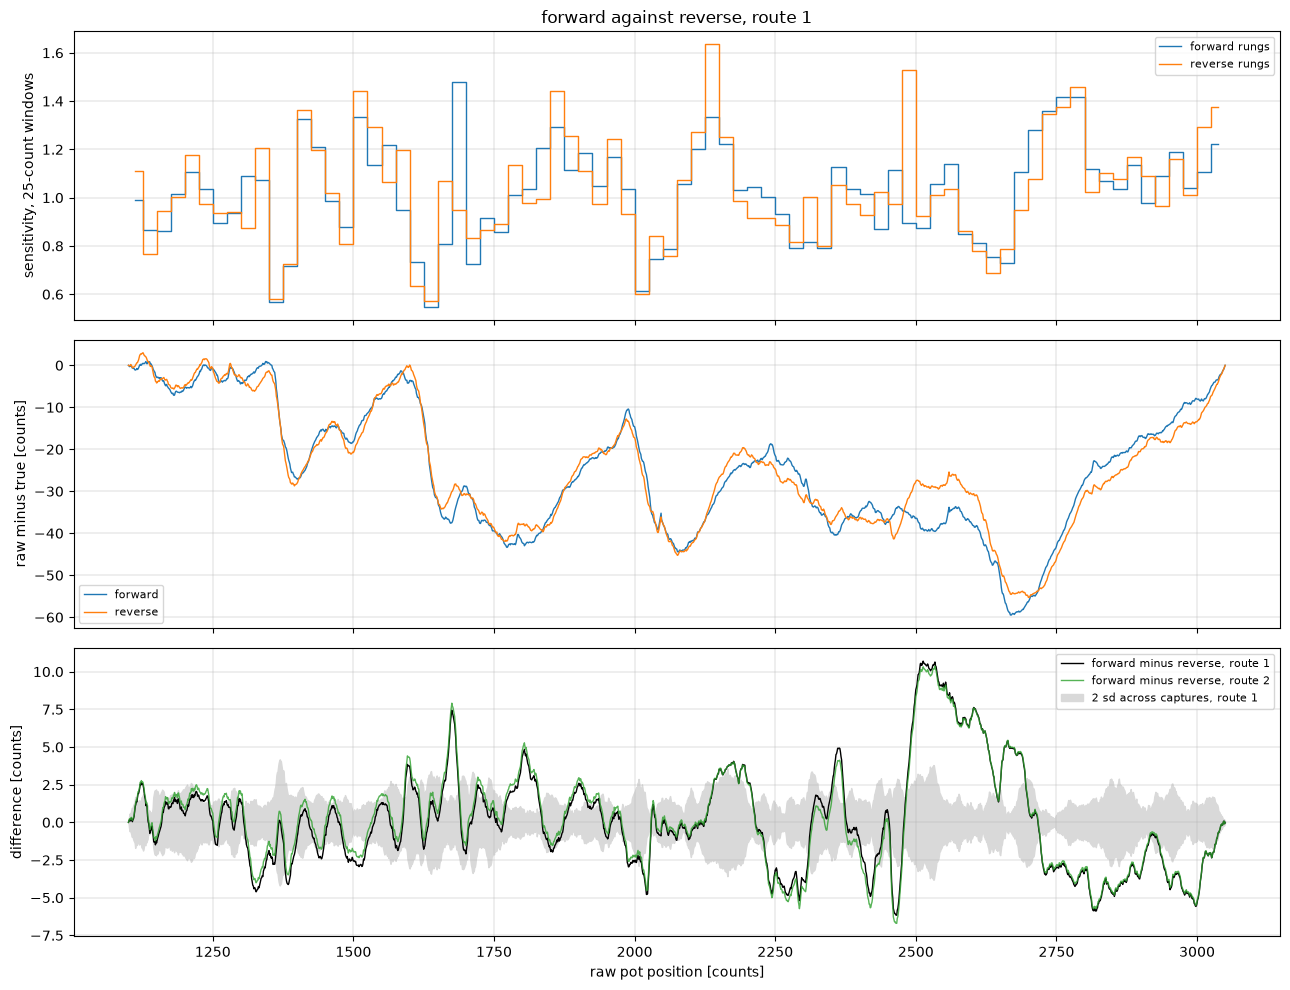

forward minus reverse, route 1: rms 3.38, max 10.7 counts at raw 2513; route 2: rms 3.36, max 10.4; the two routes' differences correlate r = 0.993
45.6% of the interval differs by more than twice the capture scatter of a difference


,settled current [A],"fwd minus rev, rms [counts]",peak in 2400..2750 [counts]
duty band,,,
15-25%,0.064,3.532,11.533
30-40%,0.080,3.325,10.322
45-50%,0.093,3.418,10.938


,"fwd minus rev, rms [counts]"
reverse map shifted by [counts],
-6,3.74
-4,3.56
-2,3.43
0,3.38
2,3.41
4,3.49
6,3.66


In [18]:
sel_f = lambda r: core(r) and r["duty"] > 0
sel_r = lambda r: core(r) and r["duty"] < 0
sf1, sr1 = (poslut.stitch(chunks(S2, "cyc", s), RAW_MIN, RAW_MAX) for s in (sel_f, sel_r))
sf2, sr2 = (poslut.stitch(chunks(S2, "cyc2", s), RAW_MIN, RAW_MAX) for s in (sel_f, sel_r))
dfr1, dfr2 = shape(sf1) - shape(sr1), shape(sf2) - shape(sr2)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
ax = axes[0]
for s, col, lab in [(sf1, "tab:blue", "forward rungs"), (sr1, "tab:orange", "reverse rungs")]:
    c, v = sensitivity(xc, poslut.true_counts(s, xc), 25)
    ax.step(c, v, where="mid", color=col, lw=1, label=lab)
ax.set_ylabel("sensitivity, 25-count windows")
ax.set_title("forward against reverse, route 1")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
ax.plot(xc, -shape(sf1), color="tab:blue", lw=1, label="forward")
ax.plot(xc, -shape(sr1), color="tab:orange", lw=1, label="reverse")
ax.set_ylabel("raw minus true [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[2]
ax.plot(xc, dfr1, color="k", lw=1, label="forward minus reverse, route 1")
ax.plot(xc, dfr2, color="tab:green", lw=1, alpha=0.8, label="forward minus reverse, route 2")
ax.fill_between(xc, -2 * P1.std(0, ddof=1), 2 * P1.std(0, ddof=1), color="0.85", label="2 sd across captures, route 1")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("difference [counts]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
k = np.abs(dfr1).argmax()
print(f"forward minus reverse, route 1: rms {np.std(dfr1):.2f}, max {np.abs(dfr1).max():.1f} counts at raw {xc[k]}; "
      f"route 2: rms {np.std(dfr2):.2f}, max {np.abs(dfr2).max():.1f}; the two routes' differences correlate "
      f"r = {np.corrcoef(dfr1, dfr2)[0, 1]:.3f}")
out = np.abs(dfr1) > 2 * np.sqrt(2) * P1.std(0, ddof=1)
print(f"{out.mean() * 100:.1f}% of the interval differs by more than twice the capture scatter of a difference")

# A test of one candidate cause. If the difference were the train winding up under
# its load, it would grow with the drive current. Split by duty band: the current
# rises about half again from 15-25% to 45-50%.
rows = []
peak = (xc > 2400) & (xc < 2750)
for lo, hi in ((15, 25), (30, 40), (45, 50)):
    f_ = poslut.stitch(chunks(S2, "cyc", lambda r: core(r, lo, hi) and r["duty"] > 0), RAW_MIN, RAW_MAX)
    r_ = poslut.stitch(chunks(S2, "cyc", lambda r: core(r, lo, hi) and r["duty"] < 0), RAW_MIN, RAW_MAX)
    d = shape(f_) - shape(r_)
    cur = np.mean([np.mean(r["cur"][int(len(r["cur"]) * 0.4):]) * board.a_per_count
                   for r in S2 if core(r, lo, hi)])
    rows.append({"duty band": f"{lo}-{hi}%", "settled current [A]": cur, "fwd minus rev, rms [counts]": np.std(d),
                 "peak in 2400..2750 [counts]": d[peak].max()})
display(pd.DataFrame(rows).set_index("duty band").round(3))

# A second candidate. Play in the pot's own coupling (the plastic D-key) or wiper
# hysteresis would shift the whole reverse map along the pot axis by a few counts. Slide
# it and see which shift lines the two directions up best.
rows = []
for dsh in range(-6, 7, 2):
    shifted = poslut.chord_residual(lambda z: poslut.true_counts(sr1, np.asarray(z) + dsh), xc, A, B)
    rows.append({"reverse map shifted by [counts]": dsh, "fwd minus rev, rms [counts]": np.std(shape(sf1) - shifted)})
pd.DataFrame(rows).set_index("reverse map shifted by [counts]").round(2)

**What you are looking at.** Top, sensitivity in 25-count windows from forward rungs
(blue) and reverse rungs (orange). Middle, the two shapes against the common chord. Bottom,
forward minus reverse from route 1 (black) and route 2 (green), with twice one capture's
scatter in grey.

Mostly they agree, which is the constant-offset picture. But not entirely. The difference
is 3.4 counts rms and reaches 10.7 counts near raw 2513, and it goes beyond the capture
scatter over 46% of the interval. Route 2 sees the same difference (10.4 counts, correlation
0.993), so this is the output and the pot, not the tracker. The largest feature is a bump
between about 2450 and 2700 that the forward pass reads higher than the reverse.

The last table tests one candidate cause. If this were the train winding up elastically
under its load, the difference would grow with the drive current. The current rises by
half from the 15-25% band to the 45-50% band, and the difference does not move (10.3 to
11.5 counts at the peak, no trend). So wind-up under drive current is not it.

The second table tests another. Play in the pot's own coupling to the output (a plastic D-key
on this servo), or plain wiper hysteresis, would slide the whole reverse map a few counts along
the pot axis. Sliding it back should then line the two directions up. It does not. The best
shift is zero, and every shift makes the match worse, so a constant pot-side offset is ruled
out to within a couple of counts. What is left is local, and a story until tested (the open
questions list the test). The two candidates I have are a wiper that contacts the track
slightly differently each way over one textured patch, and tooth transmission error that
differs between the two flanks of a mesh.

For the table this means the combined curve averages the two directions, and each
direction on its own is off by up to about 5 counts near that bump. That is about what
55 knots leave behind anyway. The firmware table has one curve, not two.

The constant part of the backlash, measured directly. Each session capture has a reversal
block, a 60 ms drive at 20% or 40% then an immediate flip to the opposite sign, chained with
no gap. This is notebook 06's method. After the flip the pot stops, turns round and comes
back. While it sits within 2 counts of its turning point, I count the commutation steps in
the current, which the motor makes while the output stands still. The step detector is the
one from notebook 06, a one-sample jump of at least 10% of the local current, rerun at 8% and
12% to show the count does not hang on the threshold.

In [19]:
PLATEAU = 2           # counts: the pot 'stands still' within this of its extreme (nb06 sec 7)
EDGE = 10             # samples ignored at both ends of the post-flip segment

def flip_pairs(meta):
    # (segment before, segment after) for every chained flip: a then: step after a drive step
    sched, n = meta["schedule"], len(meta["schedule"])
    return [(p * n + k, p * n + k + 1) for p in range(len(meta["dirs"])) for k, e in enumerate(sched)
            if e.startswith("then:") and not sched[k - 1].startswith(("coast", "brake"))]

def flip(pre, post, bias):
    # nb06's dwell method: commutation steps counted while the pot sits on its turning point
    old = np.sign(pre.cmd_duty_q15.iloc[0])
    x = post.current_raw.to_numpy().astype(float) - bias
    p = post.pos.to_numpy().astype(float) * old                      # old direction positive
    ps = np.convolve(p, np.ones(20) / 20, mode="same")                # 1 ms smoothing
    top = ps[EDGE:-EDGE].max()
    w = np.where(np.abs(ps - top) <= PLATEAU)[0]
    w = w[(w >= EDGE) & (w < len(p) - EDGE)]
    out = {"duty": int(round(abs(pre.cmd_duty_q15.iloc[0]) * 100 / Q15)), "from": "fwd" if old > 0 else "rev",
           "at_raw": top * old, "dwell_ms": (w.max() - w.min()) * DT * 1e3}
    for frac in (0.08, 0.10, 0.12):                                   # threshold sensitivity, as nb06
        ev = ripple.step_events(x, frac=frac)
        ev = ev[(ev >= EDGE) & (ev < len(x) - EDGE)]
        out[f"cycles, {int(frac * 100)}% threshold"] = int(np.sum((ev > w.min()) & (ev < w.max())))
    return out

def plays(d, label, view="reversal"):
    rows = []
    for cap, df, meta in frames(d, view):
        bias = df[df.seg == 0].current_raw.mean()
        for a, b in flip_pairs(meta):
            rows.append({"set": label, "cap": cap, **flip(df[df.seg == a], df[df.seg == b], bias)})
    return rows

play = pd.DataFrame(plays(ds, "2S session") + plays(ds_usb, "USB session") + plays(ds_usb_old, "USB session, first set")
                    + plays(ds_classic, "2S classic"))
play["cycles"] = play["cycles, 10% threshold"]
play["counts, mean coupling"] = play["cycles"] / C_LIN      # cycles over cycles per linearized count
play.groupby(["set", "duty", "from"]).agg(
    flips=("cycles", "size"), cycles=("cycles", "mean"),
    cycles_8pct=("cycles, 8% threshold", "mean"), cycles_12pct=("cycles, 12% threshold", "mean"),
    counts=("counts, mean coupling", "mean"), dwell_ms=("dwell_ms", "mean")).round(2)

flips  cycles  cycles_8pct  cycles_12pct  counts  dwell_ms
set                    duty from                                                            
2S classic             20   fwd       2     1.0          1.0           1.0    3.85     11.75
                            rev       2     2.0          2.0           1.5    7.69     10.07
                       40   fwd       2     1.5          1.5           1.5    5.77      7.15
                            rev       2     1.5          1.5           1.0    5.77      7.22
2S session             20   fwd      10     1.7          1.7           1.7    6.54      9.39
                            rev      10     1.1          1.1           1.1    4.23      8.06
                       40   fwd      10     1.7          1.7           1.7    6.54      7.05
                            rev      10     1.4          1.4           1.4    5.39      6.08
USB session            20   fwd      10     1.7          2.0           1.4    6.54     13.19
                            rev      10     0.9          1.0           0.8    3.46     11.16
                       40   fwd      10     1.2          1.3           1.2    4.62      8.29
                            rev      10     1.2          1.2           1.2    4.62      7.28
USB session, first set 20   fwd      10     1.6          1.8           1.3    6.16     13.71
                            rev      10     1.5          1.6           1.4    5.77     12.53
                       40   fwd      10     1.5          1.6           1.5    5.77      8.74
                            rev      10     1.0          1.0           1.0    3.85      7.50

In [20]:
g = play.groupby("set")["cycles"]
pd.DataFrame({"flips": g.size(), "cycles, mean": g.mean(), "cycles, sd": g.std(),
              "counts, mean": g.mean() / C_LIN, "counts, sd": g.std() / C_LIN}).round(2)

,flips,"cycles, mean","cycles, sd","counts, mean","counts, sd"
set,,,,,
2S classic,8,1.50,0.93,5.77,3.56
2S session,40,1.48,0.85,5.68,3.26
USB session,40,1.25,0.93,4.81,3.57
"USB session, first set",40,1.40,0.90,5.39,3.46


The play is **about 1.5 ripple cycles**, a quarter of a motor revolution, which is about 6
counts of pot at the average coupling. The four datasets agree (1.25 to 1.50 cycles), the
threshold hardly matters, and the counts are small integers, so each flip is only good to a
cycle or so and the mean over 40 flips is what carries. For comparison the SG90 in notebook 06
had about 3 cycles, as you would expect from a metal train against a plastic one.

The table cannot and should not remove this. It is a hysteresis between approach directions,
about 6 counts, and it is the same whether the pot is linearized or not.

## 5. Repeatability

Proof rule 2 wants the table to come out the same across repeats. I check five things.

- Each of the five 2S captures on its own.
- Forward against reverse (section 4).
- Duty bands, 15-25, 30-40, 45-50 and 55-100%, one direction at a time so every band covers
  the same stretch.
- Supply, the two USB sessions against 2S.
- Method and day, the classic 2S grid and steady-step experiments from a day earlier.

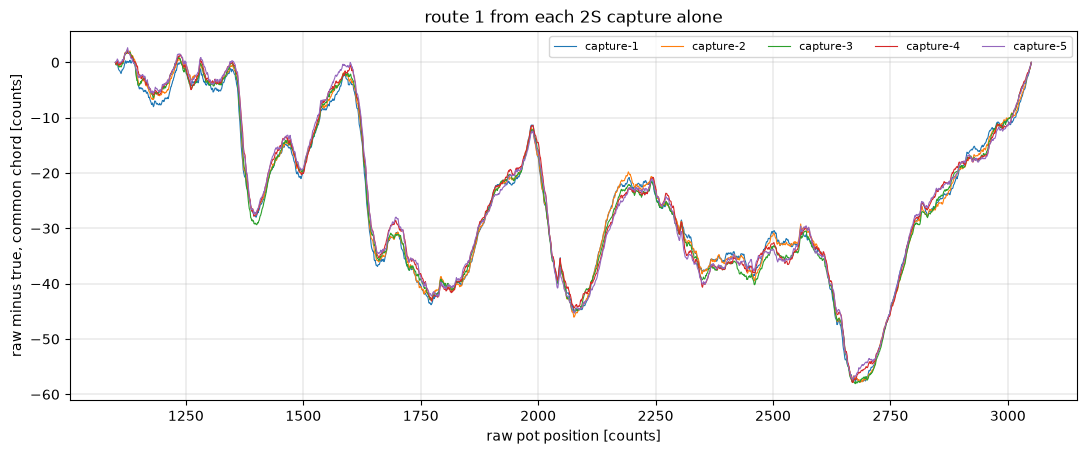

,builds,"sd, mean [counts]","sd, max [counts]","range, max [counts]"
set,,,,
"2S session, capture to capture, route 1",5,0.81,2.09,5.31
"2S session, capture to capture, route 2",5,0.89,2.08,5.12
"2S ends, capture to capture, route 1",5,0.99,3.78,9.33
"2S session, duty bands 15-25/30-40/45-50/55-100, fwd",4,1.18,3.08,6.77
"2S session, duty bands 15-25/30-40/45-50/55-100, rev",4,0.59,2.26,5.03


In [21]:
fig, ax = plt.subplots(figsize=(13, 4.8))
caps = sorted({r["cap"] for r in S2})
for c, sh in zip(caps, P1):
    ax.plot(xc, -sh, lw=0.8, label=c)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("raw minus true, common chord [counts]")
ax.set_title("route 1 from each 2S capture alone")
ax.legend(fontsize=8, ncol=5)
ax.grid(True, lw=0.3)
plt.show()

def spread_row(label, M):
    sd = M.std(0, ddof=1)
    return {"set": label, "builds": len(M), "sd, mean [counts]": sd.mean(), "sd, max [counts]": sd.max(),
            "range, max [counts]": np.ptp(M, axis=0).max()}

def band_shape(rs, lo, hi, sgn=None):
    sel = lambda r: core(r, lo, hi) and (sgn is None or np.sign(r["duty"]) == sgn)
    s = poslut.stitch(chunks(rs, "cyc", sel), RAW_MIN, RAW_MAX)
    return shape(s) if s is not None and s.lo <= A and s.hi >= B else None

rows = [spread_row("2S session, capture to capture, route 1", P1),
        spread_row("2S session, capture to capture, route 2", P2)]
# the ends capture on its own, five captures of 15 and 20% rungs both ways, hours later
PE = np.array([shape(poslut.stitch(chunks(E, "cyc", lambda r, c=c: core(r) and r["cap"] == c), RAW_MIN, RAW_MAX))
               for c in caps_e])
rows.append(spread_row("2S ends, capture to capture, route 1", PE))
# duty bands, one direction at a time so every band covers the same stretch
for sgn, lab in ((1, "fwd"), (-1, "rev")):
    Mb = [band_shape(S2, lo, hi, sgn) for lo, hi in ((15, 25), (30, 40), (45, 50), (55, 100))]
    rows.append(spread_row(f"2S session, duty bands 15-25/30-40/45-50/55-100, {lab}", np.array([m for m in Mb if m is not None])))
pd.DataFrame(rows).set_index("set").round(2)

**What you are looking at.** The route-1 shape from each 2S capture alone, against the common
chord.

The five captures overlay. Capture to capture the shape moves 0.8 counts (sd, averaged over
the interval), 2.1 counts at worst. Route 2 repeats the same way. The duty bands agree to about
1 count sd, 3 counts at worst, including the 55-100% rungs, whose ripple line runs at 2.8 to 4.5 kHz
against 0.65 to 2.6 kHz in the core band. The ends capture repeats within itself about as well,
1.0 count sd on average and 3.8 at worst, from only four rungs per capture.

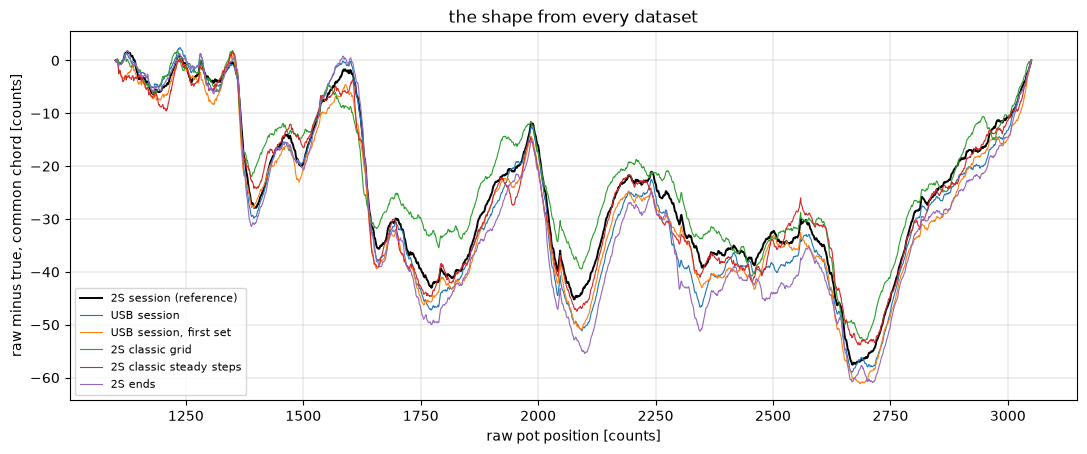

2S ends, each capture alone against the 2S session, rms / max [counts]: {'capture-1': (np.float64(3.19), np.float64(12.5)), 'capture-2': (np.float64(3.66), np.float64(14.3)), 'capture-3': (np.float64(3.42), np.float64(14.1)), 'capture-4': (np.float64(3.78), np.float64(15.3)), 'capture-5': (np.float64(3.72), np.float64(15.3))}


,rungs,rms vs 2S session [counts],max |.| [counts],covered,"cycles per count, A..B","2S session, A..B",corr with the 2S ends difference
set,,,,,,,
USB session,70,2.303,8.953,556 .. 3493,0.268,0.268,0.947
"USB session, first set",70,1.520,6.879,558 .. 3513,0.267,0.268,0.296
2S classic grid,160,3.270,10.188,539 .. 3527,0.266,0.268,-0.420
2S classic steady steps,20,2.378,6.485,539 .. 3524,0.268,0.268,0.085
2S ends,20,3.516,13.979,542 .. 3525,0.268,0.268,1.000


In [22]:
# The same shape from every other dataset, against the 2S session. USB is a check
# of direction only, and the classic set was captured a day earlier on older timing.
ref = shape(st1)
rows, diffs = [], {}
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(xc, -ref, color="k", lw=1.4, label="2S session (reference)")
for name, rs in rungs.items():
    if name == "2S session":
        continue
    s = poslut.stitch(chunks(rs), RAW_MIN, RAW_MAX)
    if s is None or s.lo > A or s.hi < B:
        rows.append({"set": name, "rungs": sum(core(r) for r in rs), "note": "does not cover the common interval"})
        continue
    d = shape(s) - ref
    diffs[name] = d
    ax.plot(xc, -shape(s), lw=0.8, label=name)
    rows.append({"set": name, "rungs": sum(core(r) for r in rs), "rms vs 2S session [counts]": np.std(d),
                 "max |.| [counts]": np.abs(d).max(), "covered": f"{s.lo} .. {s.hi}",
                 # ripple cycles per raw count over the common interval, a mechanical number
                 "cycles per count, A..B": (s.angle(B) - s.angle(A)) / (B - A),
                 "2S session, A..B": (st1.angle(B) - st1.angle(A)) / (B - A)})
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("raw minus true, common chord [counts]")
ax.set_title("the shape from every dataset")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()
t39 = pd.DataFrame(rows).set_index("set")
# Does a set differ from the session the same way the ends capture does? A correlation
# near 1 means the same pattern, whatever its size.
t39["corr with the 2S ends difference"] = [np.corrcoef(diffs[n], diffs["2S ends"])[0, 1] if n in diffs else np.nan
                                           for n in t39.index]
print("2S ends, each capture alone against the 2S session, rms / max [counts]:",
      {c: (round(np.std(sh - ref), 2), round(np.abs(sh - ref).max(), 1)) for c, sh in zip(caps_e, PE)})
t39.round(3)

**What you are looking at.** The shape from every other dataset against the 2S session, same
chord.

The USB sets agree with 2S to 1.5 to 2.3 counts rms, 7 to 9 at worst. The coupling over the
common interval is the same to within 0.8% on every set (0.266 to 0.268 cycles per count), which
is a mechanical number and should not care about the supply. The older classic grid is the
furthest off, 3.3 rms and 10 counts at worst. It was captured a day earlier on the same servo,
and I have no data yet that says whether the pot changed overnight, the rig was reassembled, or
something in the older capture timing differs. It is listed as open.

Anchored on their own well-covered ends (section 3 plot), the USB tables sit up to 8 and 15
counts above the 2S table in a broad hump through the middle. That is larger than the 2S
capture-to-capture scatter, so it is not noise. It is listed as open. The supply policy keeps
USB out of the table either way.

The ends capture is the newest set and the furthest off, 3.5 counts rms and 14 at worst, even
though it is 2S like the session and repeats within itself to 1.0 count. Each of its five
captures is off by about the same (3.2 to 3.8 rms, creeping up a little with capture order), so
it is not one bad capture. The difference is sharp and locked to position. In the plot, the
valleys near 1750, 2100 and 2350 read deeper. The USB session, recorded between the two (going
by the firmware commit each recording names), differs from the 2S session in the same pattern,
correlation 0.95, at about 60% of the size. The USB set from the day before does not (0.30),
and neither does the classic grid (-0.42). The coupling over the common interval is 0.268 cycles
per count on every set, so whatever moved is local and not a change of scale.

That changes what the USB hump most likely is. The ends capture is on 2S, so a supply effect
cannot make it, and the size of the difference grows in the order the three sets were recorded
that day. The simplest reading is that the servo itself changed over those hours of running and
the USB session caught it partway. That is a story until a capture tests it, and it is listed
at the bottom.

The last repeatability check is the gear itself. `ident/src/slip.rs` splits a constant-duty run
into ten equal pieces, drops the two at the rails, and compares counts per motor revolution
across the rest. A slipping or stripped mesh makes one piece collapse. It flags a run above a
coefficient of variation of 0.20 or with any piece under 40% of the median. It runs here on every
accepted rung of every set, once on raw counts, as the firmware tool would today, and once on
linearized counts.

In [23]:
# slip.rs on every accepted rung, first on raw counts as the firmware tool would,
# then on linearized counts.
rows = []
for name, rs in rungs.items():
    for r in rs:
        if not r["ok"]:
            continue
        p, ph = r["pos"][r["n0"]:], r["cyc"][r["n0"]:] / 6.0      # the metric is order independent
        for how, pp in (("raw", p), ("linearized", LUT.counts(p))):
            m = poslut.slip_metrics(pp, ph)
            if m:
                rows.append({"set": name, "counts": how, **m})
slip = pd.DataFrame(rows)
slip.groupby(["set", "counts"]).agg(runs=("slip_cov", "size"), cov_median=("slip_cov", "median"),
                                    cov_max=("slip_cov", "max"), min_over_median=("min_over_median", "min"),
                                    stuck=("stuck_count", "sum"), flagged=("flagged", "sum")).round(3)

runs  cov_median  cov_max  min_over_median  stuck  flagged
set                     counts                                                                
2S classic grid         linearized   269       0.027    0.051            0.903      0        0
                        raw          269       0.060    0.092            0.859      0        0
2S classic steady steps linearized    24       0.031    0.061            0.871      0        0
                        raw           24       0.096    0.116            0.780      0        0
2S ends                 linearized    20       0.030    0.048            0.909      0        0
                        raw           20       0.075    0.102            0.790      0        0
2S session              linearized   134       0.023    0.040            0.924      0        0
                        raw          134       0.073    0.094            0.796      0        0
USB session             linearized   156       0.024    0.042            0.917      0        0
                        raw          156       0.077    0.105            0.791      0        0
USB session, first set  linearized   156       0.023    0.050            0.892      0        0
                        raw          156       0.060    0.094            0.845      0        0

Nothing slips. No run is flagged and no piece is stuck, in any set, the ends capture included. The metric itself is worth a
look, though. On raw counts its median is 0.06 to 0.10, and almost all of that is the pot's own
nonlinearity. Linearized, it drops to 0.02 to 0.03. So a linearized pot makes the slip check about
three times more sensitive for free, which is worth carrying into `osc`.

## 6. The 55-knot table

The firmware block holds 55 corrections, one every 67.4 counts. The questions are how much of the
error that leaves, what a finer table would buy, and whether the fine texture under a knot interval
matters for position.

The next table fits 28 to 433 knots to the same dense curve and measures what is left, in counts
of position and in percent of local sensitivity.

First the ends capture goes into the table. Section 3 showed route 1 holds at the ends and
route 2 backs it there once its $R$ is right, so there is no reason to leave 20 more rungs out.
They go in the same way as every session rung, route 1 over whole rungs, trimmed to the stretch
at least 20 rungs cover. From this cell on, `st1`, `LUT`, `x` and `lin` are the folded build.
The session-only build stays as `st1_session` and `LUT_session`.

Section 5 also showed the ends capture differs from the session in mid travel by up to 14
counts. So the fold is a blend of two states of the same pot, and the held-out table under the
cell checks which build serves which capture.

In [24]:
# Fold the ends capture into the table. Route 1 only, whole rungs from the first tracked
# sample like every session rung, and the same rule for the covered stretch (at least 20
# rungs). The session-only build is kept under its own name for comparison.
st1_session, LUT_session = st1, LUT
FOLD = S2 + E
BAND = None
st_fold_all = poslut.stitch(chunks(FOLD), RAW_MIN, RAW_MAX)
well = np.flatnonzero(st_fold_all.chunks >= 20) + RAW_MIN
BAND = (int(well.min()), int(well.max()))
st1 = poslut.stitch(chunks(FOLD), RAW_MIN, RAW_MAX)      # from here on the table is the folded one
LUT = poslut.from_stitch(st1, RAW_MIN, RAW_MAX)
corr = np.array(LUT.corr)
LO, HI = st1.lo, st1.hi
x = np.arange(LO, HI + 1)
lin = poslut.true_counts(st1, x)
C_LIN = (st1.cum[st1.lc] - st1.cum[st1.fc]) / (HI - LO)

kch = corr - np.array(LUT_session.corr)
print(f"covered {LO}..{HI} (session alone {st1_session.lo}..{st1_session.hi}), {sum(core(r) for r in FOLD)} rungs")
print("knot change, folded minus session:", list(kch))
print(f"max |change| {np.abs(kch).max()} counts at raw {LUT.points[np.abs(kch).argmax()]:.0f}; "
      f"below {A}: {np.abs(kch[LUT.points < A]).max()}, above {B}: {np.abs(kch[LUT.points > B]).max()}")

# Which build serves which capture? Leave one capture out (both captures' capture-N),
# build from the rest, score the held-out rungs' position error as section 7 does.
def held_out_rms(test, L):
    out = []
    for r in test:
        if r["ok"]:
            n0 = r["n0"] + 400
            p, cyc = r["pos"][n0:], r["cyc"][n0:]
            y = L.counts(p)
            k_, a_ = np.polyfit(cyc, y, 1)
            out.append((y - (a_ + k_ * cyc)).std())
    return np.mean(out)

rows = []
for c in caps_e:
    builds = {"session only": [r for r in S2 if r["cap"] != c], "ends only": [r for r in E if r["cap"] != c],
              "folded": [r for r in FOLD if r["cap"] != c]}
    for test_name, test in (("2S session", [r for r in S2 if r["cap"] == c]), ("2S ends", [r for r in E if r["cap"] == c])):
        row = {"held out": test_name, "cap": c}
        for bname, train in builds.items():
            row[bname] = held_out_rms(test, poslut.from_stitch(poslut.stitch(chunks(train), RAW_MIN, RAW_MAX), RAW_MIN, RAW_MAX))
        rows.append(row)
print("held-out position error per rung, rms [counts], mean over five folds, 55 knots")
pd.DataFrame(rows).groupby("held out").mean(numeric_only=True).round(2)

covered 540..3526 (session alone 541..3526), 99 rungs
knot change, folded minus session: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(3), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(4), np.int64(3), np.int64(2), np.int64(4), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(3), np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
max |change| 4 counts at raw 2299; below 1100: 1, above 3050: 3


held-out position error per rung, rms [counts], mean over five folds, 55 knots


,session only,ends only,folded
held out,,,
2S ends,5.85,5.51,5.64
2S session,4.55,5.81,4.66


The fold barely moves the table. The largest change is 4 counts at a knot near raw 2300, in mid
travel where the two recordings differ, and at most 1 below 1100 and 3 above 3050, where the ends
capture was meant to help. That fits section 3. Route 1 at the ends was already right, and the
ends capture confirms it rather than correcting it. The covered range grows by one count, to 540
to 3526.

Held out, each build serves its own recording best, as it should when the two differ. The folded
table costs the session 0.1 counts (4.55 to 4.66) and gains the ends capture 0.2 (5.85 to 5.64).
Neither is big next to the 3.7 counts that 55 knots leave anyway, so I take the folded table. If
the servo really drifts like this, a table measured once carries a few counts of error from that
alone, which is a question for the drift item at the bottom and not for the table.

In [25]:
# How much a 55-knot table leaves behind, against the dense curve it was fitted to,
# and what a finer table would buy. Position error in counts, sensitivity error in %.
rows = []
for n in (28, 55, 109, 217, 433):
    L = poslut.from_stitch(st1, RAW_MIN, RAW_MAX, n_points=n)
    e = L.counts(x) - lin
    _, s_tab = sensitivity(x, L.counts(x), 25)
    _, s_den = sensitivity(x, lin, 25)
    rows.append({"knots": n, "spacing [counts]": (RAW_MAX - RAW_MIN) / (n - 1), "firmware bytes": 2 * n,
                 "position error rms [counts]": e.std(), "max [counts]": np.abs(e).max(),
                 "25-count sensitivity error rms [%]": np.std(s_tab / s_den - 1) * 100})
rows.append({"knots": "identity", "spacing [counts]": np.nan, "firmware bytes": 0,
             "position error rms [counts]": (x - lin).std(), "max [counts]": np.abs(x - lin).max(),
             "25-count sensitivity error rms [%]": np.std(1 / sensitivity(x, lin, 25)[1] - 1) * 100})
pd.DataFrame(rows).set_index("knots").round(2)

,spacing [counts],firmware bytes,position error rms [counts],max [counts],25-count sensitivity error rms [%]
knots,,,,,
28,134.81,56,5.14,13.83,17.75
55,67.41,110,3.65,15.85,14.96
109,33.70,218,1.38,7.31,7.72
217,16.85,434,0.71,7.14,4.16
433,8.43,866,0.43,6.14,2.32
identity,NaN,0,28.26,74.48,22.13


For **position**, 55 knots cut the error from 28.3 counts rms to 3.7 (74.5 to 15.9 at worst). The
leftover is the texture between knots. Going to 217 knots would take it to 0.7.

For **sensitivity**, and so for speed, the picture is different. Identity leaves 22.1% rms in
25-count windows and 55 knots still leave 15.0%. A good share of the pot's texture is narrower than
67 counts and a straight line between knots simply cannot follow it. 109 knots halve that and 217
knots get it to 4.2%. At two bytes a knot, 217 knots are 434 bytes.

At the very finest scale, one raw count, the density says how much true travel each ADC code
spans. An average code is 1.

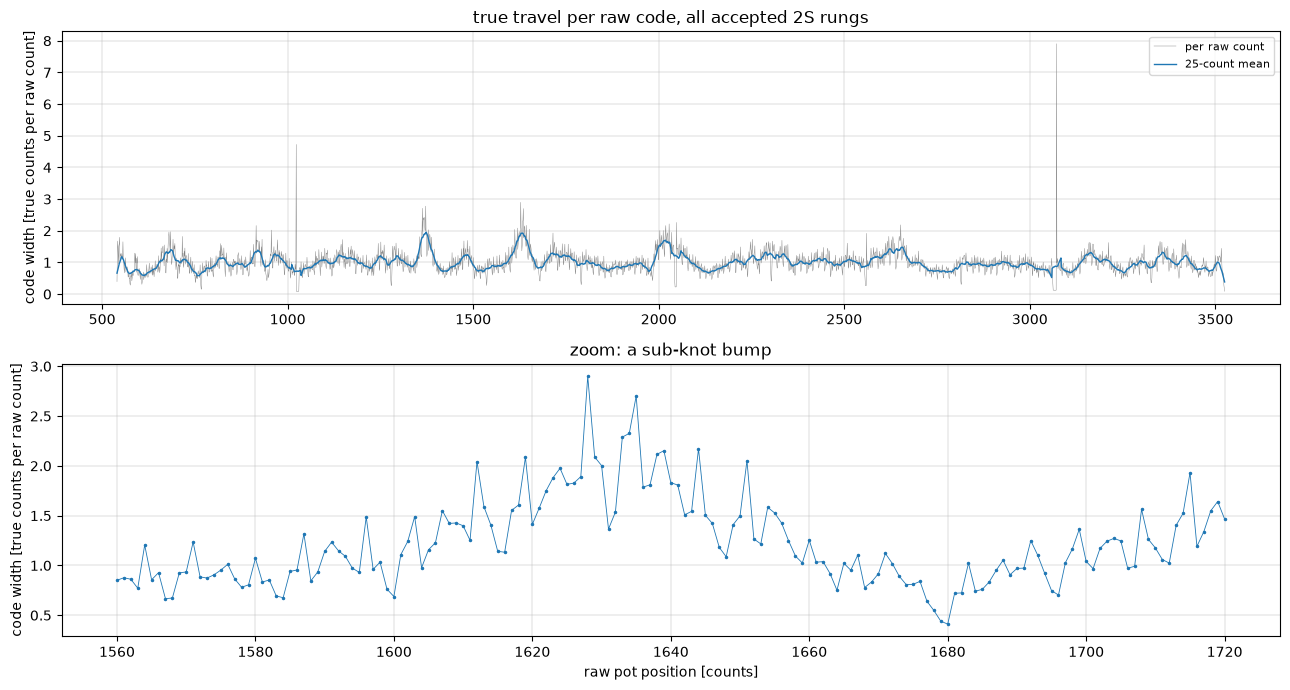

widest codes (raw count: width in average codes): {3072: 7.91, 1023: 4.73, 1628: 2.9, 1372: 2.78, 1363: 2.71, 1635: 2.7}


In [26]:
# The finest scale there is: ripple cycles deposited per single raw count, pooled.
dens = st1.density[st1.fc:st1.lc] / C_LIN          # 1 = an average-width code
xx = np.arange(st1.fc, st1.lc) + RAW_MIN
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
ax = axes[0]
ax.plot(xx, dens, lw=0.3, color="0.5", label="per raw count")
ax.plot(xx, np.convolve(dens, np.ones(25) / 25, "same"), lw=1, color="tab:blue", label="25-count mean")
ax.set_ylabel("code width [true counts per raw count]")
ax.set_title("true travel per raw code, all accepted 2S rungs")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
z = (xx >= 1560) & (xx <= 1720)
ax.plot(xx[z], dens[z], ".-", lw=0.6, ms=3)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("code width [true counts per raw count]")
ax.set_title("zoom: a sub-knot bump")
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()
wide = pd.Series(dens, index=xx).nlargest(6)
print("widest codes (raw count: width in average codes):", {int(k): round(v, 2) for k, v in wide.items()})

**What you are looking at.** Top, true travel per raw code across the covered range, per code in
grey and a 25-count mean in blue. Bottom, a zoom on one bump.

Two separate things live here. The spikes are single codes, 3072 at 7.9 codes wide and 1023 at 4.7,
at the converter's major bit transitions. That is the ADC's differential nonlinearity, not the pot.
A wide code is a dead band, the reading simply sits there for about eight codes of travel, and no
correction table can split it. Near those two codes position is only good to about plus or minus 4
counts whatever the table does.

The bumps are the pot. They are 20 to 50 counts wide, the one in the zoom near 1630 is about 40, and
they are what drives the sensitivity numbers above.

Does the texture matter for position? The 55-knot table leaves 3.7 counts rms and about 16 counts at
worst against the dense curve. The pot's rest noise is 1.2 counts and the backlash about 6. So for
position, 55 knots are adequate, the worst case is a sub-knot bump of the kind in the zoom. For speed
the texture matters a lot, and section 8 is where that decides something.

The 55-knot table in the form `ident/src/lut.rs` takes it. The same numbers are written to
`captures/mg90/pot-lut-mg90-a.json` in the bringup repo. It is not the table the firmware
applies. That one is on a fixed grid, next.

In [27]:
print(LUT.to_json(dataset=ds.key, rungs=int(sum(core(r) for r in FOLD)), covered=[int(LO), int(HI)],
                  source="notebooks/09-pot-linearization.ipynb, route 1 (ripple), 2S session 15-50% rungs "
                         "and 2S ends 15-20% rungs, both directions"))

{
  "raw_min": 209,
  "raw_max": 3849,
  "lut_corr": [
    0,
    0,
    0,
    0,
    0,
    2,
    -11,
    -15,
    -11,
    -27,
    -28,
    -24,
    -21,
    -32,
    -27,
    -26,
    -24,
    -23,
    1,
    -1,
    -12,
    -3,
    18,
    31,
    31,
    20,
    15,
    33,
    44,
    28,
    27,
    38,
    46,
    46,
    46,
    45,
    62,
    74,
    59,
    48,
    43,
    39,
    30,
    17,
    20,
    18,
    11,
    14,
    16,
    4,
    0,
    0,
    0,
    0,
    0
  ],
  "dataset": "mg90-a__2s",
  "rungs": 99,
  "covered": [
    540,
    3526
  ],
  "source": "notebooks/09-pot-linearization.ipynb, route 1 (ripple), 2S session 15-50% rungs and 2S ends 15-20% rungs, both directions"
}


### The 16-count grid

The table the firmware applies is not the 55-knot one. It sits on a fixed grid over the whole
12-bit ADC domain: 256 intervals of 16 raw counts, 257 signed 16-bit knots at raw $16k$, the
last one fixed at zero. Per pot sample the firmware takes `raw >> 4` as the interval, `raw & 15`
as the fraction, and computes

$$\text{pos}_{Q4} = \big((\text{raw} + c_k) \ll 4\big) + (c_{k+1} - c_k)\,(\text{raw} \,\&\, 15)$$

in integer math, one multiply and no divide. The result is linearized counts times 16, a Q4 word
that fits a `u16`. An all-zero table gives exactly `raw << 4`, and at a knot the result is exactly
`raw + c[k]`. `oscnb.potlut.interp_q4` is that expression bit for bit, and `GridLut.q4` runs it
over a table, which is what a capture of the firmware's own linearized position gets checked
against in section 11.

Two rules decide which knots are written.

- **Anchor on coverage, not on the extreme sample.** Knots inside the stretch at least 20 rungs
  cross carry the chord through that stretch's ends, the same gauge as the dense curve above.
  Every other knot is zero. Section 1 trimmed the covered range to that stretch so the table's ends
  never rest on one stray rung, and the cell below puts a number on what that is worth.
- **Identity outside the stops, by construction.** The firmware refuses a table with a nonzero
  knot at or below the stop interval, so `raw_min` and `raw_max` map to themselves exactly and
  the insets stay uncorrected. Beyond that it only checks physics: every interval's slope must be
  positive and under 16 times nominal, which no real pot approaches (this one peaks at 1.53 in
  25-count windows and about 2 over the ADC's wide code, the SG90 at about 6) and only garbage trips. `potlut.validate` is that check.

The spacing is 16 counts, four times finer than the 55 knots, so the 217-knot row of the knot
sweep above is the number to expect.

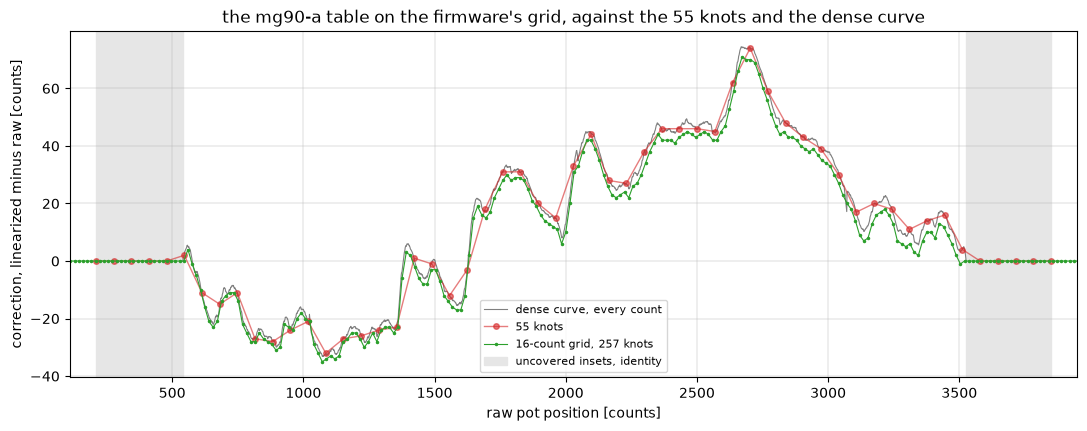

185 nonzero knots, raw 560 .. 3504; max |c| 71 counts at raw 2672; steepest interval 2.06 x nominal, shallowest 0.50 x
anchored on 542..3520 (>= 20 rungs); on the cut stitch's ends 540..3526 instead the knots differ by up to 4 counts, the dense curves by 4.17
anchored on the extreme samples 493..3552 instead of the 20-rung band: knots move by up to 18 counts, 6.0 on average


,position error rms [counts],max [counts],25-count sensitivity error rms [%]
table,,,
55 knots,3.65,15.85,14.96
16-count grid,0.66,6.71,4.09
217 knots,0.71,7.14,4.16


In [28]:
# The firmware table: knots on the 16-count grid, anchored on the stretch at least 20
# rungs cross, zero everywhere else. GRID_LUT.q4 is the firmware's integer math.
# The builder's route: the untrimmed stitch, anchored by the rule itself. BAND is that
# stretch; st1's ends (LO, HI) sit a few counts further out, where rungs cut at the
# band edge still spill a jittering sample, which is where the 55 knots anchor.
assert poslut.well_covered(st_fold_all) == BAND
GRID_LUT = poslut.fit_grid(st_fold_all)
gc = GRID_LUT.corr
lin_g = poslut.true_counts(st_fold_all, x, *BAND)          # the dense curve in the grid's own gauge
# what the firmware checks on commit, against the session's stops and against today's
# low stop (moved after the stall, see the registry)
LOW_STOP_NOW = int(servo.measured["low_stop_after_stall_measured"].value)
for lo_, hi_ in ((RAW_MIN, RAW_MAX), (LOW_STOP_NOW, RAW_MAX)):
    assert GRID_LUT.validate(lo_, hi_) is None, (lo_, hi_, GRID_LUT.validate(lo_, hi_))
# the arithmetic: all-zero is raw << 4 on every code, knots land on raw + c exactly, stops map to themselves
every = np.arange(1 << poslut.ADC_BITS)
assert (poslut.GridLut.identity().q4(every) == every << poslut.GRID_SHIFT).all()
assert (GRID_LUT.q4(GRID_LUT.raw[:-1]) == (GRID_LUT.raw[:-1] + gc[:-1]) << poslut.GRID_SHIFT).all()
assert GRID_LUT.counts(RAW_MIN) == RAW_MIN and GRID_LUT.counts(RAW_MAX) == RAW_MAX

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(x, lin - x, lw=0.8, color="0.5", label="dense curve, every count")
ax.plot(LUT.points, corr, "o-", ms=4, lw=1.0, color="tab:red", alpha=0.6, label="55 knots")
ax.plot(GRID_LUT.raw, gc, ".-", ms=3, lw=0.8, color="tab:green", label="16-count grid, 257 knots")
ax.axvspan(RAW_MIN, LO, color="0.9")
ax.axvspan(HI, RAW_MAX, color="0.9", label="uncovered insets, identity")
ax.set_xlim(RAW_MIN - 100, RAW_MAX + 100)
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("correction, linearized minus raw [counts]")
ax.set_title("the mg90-a table on the firmware's grid, against the 55 knots and the dense curve")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.show()

nz = np.flatnonzero(gc)
print(f"{len(nz)} nonzero knots, raw {GRID_LUT.raw[nz[0]]} .. {GRID_LUT.raw[nz[-1]]}; "
      f"max |c| {np.abs(gc).max()} counts at raw {GRID_LUT.raw[np.abs(gc).argmax()]}; "
      f"steepest interval {(poslut.GRID + np.diff(gc)).max() / poslut.GRID:.2f} x nominal, "
      f"shallowest {(poslut.GRID + np.diff(gc)).min() / poslut.GRID:.2f} x")
# the same table anchored where the 55 knots are, the cut stitch's own ends
g_cut = poslut.fit_grid(st1, band=(LO, HI))
print(f"anchored on {BAND[0]}..{BAND[1]} (>= 20 rungs); on the cut stitch's ends {LO}..{HI} instead the knots differ by up to "
      f"{np.abs(g_cut.corr - gc).max()} counts, the dense curves by {np.abs(lin_g - lin).max():.2f}")
# the anchor rule, quantified: the same stitch anchored on its outermost samples instead
g_ext = poslut.fit_grid(st_fold_all, band=(st_fold_all.lo, st_fold_all.hi))
print(f"anchored on the extreme samples {st_fold_all.lo}..{st_fold_all.hi} instead of the 20-rung band: "
      f"knots move by up to {np.abs(g_ext.corr - gc).max()} counts, {np.abs(g_ext.corr - gc).mean():.1f} on average")

# against the dense curve it was fitted to, beside the knot sweep's rows
rows = []
for name, fn, truth in (("55 knots", LUT.counts, lin), ("16-count grid", GRID_LUT.counts, lin_g),
                        ("217 knots", poslut.from_stitch(st1, RAW_MIN, RAW_MAX, n_points=217).counts, lin)):
    e = fn(x) - truth
    _, s_tab = sensitivity(x, fn(x), 25)
    _, s_den = sensitivity(x, truth, 25)
    rows.append({"table": name, "position error rms [counts]": e.std(), "max [counts]": np.abs(e).max(),
                 "25-count sensitivity error rms [%]": np.std(s_tab / s_den - 1) * 100})
pd.DataFrame(rows).set_index("table").round(2)

**What you are looking at.** The dense curve in grey, the 55 knots in red and the grid's 257 knots
in green, with the identity insets shaded. Under it, the table's shape, what the anchoring does,
and the fit against the dense curve beside the 55- and 217-knot rows of the sweep above.

The grid follows the dense curve as well as the 217-knot table it was expected to match: 0.66
counts rms and 6.7 at worst against 0.71 and 7.1, and 4.1% of the 25-count sensitivity against
4.2%. The 55 knots leave 3.65 counts and 15.0%. Of the 257 knots 185 are nonzero, from raw 560
to 3504, and the largest correction is 71 counts near raw 2672. The steepest 16-count interval is
2.06 times nominal, which is the eight-code-wide ADC code at 3072 (section 6) and not the pot, and
the shallowest is 0.50. Both sit far inside the 16x bound the firmware checks, which is what that
bound is for: it catches garbage and judges nothing else.

The anchoring matters. The stretch at least 20 rungs
cross is 542 to 3520. The 55 knots anchor on 540 and 3526, the ends of the stitch after the cut,
where a rung cut at the band edge still spills a jittering sample or two. The same grid anchored
there differs by up to 4 counts at a knot, and its dense curve by 4 counts near the ends. Anchored
on the outermost samples of all, 493 and 3552, the knots move by up to 18 counts and 6 on
average. So the grid anchors on the 20-rung band and nothing else, and that is the rule `osc`
carries. The table passes the firmware's check against the session's stops, 209 and 3849, and
against today's low stop at 232, since the first nonzero knot sits at 560 either way.

The table in the form `osc lut write` takes it: the 256 stored knots (the fixed last one left
out), the stops it was built against, and where it came from. The same text is written to
`captures/mg90/pot-lut-mg90-a-grid.json` in the bringup repo.

In [29]:
print(GRID_LUT.to_json(RAW_MIN, RAW_MAX, dataset=ds.key, rungs=int(sum(core(r) for r in FOLD)), covered=list(BAND),
                       source="notebooks/09-pot-linearization.ipynb, route 1 (ripple), 2S session 15-50% rungs "
                              "and 2S ends 15-20% rungs, both directions, knots on the stretch >= 20 rungs cross"))

{
  "raw_min": 209,
  "raw_max": 3849,
  "grid_shift": 4,
  "knots": [
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    4,
    -1,
    -5,
    -10,
    -16,
    -21,
    -23,
    -21,
    -14,
    -12,
    -11,
    -11,
    -14,
    -22,
    -25,
    -28,
    -28,
    -25,
    -27,
    -28,
    -29,
    -31,
    -30,
    -22,
    -23,
    -24,
    -20,
    -18,
    -20,
    -21,
    -29,
    -32,
    -35,
    -34,
    -33,
    -34,
    -33,
    -28,
    -27,
    -25,
    -25,
    -27,
    -30,
    -28,
    -25,
    -28,
    -24,
    -23,
    -23,
    -25,
    -23,
    -6,
    3,
    2,
    -2,
    -6,
    -8,
    -8,
    -3,
    -3,
    -7,
    -12,
    -14,
    -16,
    -17,
    -17,
    -12,
    2,
    15,
    19,
    16,
    15,
    17,
    22,
    25,
    28,
    30,
    28,
    29,
  

## 7. Before and after on held-out captures

A table fitted and scored on the same rungs flatters itself. Here each 2S capture takes a turn as the
test set while the table is built from the other four, the session's and the ends capture's capture-N
both left out together. The tables built from all ten 2S captures are also scored on the two USB
sessions and the classic grid, none of which went into them.

On each held-out rung the truth is the rung's own ripple angle, with an offset and a scale fitted per
rung, so only shape counts. Speed is the pot differenced over a window of $W$ samples,

$$\hat v_{pot}[k] = \frac{\theta[k] - \theta[k - W]}{W\,T_s}$$

scored against the ripple over the same window, in percent of the rung's mean speed.

In [30]:
# Leave one capture out: build from four 2S captures, test on the fifth, rotate.
# The grid table is anchored on the training stitch's own ends here, like the 55
# knots, so the rows differ only by table resolution.
# The session and the ends capture share capture names only (they were recorded hours
# apart), and each fold leaves both capture-N out, so no test rung is in its table.
# Truth on a held-out rung is its own ripple angle, with an offset and a scale fitted
# per rung (the chord gauge), so the error is shape only.
M0 = 400              # 20 ms after the first tracked sample
WINDOWS = (20, 80, 160, 400)   # 1, 4, 8, 20 ms

def evaluate(test, maps, label):
    pos_rows, spd = [], []
    for r in test:
        if not r["ok"]:
            continue
        n0 = r["n0"] + M0
        p, cyc = r["pos"][n0:], r["cyc"][n0:] * np.sign(r["duty"])
        for name, fn in maps.items():
            y = fn(p)
            k, a = np.polyfit(cyc, y, 1)            # counts per cycle and offset, this rung
            e = y - (a + k * cyc)
            pos_rows.append({"set": label, "cap": r["cap"], "duty": r["duty"], "map": name, "rms": e.std(), "max": np.abs(e).max()})
            for W in WINDOWS:
                vp = (y[W:] - y[:-W]) / (W * DT)
                vr = k * (cyc[W:] - cyc[:-W]) / (W * DT)
                spd.append(pd.DataFrame({"set": label, "duty": r["duty"], "map": name, "W": W,
                                         "at": (p[W:] + p[:-W]) / 2, "err_pct": (vp - vr) / np.abs(vr).mean() * 100,
                                         "cap": r["cap"]}))
    return pd.DataFrame(pos_rows), pd.concat(spd, ignore_index=True)

pos_ev, spd_ev = [], []
for c in caps:
    s = poslut.stitch(chunks([r for r in FOLD if r["cap"] != c]), RAW_MIN, RAW_MAX)
    L55 = poslut.from_stitch(s, RAW_MIN, RAW_MAX)
    xs = np.arange(s.lo, s.hi + 1)
    dense_c = poslut.true_counts(s, xs)
    maps = {"raw": lambda p: p.astype(float), "55 knots": L55.counts,
            "grid": poslut.fit_grid(s, band=(s.lo, s.hi)).counts,
            "217 knots": poslut.from_stitch(s, RAW_MIN, RAW_MAX, n_points=217).counts,
            "dense": lambda p, xs=xs, d=dense_c: np.interp(p, xs, d)}
    a, b = evaluate([r for r in S2 if r["cap"] == c], maps, "2S held out")
    pos_ev.append(a); spd_ev.append(b)
    a, b = evaluate([r for r in E if r["cap"] == c], maps, "2S ends held out")
    pos_ev.append(a); spd_ev.append(b)
# the full 2S table applied to the other supply and the older sets
maps_full = {"raw": lambda p: p.astype(float), "55 knots": LUT.counts, "grid": GRID_LUT.counts,
             "217 knots": poslut.from_stitch(st1, RAW_MIN, RAW_MAX, n_points=217).counts,
             "dense": lambda p: np.interp(p, x, lin)}
for name in ("USB session", "USB session, first set", "2S classic grid"):
    a, b = evaluate(rungs[name], maps_full, name)
    pos_ev.append(a); spd_ev.append(b)
pos_ev, spd_ev = pd.concat(pos_ev), pd.concat(spd_ev)
ORDER = ["raw", "55 knots", "grid", "217 knots", "dense"]
pv = pos_ev.pivot_table(index="set", columns="map", values="rms", aggfunc="mean")[ORDER]
pm = pos_ev.pivot_table(index="set", columns="map", values="max", aggfunc="median")[ORDER]
print("position error per held-out rung, rms [counts], mean over rungs")
display(pv.round(2))
print("position error per held-out rung, max |.| [counts], median over rungs")
display(pm.round(1))
print("pot speed error, rms over all held-out samples [% of rung mean speed]")
display(spd_ev.groupby(["set", "W", "map"]).err_pct.std().unstack("map")[ORDER].rename(
    index=lambda w: f"{w * DT * 1e3:g} ms" if isinstance(w, (int, np.integer)) else w, level=1).round(2))

position error per held-out rung, rms [counts], mean over rungs


map,raw,55 knots,grid,217 knots,dense
set,,,,,
2S classic grid,13.51,5.78,5.14,5.14,5.22
2S ends held out,19.54,5.64,3.76,3.76,3.67
2S held out,16.54,4.66,2.90,2.95,2.90
USB session,17.57,5.06,3.10,3.09,3.04
"USB session, first set",15.20,4.91,3.37,3.36,3.35


position error per held-out rung, max |.| [counts], median over rungs


map,raw,55 knots,grid,217 knots,dense
set,,,,,
2S classic grid,37.7,19.8,16.4,16.8,17.0
2S ends held out,50.1,21.1,15.9,15.1,15.4
2S held out,46.3,18.4,11.5,11.6,11.5
USB session,54.7,19.8,13.4,13.1,13.4
"USB session, first set",41.8,20.0,13.2,13.3,13.5


pot speed error, rms over all held-out samples [% of rung mean speed]


map                             raw  55 knots   grid  217 knots  dense
set                    W                                              
2S classic grid        1 ms   55.89     54.74  55.21      55.21  55.25
                       4 ms   22.05     19.02  16.75      16.60  17.08
                       8 ms   17.44     13.67  11.26      11.13  11.56
                       20 ms  11.85      7.59   5.97       5.94   6.12
2S ends held out       1 ms   94.78     93.45  94.70      94.64  94.46
                       4 ms   32.79     29.10  22.51      22.43  21.10
                       8 ms   27.22     22.46  14.54      14.56  13.72
                       20 ms  21.24     14.79   7.85       7.91   7.56
2S held out            1 ms   57.57     55.43  54.40      54.46  53.84
                       4 ms   24.06     19.35  12.55      12.69  11.63
                       8 ms   19.89     14.12   7.55       7.69   7.13
                       20 ms  14.35      7.95   3.64       3.74   3.53
USB session            1 ms   80.15     78.78  79.39      79.42  79.25
                       4 ms   27.26     22.99  16.30      16.52  15.39
                       8 ms   22.60     17.14  10.17      10.34   9.66
                       20 ms  16.90     10.42   5.18       5.22   4.97
USB session, first set 1 ms   82.49     81.42  82.48      82.51  82.44
                       4 ms   26.77     22.71  17.11      17.07  16.26
                       8 ms   22.02     16.90  11.12      11.02  10.66
                       20 ms  16.15      9.99   5.61       5.55   5.45

Position gets much better. On held-out session captures the rms error per rung goes from 16.5 counts
raw to 4.7 with 55 knots and 2.9 with the dense curve, and the worst sample per rung from 46 to 18 to 12.
The held-out ends captures go from 19.5 to 5.6 (3.7 dense). The USB sessions and the classic grid show the
same thing (13.5 to 17.6 raw, 4.9 to 5.8 with 55 knots), so the table carries across supply and day.

Speed gets less better. At 4 ms the pot's error goes from 24% to 19% with 55 knots, and to 12.7% with
217 knots. At 20 ms, 14.4% to 8.0% and 3.7%. At 1 ms everything is about 55% because noise dominates. The
ends captures read higher on every row (33% raw at 4 ms), because all their rungs are slow and a count
of noise is a bigger share of a slow speed.

The grid is the 217-knot row in a fixed layout, and held out it says the same. On the session
captures it takes the position error to 2.9 counts rms, the dense curve's own number, and the worst
sample per rung to 11.5. Speed at 4 ms goes from 19.4% with 55 knots to 12.6%, at 20 ms from 8.0%
to 3.6%, against 11.6% and 3.5% for the dense curve. The 1 ms rows do not move for any table,
because there the noise is everything. The other supply and the classic grid follow, 3.1 to 5.1
counts and 16 to 17% at 4 ms.

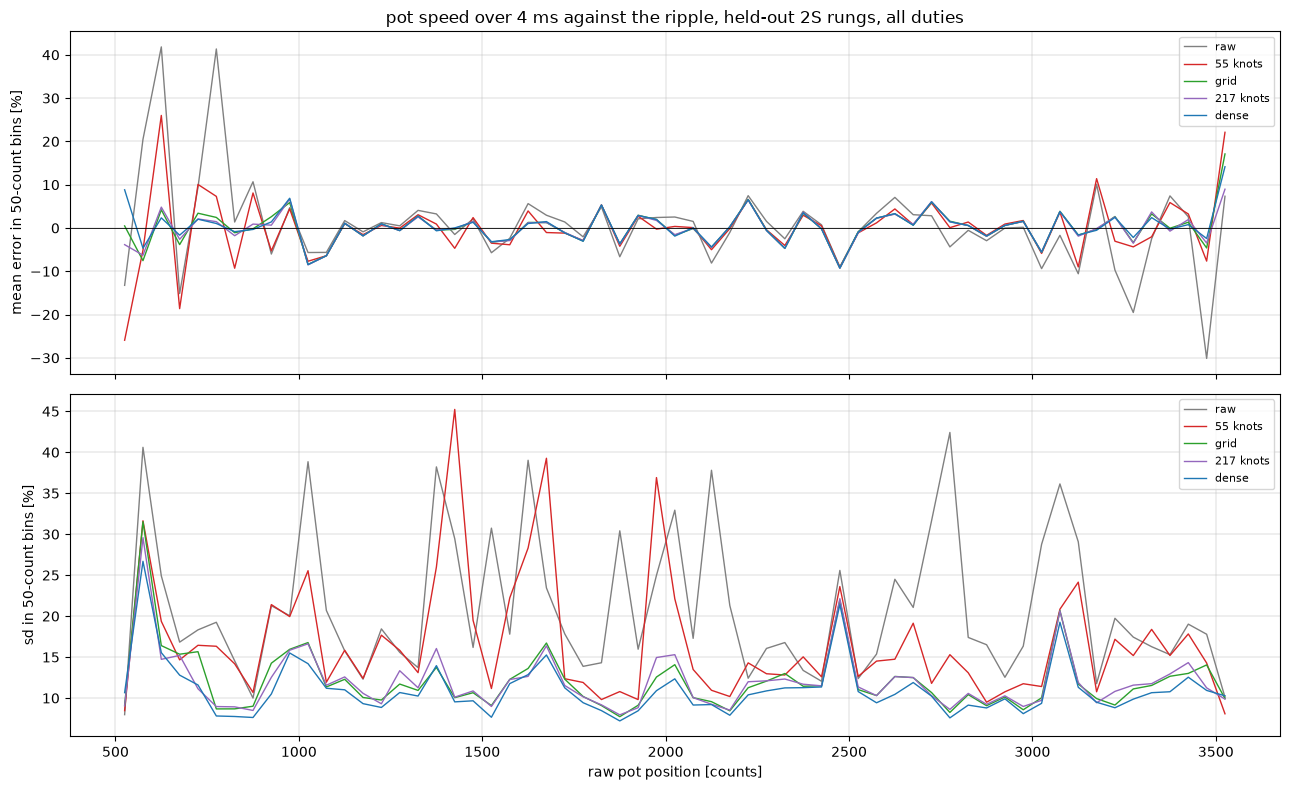

,25-count gain min,max,max over min,"position-locked part of the 4 ms error, rms [%]","the rest, rms [%]"
map,,,,,
raw,0.662,1.585,2.394,8.071,22.670
55 knots,0.741,1.341,1.810,6.414,18.253
grid,0.797,1.171,1.469,4.728,11.630
217 knots,0.797,1.110,1.394,4.725,11.773
dense,0.798,1.142,1.430,4.607,10.679


In [31]:
h = spd_ev[(spd_ev.set == "2S held out") & (spd_ev.W == 80)].copy()
h["bin"] = (h["at"] // 50) * 50 + 25
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for name, col in zip(ORDER, ["0.5", "tab:red", "tab:green", "tab:purple", "tab:blue"]):
    g = h[h["map"] == name].groupby("bin").err_pct
    axes[0].plot(g.mean().index, g.mean(), color=col, lw=1, label=name)
    axes[1].plot(g.std().index, g.std(), color=col, lw=1, label=name)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("mean error in 50-count bins [%]")
axes[0].set_title("pot speed over 4 ms against the ripple, held-out 2S rungs, all duties")
axes[1].set_ylabel("sd in 50-count bins [%]")
axes[1].set_xlabel("raw pot position [counts]")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

# Flatness of the local gain on the held-out rungs: raw or linearized counts per
# ripple cycle in 25-count windows, pooled over held-out rungs.
rows = []
for name in ORDER:
    g = h[h["map"] == name]
    b25 = (g["at"] // 25)
    m = (g.err_pct.groupby(b25).mean() / 100 + 1)
    rows.append({"map": name, "25-count gain min": m.min(), "max": m.max(), "max over min": m.max() / m.min(),
                 "position-locked part of the 4 ms error, rms [%]": g.err_pct.groupby(b25).transform("mean").std(),
                 "the rest, rms [%]": (g.err_pct - g.err_pct.groupby(b25).transform("mean")).std()})
pd.DataFrame(rows).set_index("map").round(3)

**What you are looking at.** The 4 ms pot speed error on held-out 2S rungs in 50-count bins, the mean
per bin on top and the scatter per bin below, for raw counts, 55 knots, the grid, 217 knots and the
dense curve.

In mid travel the mean error per 50-count bin is about the same for every map, because the pot's
texture is finer than 50 counts and averages out inside a bin. There linearizing mainly removes the
big excursions near the ends. The scatter panel is where the tables separate. Texture inside a bin
shows up as scatter, the dense and 217-knot curves pull it down to about 8 to 15%, and 55 knots leave
spikes of 25 to 45% wherever a sharp bump sits between two knots (near 1420, 1670 and 1990). The table
under the plot splits the 4 ms error into the part locked to 25-count bins and the rest. The locked
part falls from 8.1% to 6.4% with 55 knots and 4.6% dense. The rest, 11 to 23%, does not go away with
any table. Part of it is texture finer than 25 counts, and most of it is noise. Local gain in 25-count
windows goes from a 2.4x range raw to 1.8x with 55 knots, 1.5x on the grid and 1.4x dense.

## 8. The fusion decision

Notebook 08 put the velocity observer on model back-EMF and left the pot supplying position only,
because the pot's speed error was deterministic and 14.5% rms. The question for this notebook is
whether a linearized pot changes that.

Every candidate is evaluated the way the observer would see it, every sample at 20 kHz, on the
held-out 2S rungs, in linearized counts per second, against the ripple over the candidate's own
window. The back-EMF estimate uses a 1 ms boxcar, the one notebook 08 recommends. The pot is differenced
over 4, 8 and 20 ms, whole multiples of 4 ms so the position channel's 250 Hz comb cancels (notebook 08).
A window of $W$ samples also costs $W/2$ samples of lag, 2 ms at 4 ms and 10 ms at 20 ms.

In [32]:
# Every candidate as the observer would see it at 20 kHz, scored against the ripple
# over its own window, in linearized counts per second. Held-out 2S rungs only.
lut_of = {}
for c in caps:
    s = poslut.stitch(chunks([r for r in FOLD if r["cap"] != c]), RAW_MIN, RAW_MAX)
    lut_of[c] = (poslut.from_stitch(s, RAW_MIN, RAW_MAX), (s.cum[s.lc] - s.cum[s.fc]) / (s.hi - s.lo))

BOX = 20              # the back-EMF boxcar nb08 recommends, 1 ms

def speeds(r):
    L, c_lin = lut_of[r["cap"]]
    n0 = r["n0"] + M0
    p = r["pos"][n0:]
    cyc = r["cyc"][n0:] * np.sign(r["duty"])
    e_cyc = np.cumsum(np.r_[0, np.diff(r["cyc2"][n0:])]) * np.sign(r["duty"])   # back-EMF angle, same samples
    out = []
    for name, y, W in (("pot raw, 4 ms", p.astype(float), 80), ("pot 55 knots, 4 ms", L.counts(p), 80),
                       ("pot 55 knots, 8 ms", L.counts(p), 160), ("pot 55 knots, 20 ms", L.counts(p), 400),
                       ("back-EMF, 1 ms", e_cyc / c_lin, BOX), ("back-EMF, 4 ms", e_cyc / c_lin, 80)):
        v = (y[W:] - y[:-W]) / (W * DT)
        vr = (cyc[W:] - cyc[:-W]) / (W * DT) / c_lin
        out.append(pd.DataFrame({"est": name, "duty": r["duty"], "at": p[W:], "v_ref": vr, "err": v - vr}))
    return out

fu = pd.concat([d for r in S2 if r["ok"] for d in speeds(r)], ignore_index=True)
fu["speed band"] = pd.cut(fu.duty.abs(), [14, 25, 40, 50, 100], labels=["15-25%", "30-40%", "45-50%", "55-100%"])
fu["region"] = pd.cut(fu["at"], [0, 1100, 1800, 2500, 3200, 4096], labels=["< 1100", "1100-1800", "1800-2500", "2500-3200", "> 3200"])
fu["err_dir"] = fu.err * np.sign(fu.duty)          # positive = reads fast, either direction
by_band = fu.groupby(["speed band", "est"], observed=True).agg(
    speed_cps=("v_ref", lambda v: np.abs(v).mean()), rms_cps=("err", lambda e: np.sqrt(np.mean(e ** 2))),
    bias_cps=("err_dir", "mean"))
by_band["rms_pct"] = by_band.rms_cps / by_band.speed_cps * 100
by_band["bias_pct"] = by_band.bias_cps / by_band.speed_cps * 100
display(by_band.round(1))
print("rms error by travel region, counts per second, all speed bands up to 50% duty")
display(fu[fu.duty.abs() <= 50].groupby(["region", "est"], observed=True).err.apply(
    lambda e: np.sqrt(np.mean(e ** 2))).unstack("est").round(0))
# the back-EMF model above 50% duty, where its Ke was not fitted
hb = fu[fu.est == "back-EMF, 1 ms"].groupby(fu.duty.abs()).apply(
    lambda d: (d.err_dir.mean() / np.abs(d.v_ref).mean()) * 100, include_groups=False)
print("back-EMF bias by duty [%]:", {int(k): round(v, 1) for k, v in hb.items()})

speed_cps  rms_cps  bias_cps  rms_pct  bias_pct
speed band est                                                                 
15-25%     back-EMF, 1 ms          3292.0    106.3      38.9      3.2       1.2
           back-EMF, 4 ms          3292.4     84.2      38.6      2.6       1.2
           pot 55 knots, 20 ms     3293.1    323.0       2.3      9.8       0.1
           pot 55 knots, 4 ms      3292.4    752.6       6.8     22.9       0.2
           pot 55 knots, 8 ms      3292.8    567.7       6.0     17.2       0.2
           pot raw, 4 ms           3292.4    872.0     -34.7     26.5      -1.1
30-40%     back-EMF, 1 ms          6668.5    118.1     -44.6      1.8      -0.7
           back-EMF, 4 ms          6672.8     98.3     -45.1      1.5      -0.7
           pot 55 knots, 20 ms     6690.0    312.2       4.3      4.7       0.1
           pot 55 knots, 4 ms      6672.8   1124.7      -2.6     16.9      -0.0
           pot 55 knots, 8 ms      6678.1    773.7       1.7     11.6       0.0
           pot raw, 4 ms           6672.8   1430.5     -98.7     21.4      -1.5
45-50%     back-EMF, 1 ms          9231.7    185.0      81.8      2.0       0.9
           back-EMF, 4 ms          9240.4    141.1      81.1      1.5       0.9
           pot 55 knots, 20 ms     9273.4    322.6       1.3      3.5       0.0
           pot 55 knots, 4 ms      9240.4   1303.4       7.5     14.1       0.1
           pot 55 knots, 8 ms      9250.4    818.0       5.3      8.8       0.1
           pot raw, 4 ms           9240.4   1788.7    -132.3     19.4      -1.4
55-100%    back-EMF, 1 ms         13632.1   2788.1    2355.6     20.5      17.3
           back-EMF, 4 ms         13636.5   2777.1    2353.1     20.4      17.3
           pot 55 knots, 20 ms    13640.5    306.2       1.2      2.2       0.0
           pot 55 knots, 4 ms     13636.5   1555.2      -4.0     11.4      -0.0
           pot 55 knots, 8 ms     13641.4    780.6      -2.2      5.7      -0.0
           pot raw, 4 ms          13636.5   2388.6    -313.7     17.5      -2.3

rms error by travel region, counts per second, all speed bands up to 50% duty


est,"back-EMF, 1 ms","back-EMF, 4 ms","pot 55 knots, 20 ms","pot 55 knots, 4 ms","pot 55 knots, 8 ms","pot raw, 4 ms"
region,,,,,,
< 1100,167.0,138.0,286.0,911.0,616.0,1175.0
1100-1800,109.0,87.0,413.0,1194.0,875.0,1295.0
1800-2500,108.0,87.0,287.0,878.0,584.0,1153.0
2500-3200,121.0,88.0,244.0,745.0,499.0,1189.0
> 3200,152.0,134.0,209.0,756.0,471.0,919.0


back-EMF bias by duty [%]: {15: 1.9, 20: 1.1, 25: 0.5, 30: -0.0, 35: -0.8, 40: -1.2, 45: 0.3, 50: 1.5, 55: 4.8, 60: 6.2, 65: 9.0, 70: 12.7, 75: 15.2, 80: 17.5, 85: 19.3, 90: 21.2, 95: 25.0, 100: 28.4}


Read by speed band. From 15 to 50% duty, back-EMF over 1 ms is off by 1.8 to 3.2% rms, with a bias
of about 1%. The 55-knot pot over 4 ms is off by 14 to 23%, over 20 ms by 3.5 to 10%. So where both
exist, back-EMF wins by about nine times at the same 4 ms window, and even the 20 ms pot,
with five times the lag, is two to three times worse than 1 ms of back-EMF. By region the story is the same,
the back-EMF error sits at 110 to 170 counts per second everywhere and the pot's at 750 to 1200.

Above 50% duty it flips. The back-EMF model, with $K_e$ fitted from 15 to 50%, reads 5% fast at 55%
duty and 28% fast at 100%. That is the speed-driven excess notebook 08 found on the SG90 (11% at full
duty there) and it is bigger on this motor. The pot does not care about duty, 2.2% at 20 ms and 11%
at 4 ms.

In [33]:
# At rest the back-EMF path does not exist (duty 0, window_valid 0), so the pot is
# the only speed there is. Its noise over the baseline, after the 200 ms ring-down.
rows = []
for cap, df, meta in frames(ds, "grid"):
    p = LUT.counts(df[df.seg == 0].pos.to_numpy()[4000:])
    for W in (20, 80, 160, 400):
        rows.append({"cap": cap, "W": W, "sd": np.std((p[W:] - p[:-W]) / (W * DT))})
rest = pd.DataFrame(rows).groupby("W").sd.agg(["mean", "min", "max"])
rest.index = [f"{w * DT * 1e3:g} ms" for w in rest.index]
print("pot speed noise at rest, linearized counts per second (the true speed is zero)")
display(rest.round(0))

# Where the back-EMF path switches on: window_valid against duty over the breakaway ladder.
bw = []
for cap, df, meta in frames(ds, "breakaway"):
    for seg, g in df[df.seg > 0].groupby("seg"):
        bw.append({"duty": round(abs(g.cmd_duty_q15.iloc[0]) * 100 / Q15), "valid": g.window_valid.mean()})
bw = pd.DataFrame(bw).groupby("duty").valid.mean()
print("fraction of samples with window_valid, breakaway ladder:", {int(k): round(v, 2) for k, v in bw.items() if 10 <= k <= 18})

pot speed noise at rest, linearized counts per second (the true speed is zero)


,mean,min,max
1 ms,1501.0,1170.0,1774.0
4 ms,177.0,133.0,216.0
8 ms,88.0,66.0,108.0
20 ms,35.0,27.0,43.0


fraction of samples with window_valid, breakaway ladder: {10: 0.0, 11: 0.0, 12: 0.0, 13: 0.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0}


At rest the back-EMF path does not exist. Duty is zero, `window_valid` is clear, and there is no
winding current to read. The breakaway ladder shows the flag switching on between 13 and 14% duty, so
below that the pot is the only speed there is. At rest its noise in linearized counts per second is
about 180 over 4 ms and 35 over 20 ms.

The weights. If two estimates of the same speed have independent errors with variances
$\sigma_{pot}^2$ and $\sigma_{bemf}^2$, the best blend gives the pot a weight

$$w_{pot} = \frac{\sigma_{bemf}^2}{\sigma_{pot}^2 + \sigma_{bemf}^2}$$

I use the total measured error here, bias and scatter together, since neither is zero mean.

In [34]:
# Inverse-variance weight of the pot against the 1 ms back-EMF, per speed band, from
# the measured total error (bias and scatter together, since neither is zero mean).
tot = fu.groupby(["speed band", "est"], observed=True).err.apply(lambda e: np.sqrt(np.mean(e ** 2))).unstack("est")
rec = pd.DataFrame({"speed [counts/s]": by_band.xs("back-EMF, 1 ms", level="est").speed_cps,
                    "back-EMF 1 ms, rms [counts/s]": tot["back-EMF, 1 ms"]})
for est in ("pot raw, 4 ms", "pot 55 knots, 4 ms", "pot 55 knots, 20 ms"):
    rec[f"{est}, rms"] = tot[est]
    rec[f"w_pot, {est}"] = tot["back-EMF, 1 ms"] ** 2 / (tot[est] ** 2 + tot["back-EMF, 1 ms"] ** 2)
display(rec.round(3))
# the speed at which the pot's error would match the back-EMF's, pot error modelled
# as rest noise plus a fraction of speed
g55 = (by_band.xs("pot 55 knots, 4 ms", level="est").rms_pct / 100).median()
gb = (tot["back-EMF, 1 ms"] / rec["speed [counts/s]"]).median()
n4 = rest.loc["4 ms", "mean"]
print(f"pot 55 knots, 4 ms: rest noise {n4:.0f} counts/s plus {g55 * 100:.1f}% of speed; "
      f"back-EMF 1 ms: {gb * 100:.1f}% of speed where it exists")

,speed [counts/s],"back-EMF 1 ms, rms [counts/s]","pot raw, 4 ms, rms","w_pot, pot raw, 4 ms","pot 55 knots, 4 ms, rms","w_pot, pot 55 knots, 4 ms","pot 55 knots, 20 ms, rms","w_pot, pot 55 knots, 20 ms"
speed band,,,,,,,,
15-25%,3292.004,106.278,871.963,0.015,752.578,0.020,323.022,0.098
30-40%,6668.544,118.129,1430.486,0.007,1124.654,0.011,312.153,0.125
45-50%,9231.675,185.017,1788.705,0.011,1303.380,0.020,322.560,0.248
55-100%,13632.058,2788.134,2388.567,0.577,1555.234,0.763,306.222,0.988


pot 55 knots, 4 ms: rest noise 177 counts/s plus 15.5% of speed; back-EMF 1 ms: 2.6% of speed where it exists


**The recommendation, for notebook 08 and the observer.**

1. **Where back-EMF is valid and the duty is at most 50%, the pot stays position only.** Its weight
   against 1 ms back-EMF is 0.007 to 0.020 at 4 ms, linearized or not. Linearization moves it by
   less than a factor of two and it stays negligible. At 20 ms it would reach 0.10 to 0.25, but at
   10 ms of lag, which a velocity loop would feel, and back-EMF over 4 ms is still two to four
   times better.
2. **Below the back-EMF validity floor (`window_valid` clear, under about 14% duty on 2S) and at rest,
   the pot is the velocity source**, differenced over a whole multiple of 4 ms on linearized counts.
   Its error there is noise-dominated (about 180 counts per second over 4 ms at rest, 35 over 20 ms)
   plus about 15% of speed from texture at 4 ms. The linearization matters most here, because this is
   where the pot's speed is the only one there is.
3. **Above 50% duty the back-EMF model as it stands should not be trusted for speed.** It reads 5 to
   28% fast. Until the high-speed term is fixed (notebook 08's open item), a 20 ms linearized pot
   derivative is the better estimate up there, about 2% rms. Weight on it from these numbers, 0.76
   at 4 ms and 0.99 at 20 ms.

So the switch is by availability and by duty, not a fixed blend. In observer terms, the back-EMF
enters as a velocity measurement whenever `window_valid` is set and $|D| \le 50\%$, and the pot's
velocity innovation only has weight outside that. A finer table (217 knots) would bring the 4 ms pot
from about 19% to 13% and does not change any of these three answers.

## 9. What changes downstream

Every plant constant with a pot count in its unit was fitted in raw counts. In linearized counts the
settled windows those fits average over read slightly differently, so the constants move. I re-run
the fits of the bringup `plant.py` on the same 2S session grid twice, once in raw counts and once
through the 55-knot table, with no recapture. $K_e$ here is `ke_vpc`, back-EMF in tap counts per pot
count per second. $f_c$ and $f_v$ are the Coulomb and viscous current terms against pot speed.
$\sigma_\theta$ is the rest noise of position. The last row is the speed-per-duty slope the capture
pilot uses to size its windows.

In [35]:
# plant.py's definitions (bringup captures/mg90/plant.py), run twice over the same
# 2S session grid: once in raw counts, once in linearized counts.
r_vpc = R_OHM * board.a_per_count / board.v_term_per_count     # ohm in tap counts per current count
def plant(fn, ke_band=(20, 60)):
    ke_rows, fr_rows, sig, vss = [], [], [], []
    for cap, df, meta in frames(ds, "grid"):
        base = df[df.seg == 0]
        bias = base.current_raw.mean()
        sig.append(np.std(fn(base.pos.to_numpy()[4000:])))
        for seg, g in df[df.seg > 0].groupby("seg"):
            d = g.cmd_duty_q15.iloc[0] / Q15
            pct = abs(d) * 100
            n = len(g)
            tail = slice(int(n * 0.6), n)                              # plant.py SETTLED = 0.4
            if pct < 15 or g.window_valid.to_numpy()[tail].mean() <= 0.95:
                continue
            t = np.arange(n) * DT
            w = np.polyfit(t[tail], fn(g.pos.to_numpy()[tail]), 1)[0]  # pot slope, counts per second
            i = np.sign(d) * (g.current_raw.to_numpy()[tail] - bias).mean()
            y = abs(d) * (g.vmotor_a.to_numpy()[tail] - g.vmotor_b.to_numpy()[tail]).astype(float).mean()
            if ke_band[0] <= pct <= ke_band[1]:
                ke_rows.append((w, y - r_vpc * i))
                fr_rows.append((np.sign(d), w, i))
            if 10 <= pct <= 50:
                vss.append((np.sign(d), pct, abs(w) / 1e3))
    w, e = np.array(ke_rows).T
    out = {"ke_vpc [tap counts per count/s]": np.polyfit(w, e, 1)[0],
           "sigma_theta [counts]": np.mean(sig)}
    fr = np.array(fr_rows)
    for s, lab in ((1, "fwd"), (-1, "rev")):
        m = fr[:, 0] == s
        fv, fc = np.polyfit(fr[m, 1], fr[m, 2], 1)
        out[f"fc {lab} [current counts]"] = abs(fc)
        out[f"fv {lab} [current counts per count/s]"] = fv
    v = np.array(vss)
    m = v[:, 0] == -1                                                 # the pilot sizes windows on reverse
    out["v_ss slope, rev [counts/ms per % duty]"] = np.polyfit(v[m, 1], v[m, 2], 1)[0]
    return out

raw_p, lin_p = plant(lambda p: p.astype(float)), plant(LUT.counts)
lin_p50 = plant(LUT.counts, ke_band=(20, 50))     # Ke kept below the back-EMF over-read, section 10
dn = pd.DataFrame({"raw counts": raw_p, "linearized counts": lin_p})
dn["change [%]"] = (dn["linearized counts"] / dn["raw counts"] - 1) * 100
display(dn.round(5))

lim = pd.DataFrame({"raw": [SOFT[0], GUARD[0], GUARD[1], SOFT[1]]},
                   index=["soft low", "guard low", "guard high", "soft high"])
lim["linearized"] = LUT.counts(lim["raw"].to_numpy()).round(1)
lim["moves by [counts]"] = lim["linearized"] - lim["raw"]
display(lim)

_, s55 = sensitivity(x, LUT.counts(x), 67)
_, sraw = sensitivity(x, lin, 67)
print(f"position-loop gain across travel, 67-count windows: raw counts {sraw.min():.2f} .. {sraw.max():.2f} x nominal, "
      f"55-knot counts {(sraw / s55).min():.3f} .. {(sraw / s55).max():.3f} x nominal")

,raw counts,linearized counts,change [%]
ke_vpc [tap counts per count/s],0.14717,0.14144,-3.89347
sigma_theta [counts],1.19357,1.13508,-4.90065
fc fwd [current counts],59.17821,59.95086,1.30562
fv fwd [current counts per count/s],0.00452,0.00437,-3.33886
fc rev [current counts],45.96516,46.43372,1.01937
fv rev [current counts per count/s],0.00635,0.00589,-7.21810
"v_ss slope, rev [counts/ms per % duty]",0.20010,0.21357,6.73114


,raw,linearized,moves by [counts]
soft low,432,432.0,0.0
guard low,532,533.6,1.6
guard high,3526,3529.2,3.2
soft high,3626,3626.0,0.0


position-loop gain across travel, 67-count windows: raw counts 0.69 .. 1.34 x nominal, 55-knot counts 0.865 .. 1.166 x nominal


What moves, and why.

- **`ke_vpc` drops 3.9% and $f_v$ drops 3.3% forward and 7.2% reverse.** Both are fitted against pot
  speed over the last 40% of a rung, and those settled windows happen to sit on stretches where the
  pot reads a little slow (reverse rungs finish low on travel, forward rungs high). Linearized, the
  same speed reads a few percent higher, so the constants per count/s come out lower. $f_c$ is an intercept and moves about 1%.
- **The speed-per-duty slope rises 6.7%**, the same effect seen the other way round, since the pilot
  fits it on reverse rungs.
- **$\sigma_\theta$ drops 4.9%**, because the rest position happens to sit where the pot reads a
  little fast, so its noise shrinks in true counts.
- **The guards move by under 4 counts** and the soft limits by nothing, because 432 and 3626 are in the
  inset the table leaves at identity. They stay valid as they are.
- **The position loop's gain across travel**, 0.69 to 1.34 times nominal in raw counts at the scale of
  one knot interval (on the folded curve), becomes 0.87 to 1.17 times in 55-knot counts.

Every one of those moves is a few percent, well inside the brackets the gain synthesis already
carries for this servo, but they are systematic. When the firmware applies the table, the plant
constants for `osc ident synth` should be refit in linearized counts by running the same fits through
the table, which this cell already does.

## 10. Degrees, from the counted teeth

Up to here everything has been in pot counts and ripple cycles, because I did not know the gear
ratio. Now I do. I counted the teeth from the teardown photos. The motor pinion has 9 teeth. Gear 1
is a compound with 48 teeth on the big wheel and 12 on its pinion, gear 2 is 48 and 10, gear 3 is
38 and 10, and the output gear has 38. So the chain is 9 into 48, 12 into 48, 10 into 38 and 10
into 38, and the ratio is

$$N = \frac{48}{9}\cdot\frac{48}{12}\cdot\frac{38}{10}\cdot\frac{38}{10} = \frac{23104}{75} = 308.05$$

motor revolutions per output revolution. The horn spline has 20 teeth, but that is only where the
horn sits and it has nothing to do with the ratio. For comparison the SG90's train is 234.73:1
(notebook 06), so this one turns the output 1.312 times slower for the same motor speed.

The motor is a 3-slot brushed motor like the SG90's, so it makes six ripple cycles per revolution.
One output revolution is then $6N = 1848.3$ ripple cycles, and one output degree is 5.134 cycles.
That turns every cycles-per-count number in this notebook into counts per degree, with no pot
reading involved in the scale.

This is the same logic as notebook 06 section 5.4. The gear ratio is the anchor, because it was
counted. The pot is the unknown. Going the other way, taking some pot scale and calling the result
a gear ratio, would fold the pot's error into a number I counted by hand.

In [36]:
# The counted train, from the registry. The teeth are listed there too, so the
# ratio is rebuilt here from them as a check that nobody typed it wrong.
RATIO = servo.measured["gear_ratio_measured"]          # motor revs per output rev, counted teeth
PULSES = servo.measured["ripple_order_measured"]       # ripple cycles per motor rev, counted segments
MESHES = [(9, 48), (12, 48), (10, 38), (10, 38)]       # (driving, driven) teeth, motor pinion first
assert abs(np.prod([b / a for a, b in MESHES]) - RATIO.value) < 1e-9

CYC_PER_DEG = PULSES.value * RATIO.value / 360.0       # ripple cycles per degree of output
DEG_PER_REV = 360.0 / RATIO.value                      # output degrees per motor revolution

def counts_per_deg(st, a, b):
    # raw counts per output degree over [a, b]: counts crossed over degrees turned
    return (b - a) * CYC_PER_DEG / (st.angle(b) - st.angle(a))

S_LIN = CYC_PER_DEG / C_LIN                            # linearized counts per degree, the whole covered band
_, loc67 = sensitivity(x, lin, 67)                     # raw counts per linearized count, one knot interval
# the same scale from each capture alone, and from each dataset, over the stretch it covers well
per_cap = [CYC_PER_DEG / ((s.cum[s.lc] - s.cum[s.fc]) / (s.hi - s.lo))
           for c in caps for rs in (S2, E)
           for s in [poslut.stitch(chunks([r for r in rs if r["cap"] == c]), RAW_MIN, RAW_MAX)]]
per_set = {name: poslut.stitch(chunks(rs), RAW_MIN, RAW_MAX) for name, rs in rungs.items()}
per_set = {k: CYC_PER_DEG * (s.hi - s.lo) / (s.cum[s.lc] - s.cum[s.fc]) for k, s in per_set.items()}
pd.DataFrame([
    ("gear ratio, counted", f"{RATIO.value:.4f}", ":1", "(48/9)(48/12)(38/10)(38/10) = 23104/75"),
    ("ripple cycles per output degree", f"{CYC_PER_DEG:.4f}", "cycles", "6 per motor rev x the ratio / 360"),
    ("output degrees per motor rev", f"{DEG_PER_REV:.4f}", "deg", "360 / the ratio"),
    ("output degrees per ripple cycle", f"{1 / CYC_PER_DEG:.4f}", "deg", ""),
    ("raw scale, mid travel 1100..3050", f"{counts_per_deg(st1, A, B):.2f}", "counts per deg", "the 0.268 cycles per count of section 5"),
    (f"raw scale, whole covered band {LO}..{HI}", f"{counts_per_deg(st1, LO, HI):.2f}", "counts per deg", "the same stretch the table anchors on"),
    ("raw scale, local, 67-count windows", f"{S_LIN * loc67.min():.1f} .. {S_LIN * loc67.max():.1f}", "counts per deg",
     "sensitivity x the linearized scale"),
    ("linearized scale, anywhere in the covered band", f"{S_LIN:.2f}", "counts per deg", "what the firmware counts in once the table is live"),
    ("linearized scale, per capture (10 captures)", f"{min(per_cap):.2f} .. {max(per_cap):.2f}", "counts per deg", "2S session and 2S ends"),
    ("linearized scale, per dataset (6 sets)", f"{min(per_set.values()):.2f} .. {max(per_set.values()):.2f}", "counts per deg",
     "2S, USB, classic, over each set's own covered band"),
], columns=["quantity", "value", "unit", "how"]).set_index("quantity")

,value,unit,how
quantity,,,
"gear ratio, counted",308.0533,:1,(48/9)(48/12)(38/10)(38/10) = 23104/75
ripple cycles per output degree,5.1342,cycles,6 per motor rev x the ratio / 360
output degrees per motor rev,1.1686,deg,360 / the ratio
output degrees per ripple cycle,0.1948,deg,
"raw scale, mid travel 1100..3050",19.17,counts per deg,the 0.268 cycles per count of section 5
"raw scale, whole covered band 540..3526",19.76,counts per deg,the same stretch the table anchors on
"raw scale, local, 67-count windows",13.7 .. 26.5,counts per deg,sensitivity x the linearized scale
"linearized scale, anywhere in the covered band",19.76,counts per deg,what the firmware counts in once the table is ...
"linearized scale, per capture (10 captures)",19.70 .. 19.85,counts per deg,2S session and 2S ends


**What you are looking at.** The counted train and what it turns a ripple cycle into, then the
pot scale measured several ways.

The number to remember is **19.76 counts per degree**. That is the linearized scale. Once the
firmware applies the table it holds everywhere from 540 to 3526, because making one count the same
angle everywhere is exactly what linearizing does. Capture to capture it moves between 19.70 and
19.85, and across all six datasets, USB and the day-old classic set included, between 19.66 and
19.85. So it is good to about half a percent.

The raw pot has no single scale. Averaged over the whole covered band it is the same 19.76, because
the table anchors on the raw ends of that band. But over the middle, 1100 to 3050, it is 19.17,
which is the 0.268 cycles per count of section 5 put into degrees. The pot reads slow through the
middle and fast toward the ends, so any raw average depends on the stretch it is taken over. Locally,
over one knot interval, the raw scale runs from 13.7 to 26.5 counts per degree. A raw count is worth
anywhere from 0.038 to 0.073 degrees depending on where the shaft sits. Linearized it is worth
0.0506 everywhere in the band.

That is also why a quick estimate from the mid-travel coupling (about 19.2 counts per degree over
3640 counts, so about 189 degrees stop to stop) comes out too long. The middle is the slow part of
this pot.

Now the travel from the low hand stop at 209 to the high one at 3849. The covered band, 540 to
3526, is measured. The ripple counted every degree of it. The two ends are not measured. The seek
guards of this session sit at 532 and 3526 and every rung starts at one of them, so below 540 and
above 3526 nothing crosses with the tracker locked. That is 331 counts at the bottom and 323 at the top, about a sixth
of the travel.

I treat the ends the way `osc cal` does (`stitched_motor_revs` in `ident/src/lut.rs`). It carries the
band's average scale out to the rails. That is also the only choice that keeps the linearized scale
one number from rail to rail, which is what the firmware's angle map assumes. It puts `angle_min` at
`raw_min`, `angle_max` at `raw_max`, and a straight line through the linearized counts in between.

For the bracket I ask how far an inset-sized stretch of this pot can stray from the average. A
331-count window (and a 323-count one) slides along the covered band, and I take the fastest and the
slowest mean scale it ever sees. Both ends at the fast extreme give the short bound, both at the slow
extreme the long one. The band's own part gets the capture-to-capture spread of the scale.

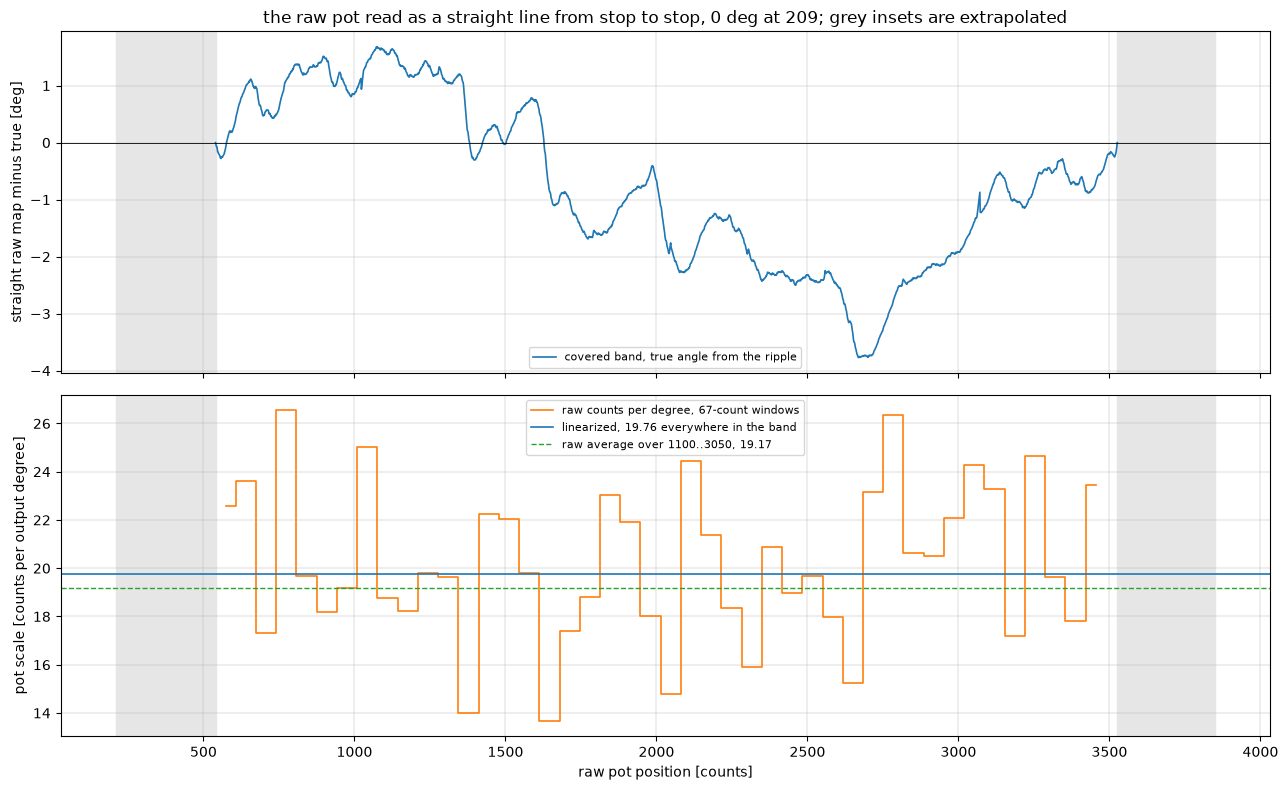

straight raw map minus true: -3.77 .. +1.68 deg over the covered band


,raw counts,degrees,bracket,how
stretch,,,,
covered band,540 .. 3526,151.12,150.44 .. 151.57,"ripple, counted cycles over the ratio"
low inset,209 .. 540,16.75,14.23 .. 18.99,extrapolated at the band's scale
high inset,3526 .. 3849,16.35,14.01 .. 18.63,extrapolated at the band's scale
stop to stop,209 .. 3849,184.22,178.67 .. 189.18,the sum
"stop to stop, insets at their neighbours' scale",209 .. 3849,181.99,,"a variant, not carried"


In [37]:
# Stop to stop. The covered band is measured, the two insets are not: nothing
# crosses them with the ripple tracked. osc cal extrapolates them at the band's
# average rate (ident/src/lut.rs stitched_motor_revs), which is also the only
# choice that keeps the linearized scale one number across the rails.
band_deg = (st1.cum[st1.lc] - st1.cum[st1.fc]) / CYC_PER_DEG
inset = np.array([LO - RAW_MIN, RAW_MAX - HI])          # raw counts below and above the covered band
TRAVEL = band_deg + inset.sum() / S_LIN                  # the carried value

# Bracket on the insets: the mean raw scale over any inset-wide stretch inside
# the band spans this much, so an inset could plausibly read anywhere in it.
def window_scales(w, step=5):
    e = np.arange(LO, HI - w + 1, step)
    return (w * CYC_PER_DEG) / (st1.angle(e + w) - st1.angle(e))
lo_rng, hi_rng = window_scales(inset[0]), window_scales(inset[1])
ins_lo = inset[0] / lo_rng.max() + inset[1] / hi_rng.max()        # both insets read fast: fewest degrees
ins_hi = inset[0] / lo_rng.min() + inset[1] / hi_rng.min()        # both read slow: most degrees
# and the scale of the band's own first and last inset-wide stretch, carried outward
ins_nb = inset[0] / lo_rng[0] + inset[1] / hi_rng[-1]
# the band itself, from the per-capture spread of its scale
band_lo, band_hi = band_deg * S_LIN / max(per_cap), band_deg * S_LIN / min(per_cap)
TRAVEL_LO, TRAVEL_HI = band_lo + ins_lo, band_hi + ins_hi

rr = np.arange(RAW_MIN, RAW_MAX + 1)
deg_true = np.full(rr.shape, np.nan)
m_in = (rr >= LO) & (rr <= HI)
deg_true[m_in] = inset[0] / S_LIN + (st1.angle(rr[m_in]) - st1.angle(LO)) / CYC_PER_DEG
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax = axes[0]
err_deg = (rr - RAW_MIN) / S_LIN - deg_true                        # raw read as a straight line, minus true
ax.plot(rr, err_deg, color="tab:blue", lw=1.2, label="covered band, true angle from the ripple")
for a, b in ((RAW_MIN, LO), (HI, RAW_MAX)):
    ax.axvspan(a, b, color="0.9")
ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("straight raw map minus true [deg]")
ax.set_title(f"the raw pot read as a straight line from stop to stop, 0 deg at {RAW_MIN}; grey insets are extrapolated")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
ax = axes[1]
c67, s67 = sensitivity(x, lin, 67)
ax.step(c67, S_LIN * s67, where="mid", color="tab:orange", lw=1.2, label="raw counts per degree, 67-count windows")
ax.axhline(S_LIN, color="tab:blue", lw=1.2, label=f"linearized, {S_LIN:.2f} everywhere in the band")
ax.axhline(counts_per_deg(st1, A, B), color="tab:green", lw=1, ls="--", label=f"raw average over {A}..{B}, {counts_per_deg(st1, A, B):.2f}")
for a, b in ((RAW_MIN, LO), (HI, RAW_MAX)):
    ax.axvspan(a, b, color="0.9")
ax.set_xlabel("raw pot position [counts]")
ax.set_ylabel("pot scale [counts per output degree]")
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)
plt.tight_layout()
plt.show()

print(f"straight raw map minus true: {np.nanmin(err_deg):+.2f} .. {np.nanmax(err_deg):+.2f} deg over the covered band")
pd.DataFrame([
    ("covered band", f"{LO} .. {HI}", f"{band_deg:.2f}", f"{band_lo:.2f} .. {band_hi:.2f}", "ripple, counted cycles over the ratio"),
    ("low inset", f"{RAW_MIN} .. {LO}", f"{inset[0] / S_LIN:.2f}", f"{inset[0] / lo_rng.max():.2f} .. {inset[0] / lo_rng.min():.2f}",
     "extrapolated at the band's scale"),
    ("high inset", f"{HI} .. {RAW_MAX}", f"{inset[1] / S_LIN:.2f}", f"{inset[1] / hi_rng.max():.2f} .. {inset[1] / hi_rng.min():.2f}",
     "extrapolated at the band's scale"),
    ("stop to stop", f"{RAW_MIN} .. {RAW_MAX}", f"{TRAVEL:.2f}", f"{TRAVEL_LO:.2f} .. {TRAVEL_HI:.2f}", "the sum"),
    ("stop to stop, insets at their neighbours' scale", f"{RAW_MIN} .. {RAW_MAX}", f"{band_deg + ins_nb:.2f}", "",
     "a variant, not carried"),
], columns=["stretch", "raw counts", "degrees", "bracket", "how"]).set_index("stretch")

**What you are looking at.** Top, what reading the raw pot as a straight line from stop to stop
gets wrong, in degrees, across the covered band. The grey insets are extrapolated, so there is
nothing to draw there. Bottom, the raw pot's local scale in 67-count windows (orange) against the
linearized scale (blue) and the raw average over mid travel (green, dashed).

The stop-to-stop travel is **184.2 degrees**, bracket 178.7 to 189.2. Of that, 151.1 degrees is the
covered band, good to about 0.6 degrees. The rest of the bracket sits in the two ends, where 331 and
323 counts could each be anywhere from about 14 to 19 degrees.

The last row is a variant. It carries the scale of the band's outermost stretch instead of the
average, and both of those stretches read fast (about 21.5 and 20.9 counts per degree), so the
travel comes out 182.0. That sits inside the bracket, but I do not carry it. The firmware's map is
one straight line through the linearized counts, so with 182.0 every angle inside the band would be
1.2% short, a scale error inside every move. With 184.2 the angles inside the band are right
relative to each other, and what the ends leave open is an offset of a degree or two against the
physical stops.

The top panel is the pot's error from section 1, now in degrees. Read as a straight line from stop
to stop, the raw pot is off by up to 3.8 degrees in the middle of travel and 1.7 the other way near
1100, and its local slope is off by up to a third.

What goes into the servo. The control table's kinematics block (`calib.kinematics`) holds three
numbers for the host. `angle_min_cdeg` is the angle at `raw_min` and `angle_max_cdeg` the angle at
`raw_max`, both in hundredths of a degree, and `gear_ratio_centi` is motor revolutions per output
revolution times 100. The firmware never reads them. The ISR stays in counts.

In [38]:
# What the servo's control table gets from this, in the units osc cal writes.
GEAR_RATIO_CENTI = int(round(RATIO.value * 100))       # motor revs per output rev x 100
ANGLE_MAX_CDEG = int(round(TRAVEL * 100))              # angle at raw_max with angle_min 0 at raw_min
print(f"gear_ratio_centi = {GEAR_RATIO_CENTI}   (exact {RATIO.value * 100:.2f})")
print(f"angle_min_cdeg   = 0      at raw {RAW_MIN}")
print(f"angle_max_cdeg   = {ANGLE_MAX_CDEG}   at raw {RAW_MAX}, bracket {TRAVEL_LO * 100:.0f} .. {TRAVEL_HI * 100:.0f}")
print(f"degrees per count through the phys span: {TRAVEL / (RAW_MAX - RAW_MIN):.5f} (the linearized scale {1 / S_LIN:.5f})")

gear_ratio_centi = 30805   (exact 30805.33)
angle_min_cdeg   = 0      at raw 209
angle_max_cdeg   = 18422   at raw 3849, bracket 17867 .. 18918
degrees per count through the phys span: 0.05061 (the linearized scale 0.05061)


`gear_ratio_centi` is **30805**. It is exact to the rounding, as long as I counted the teeth right.
The travel is a rough check on that. 184 degrees is what a servo sold as 180 degrees should do, and
the pot's full 4096 counts come to 207 degrees here against 212 on the SG90 (notebook 06), the same
class of pot. That check would catch a wrong stage or a badly misread wheel. It would not catch one
tooth off on a big wheel, which moves everything by 2 to 3%.

`angle_max_cdeg` is **18422**, with `angle_min_cdeg` 0. The middle 151 degrees of it are good to
about half a percent. The ends make it 17867 to 18918, and only a measurement at the stops can
tighten that (open item 10). When `osc cal` runs with `--gear-ratio 308.05` it extrapolates the ends
the same way from its own sweep, so it should land close to this. A gap of more than a couple of
degrees would mean its sweep covered a different stretch of the pot, which is worth knowing too.

One more thing the ratio settles. The bringup plant fit puts the MG90's back-EMF constant at about
1.41 times the SG90's, in `ke_vpc`, terminal counts per pot count per second. With both gear ratios
counted, the ratio between the two servos in degrees should split into the gears, 308.05 over 234.73
= 1.312, times whatever the two motors differ by. But a $K_e$ per pot count is not a $K_e$ per
degree. The two pots have different scales, and the MG90 fit was made in raw counts. So the cell
below does it in output degrees, two ways.

- **(a) The ripple route.** Motor $K_e$ from section 3, in mV per ripple Hz, times six. The pot never
  enters, and it is the same kind of number as the SG90's $K_e$ from notebook 03 (mV per motor
  revolution per second).
- **(b) The pot route.** Section 9's `ke_vpc` in linearized counts, times the linearized scale, over
  the plant fit's usual 20 to 60% band and again over 20 to 50% only.

Output $K_e$ is then motor $K_e$ times $N$, per output revolution per second, divided by 360 to put
it per degree per second.

In [39]:
# The SG90 against the MG90, output-shaft Ke split into gears and motor.
sg = oscnb.servos.SERVOS["sg90-a"]
R_SG, KE_SG = sg.measured["gear_ratio_measured"], sg.measured["ke_measured"]   # counted; mV per motor rev/s
V_TERM_MV = board.v_term_per_count * 1e3                                         # mV per terminal count

# (a) the ripple route. Motor Ke from section 3 in mV per ripple Hz, times the six
# cycles per rev. The pot never enters on either servo.
ke_a = {s: KE[s][0] * 1e3 * PULSES.value for s in (1, -1)}                       # mV per motor rev/s
ke_mg_a = np.mean(list(ke_a.values()))
# (b) the pot route. Section 9's ke_vpc, back-EMF per linearized count per second,
# over the plant fit's 20-60% band and over 20-50% only, times the linearized scale.
ke_vpc_b = {"20-60%": lin_p["ke_vpc [tap counts per count/s]"], "20-50%": lin_p50["ke_vpc [tap counts per count/s]"]}
sg_out = KE_SG.value * R_SG.value / 360.0                                        # SG90 output Ke, mV per deg/s
# the SG90's ke_vpc from the same registry entries (nb06 route: counts per motor rev
# from its pot scale and ratio), so the counts-only comparison needs no typed number
sg_vpc = KE_SG.value / V_TERM_MV / (sg.measured["pot_scale_measured"].value * 360.0 / R_SG.value)
rows = [{"route": "SG90, nb03 route R (coast back-EMF on ripple speed)", "motor Ke [mV per rev/s]": KE_SG.value,
         "output Ke [mV per deg/s]": sg_out}]
rows.append({"route": "MG90 (a), ripple, 15-50% drive windows, R pinned", "motor Ke [mV per rev/s]": ke_mg_a,
             "output Ke [mV per deg/s]": ke_mg_a * RATIO.value / 360.0})
for band_, k in ke_vpc_b.items():
    out = k * V_TERM_MV * S_LIN
    rows.append({"route": f"MG90 (b), pot, plant fit {band_}, linearized", "motor Ke [mV per rev/s]": out * 360.0 / RATIO.value,
                 "output Ke [mV per deg/s]": out})
ks = pd.DataFrame(rows).set_index("route")
ks["output Ke over SG90"] = ks["output Ke [mV per deg/s]"] / sg_out
ks["gears over SG90"] = [1.0] + [RATIO.value / R_SG.value] * (len(ks) - 1)   # the SG90 row is the reference
ks["motor Ke over SG90"] = ks["output Ke over SG90"] / ks["gears over SG90"]
# motor Ke ratio bracket on route (a): the MG90's two directions against the SG90's bracket
m_lo, m_hi = min(ke_a.values()) / KE_SG.hi, max(ke_a.values()) / KE_SG.lo
print(f"ke_vpc alone, counts not degrees: MG90 raw plant fit {raw_p['ke_vpc [tap counts per count/s]']:.4f} over "
      f"SG90 {sg_vpc:.4f} = {raw_p['ke_vpc [tap counts per count/s]'] / sg_vpc:.3f}")
print(f"MG90 route (a) per direction: fwd {ke_a[1]:.3f}, rev {ke_a[-1]:.3f} mV per rev/s; "
      f"SG90 {KE_SG.value:g} [{KE_SG.lo:g}, {KE_SG.hi:g}]")
print(f"motor Ke over SG90, route (a) bracket: {m_lo:.3f} .. {m_hi:.3f}")
ks.round(3)

ke_vpc alone, counts not degrees: MG90 raw plant fit 0.1472 over SG90 0.1039 = 1.416
MG90 route (a) per direction: fwd 7.833, rev 7.704 mV per rev/s; SG90 7.584 [7.44, 7.73]
motor Ke over SG90, route (a) bracket: 0.997 .. 1.053


,motor Ke [mV per rev/s],output Ke [mV per deg/s],output Ke over SG90,gears over SG90,motor Ke over SG90
route,,,,,
"SG90, nb03 route R (coast back-EMF on ripple speed)",7.584,4.945,1.000,1.000,1.000
"MG90 (a), ripple, 15-50% drive windows, R pinned",7.769,6.648,1.344,1.312,1.024
"MG90 (b), pot, plant fit 20-60%, linearized",8.053,6.891,1.394,1.312,1.062
"MG90 (b), pot, plant fit 20-50%, linearized",7.871,6.735,1.362,1.312,1.038


**What you are looking at.** One row per route, the motor $K_e$ it implies, the output $K_e$ per
degree per second, and the output ratio over the SG90 split into gears and motor.

The 1.41 does not survive the trip into degrees. Three things were folded into it, and they pull
different ways. The MG90's pot has more counts per degree than the SG90's (19.76 against 19.30),
which on its own pushes the ratio up about 2%. The MG90 fit was in raw counts over settled windows
where this pot reads slow, and section 9 showed that makes it 3.9% high. And the plant fit runs to
60% duty, where this motor's back-EMF already reads 5 to 6% fast (section 8), which adds about 2%
more. With all three taken out, the output ratio is 1.362 by the pot route and 1.344 by the ripple
route.

So the gears account for 1.312 of it, exactly, and the motors for the rest, 1.024 by the ripple
route (bracket about 1.00 to 1.05 from the two directions and the SG90's own bracket) and 1.038 by
the pot route. I carry **a motor $K_e$ ratio of about 1.03, bracket 1.00 to 1.06**. The two motors
are nearly the same, the MG90's maybe a few percent stronger per revolution. Most of the MG90's
extra back-EMF per output degree is its gearing.

There is one catch in comparing the rows. The SG90's $K_e$ is a coast measurement (notebook 03,
route R) and the MG90's route (a) is a drive-window fit with $R$ pinned and a free intercept. Same
quantity, different methods. That is open item 9, and the data to close it is already recorded.

## 11. After the firmware applies the table

This section is a placeholder until the firmware work lands. The confirmation capture is the same 2S
merged session, five captures, with the table written and saved and TEL still streaming raw `pos`.
The firmware's linearized position streams as TEL `pos_lin` once that band lands, a Q4 word beside
raw `pos`. Until then it is reconstructed offline from raw `pos` and the stored table, which is what
this notebook does now.

What to compare, with the pass line for each.

- The table read back from the servo against the JSON here, knot for knot.
- The linearized position the firmware reports against `potlut.GridLut.q4` on the same raw samples.
  It is the same integer expression, so the match is exact on every sample, not within a count.
- Held-out position error on the new captures against section 7 (2.9 counts rms on the grid, 4.7
  with 55 knots).
- Pot speed error at 4 and 20 ms against section 7 (12.6% and 3.6% on the grid).
- The plant refit through the firmware's own counts against section 9's linearized column.
- A position-hold and step check across travel. The step response should not change with position
  the way it does today (loop gain 0.71 to 1.35 times nominal across travel in raw counts).

## Caveats

- **One servo, one board.** Everything here describes mg90-a on the bodged board D. The table is a
  property of this one pot and has to be measured per servo.
- **About 200 counts next to each guard rest on route 1 alone.** Proof rule 1 is met from 735 to
  3292 (section 3). Only spin-up ever crosses 540 to 735 and 3292 to 3526.
- **At the lower end the proof needs the small-signal $R$.** At the pinned $R$ route 2 still
  disagrees over 735 to 1100 by up to 6.5 counts. The agreement with the small-signal $R$ comes with
  a wider stated uncertainty (2.9 counts median there), because that $R$ is only known to about 20%.
- **The servo seems to have changed during the day.** The ends capture differs from the session by
  up to 14 counts in mid travel (section 5). The table is a blend of both, and a table measured once
  carries that much uncertainty until the drift is understood.
- **The covered range is 540 to 3526, and the grid anchors on the 542 to 3520 at least 20 rungs
  cross.** Outside it both tables are identity by construction. That includes both soft limits, so
  any goal between a soft limit and the covered end is uncorrected.
- **R is pinned** from a different fit, with an open 7% gap between two routes to it, and the load
  swings along a rung want a much larger $R$ at low duty (section 3). It enters only route 2.
- **The back-EMF model is only fitted to 50% duty.** Its 5 to 28% over-read above that is taken as
  measured, not explained.
- **The ends capture ran on a tired pack**, 7.37 V against the session's 7.83 V, and its speed fell
  7 to 11% over its five captures. Only route 2 cares about either, and it gets one fit per capture.
- **The newer USB session finished recording while this notebook was being built.** The run
  committed here uses all five of its captures.
- **The ends of travel are extrapolated in degrees.** 331 counts at the bottom and 323 at the top are
  never crossed with the ripple tracked, so the stop-to-stop 184.2 degrees carries a bracket of 178.7
  to 189.2, almost all of it from those two stretches (section 10).
- **The gear ratio is only as good as the tooth count.** I counted it from photos. The travel is a
  plausibility check on it, not a measurement of it, and it would not catch one tooth off on a big
  wheel.

## Open discrepancies

**1. Route 2 over-reads at the ends of travel.** Up to 6% in density over the first few hundred counts
of every rung, where only spin-up covers the pot.
Settled for the table by the ends capture (section 3). At speed, route 2 agrees at the upper end, and at
the lower end once it uses the small-signal $R$. What was left at the lower end was route 2 reading fast
at a load spot, not a pot error. Two things stay open. The physics is item 8. And the last 200 or so
counts next to each guard are still only crossed while spinning up, because each rung arriving from the
other side stopped short of the guard, and the later captures stopped shorter as the speed fell (item 7).
What would close that: windows long enough for the arriving rung to run all the way into the far guard
at speed, sized from the slowest capture, not the first.

**2. Forward and reverse differ by a position-locked bump near raw 2500.** Up to 11 counts, both routes,
independent of drive current.
Candidates: (a) the wiper contacts the track differently each way over a patch of texture, (b) tooth
transmission error that differs between the two flanks of one mesh.
What separates them: (a) is fixed to the pot track and (b) to the gear phase. Remove the output gear
from the pot's D-key, rotate it by a known number of teeth and refit it, then recapture. A pot feature
stays at the same raw count and a gear feature moves by the rotation. Without taking it apart, a test
at a slower duty with a mass on the horn reverses the load on the output and would move (b) but not (a).

**3. The classic 2S grid disagrees with the session by 3.3 counts rms.** Both are this servo, a day apart.
Item 6 makes (a) more likely, since the servo seems to change within a single day too.
Candidates: (a) the pot or the train changed overnight (the rig was reassembled), (b) the older firmware
and capture timing, (c) scatter I have not captured enough of.
What separates them: a new classic-style grid captured today, right after a session. If it matches the
session, (a) and (c) are out.

**4. The USB tables sit up to 8 to 15 counts off the 2S table in a broad hump through the middle.**
Candidates: (a) a real supply effect on the pot reading, for example the pot's 3V3 reference or the
ground moving with the motor current, which is drawn from a softer rail on USB, (b) a small density
difference near the rung starts where the lower USB current spins up differently, spread by the
anchoring, (c) the servo changing between the two sessions, which were recorded hours apart.
What separates them: (a) predicts the offset scales with motor current, so a USB grid at matched
current to a 2S grid (lower duty on 2S) should close it. (b) disappears in the at-speed end capture of
item 1. (c) needs a 2S session recorded straight after a USB one.
Section 5 now leans toward (c). The 2S ends capture, recorded after the USB session, differs from the
2S session in the same pattern (correlation 0.95) and by more, and it is on 2S, so a supply effect
cannot make it. The test is now item 6.

**5. The ADC's wide codes at 1023 and 3072.** Measured, not a discrepancy. They are dead bands of about 5
and 8 codes that no table can split. Whether a different ADC clock or sample time narrows them is a
converter question for the firmware.

**6. The ends capture differs from the session by up to 14 counts in mid travel.** Both are 2S, a few hours
apart, and each repeats within itself to about a count. The USB session recorded in between sits partway,
in the same pattern.
Candidates: (a) the pot track or the train changing with hours of running (wear, debris, grease moving),
(b) something that depends on temperature, (c) the tired pack of the ends capture (7.37 against 7.83 V).
What separates them: (c) predicts the shape follows the pack, so the same procedure on a fresh pack and
then on the tired one, back to back, rules it in or out, and (a) and (b) do not care. Then a run from cold
after hours of rest against the same run warm separates (a) from (b), since wear does not come back and
temperature does.

**7. Within the ends capture the speed at fixed duty falls 7 to 11% over five captures, and route 2's
intercept $V_0$ climbs by about 100 mV.** The drive and the rest offset do not move and the current drops
slightly, so something eats a voltage that does not depend on speed. The session shows no such trend (its
speeds hold within 4% over five captures).
Candidates: (a) brush and commutator contact drop rising as the motor runs (film, wear, heat), (b) the
winding warming, which would need R up by 30%, about 80 degrees C of copper from some 20 mW, so unlikely,
(c) the average drive falling short of $D$ times the crest reading (switching edges), which the crest
sample cannot see.
What separates them: at 100% the firmware holds the bridge on with no switching edges at all, so 100% rungs at the start and the
end of a long run keep (a) and (b) and drop (c). A locked-rotor reading at a fixed small current before and
after a run then separates (a), an offset, from (b), a slope.

**8. The back-EMF equation wants a larger $R$ for small load swings than the pinned one.** About 7.7 ohm at 15
to 20% duty, falling to 4 to 5.6 at 45 to 50%, against 4.89 from the onset regression, good to about 20%
because of the regression direction. It explains the lower-end disagreement, section 3's residual of about
a count, and part of the spin-up over-read (11% to 8% at the bottom end, 6% to 3% at the top). It matters for
notebook 08 too, whose observer subtracts $R\,i$ in exactly this way.
Candidates: (a) a brush contact drop that is not a plain resistor, steep at low current and flatter at high
current, which is what an $R$ falling with duty looks like, (b) the current chain reading small, slow current
changes low. For the rest of the spin-up over-read, the old (b) and (c) of item 1 stand, the inductive term
and the crest current during fast changes.
What separates them: a locked-rotor ladder at 15 to 60% with a load fixture, in small duty steps, measures
the voltage per current at zero speed with no back-EMF at all. About 7.7 ohm at low current points to the
motor, (a). About 4.9 points to how the current reads in motion, (b).

**9. The motor $K_e$ comparison mixes methods.** The SG90's 7.584 mV per rev/s is coast back-EMF on ripple
speed (notebook 03, route R). The MG90's 7.77 is a drive-window fit with $R$ pinned and a free intercept
(section 3), and the pot route on the same captures gives 1.4% more. The motor ratio is 1.024 or 1.038
depending on which I trust.
Candidates: (a) the two motors really differ by 2 to 4%, (b) the drive-window and coast methods differ by a
few percent on their own (a drive-window refit on the SG90 in the bringup bench notes read about 6% below its
coast number), (c) the pinned $R$, which item 8 says is wrong at low duty.
What separates them: notebook 03's route R run on the MG90's classic `stepcoast` captures, which are already
recorded in `mg90-a__dev-v006-D__2s`. Same method on both servos. If it lands near 7.77, (a) is the answer and
the split stands at about 1.02. If it lands higher, (b), and the difference is the method's own bias.

**10. The last 330 counts at each end have no angle.** Not a disagreement, a gap. The stop-to-stop travel
leans on extrapolating the band's scale across them (section 10), and that is where its whole 10-degree
bracket comes from.
What would close it: a protractor or dial read of the horn at both hand stops against a mid-travel mark
gives the stop-to-stop angle directly, to about a degree, with no drive at all. The other way is ripple-tracked
rungs that run from the guard on into the stop at low duty. Those reach the insets, but they load the plastic
end stopper, so only in a run where I am at the bench.

## Where this goes next

Both tables are in the bringup repo as JSON, the 55 knots and the grid, and the port that built them is
`oscnb.potlut`. The firmware side is planned around the grid. Apply it once per pot sample at the sensor
boundary with a shift and one multiply, validate it on commit, all-zero means identity so a servo without
a table is unchanged, and TEL keeps raw `pos` beside the linearized one. Three findings here feed that
plan.

- Anchor the table on a coverage threshold, not on the extreme samples, as this notebook does. Otherwise
  one stray rung moves every knot.
- 55 knots are enough for position. For the pot to be a useful speed source below the back-EMF floor
  the grid's 16-count spacing is what helps, 12.6% at 4 ms against 19%, and its 257 knots are 514 bytes.
- The slip check gets three times more sensitive on linearized counts.

The kinematics block gets its numbers from section 10, `gear_ratio_centi` 30805 and `angle_max_cdeg`
18422 with `angle_min_cdeg` 0.

Two findings here feed other work. Notebook 08's observer subtracts $R\,i$ with the pinned $R$, and the
load swings here want about 7.7 ohm at low duty (open item 8), which is worth checking against the
observer's own error at load spots. And the pot shape moved by up to 14 counts within one day (open item 6),
which decides whether `osc` measures the table once or has to refresh it.

Section 11 is waiting for the capture that confirms it all on the servo.